# AIGC 图像的频谱指纹挖掘与伪造检测

本 Notebook 是 Blackboard 提交用的代码实现与结果展示文件。它不重新运行 full-scale 训练，而是读取仓库中已经生成的 CSV、PNG 和模型输出摘要，复现报告中的核心实验结果。展示内容包括数据统计、clean 主结果、单一频域与融合频域对比、跨生成器泛化、鲁棒性诊断、置信度/拒识分析、错误模式分析和复现实验命令。


[SUBMISSION_CONTEXT]

## 0. 原始数据下载链接与环境依赖

本项目使用 GenImage 数据集中的四个生成源子集：ADM、BigGAN、VQDM 和 GLIDE。原始数据不随提交文件打包，需要从官方数据源下载并整理为 `PATH_TO_GenImage_data/<generator>/train|val/ai|nature` 结构。

- GenImage 官方 GitHub 仓库：https://github.com/GenImage-Dataset/GenImage
- GenImage 官方主页：https://genimage-dataset.github.io/
- GenImage Google Drive 数据链接：https://drive.google.com/drive/folders/1jGt10bwTbhEZuGXLyvrCuxOI0cBqQ1FS?usp=sharing
- GenImage 百度网盘数据链接：https://pan.baidu.com/s/1i0OFqYN5i6oFAxeK6bIwRQ ，提取码：`ztf1`
- GenImage 论文：https://arxiv.org/abs/2306.08571

运行环境见 `requirements.txt`。如果在本地复现实验，可先设置：

```powershell
$env:GENIMAGE_DATA_ROOT = "PATH_TO_GenImage_data"
pip install -r requirements.txt
```

本 Notebook 前半部分保留了报告中的运行结果和可视化，末尾“完整源码附录”包含参与项目的所有核心代码文件。


In [1]:
from pathlib import Path

cwd = Path.cwd()
candidates = [
    cwd / "requirements.txt",
    cwd.parent / "requirements.txt",
    cwd.parent.parent / "requirements.txt",
]
req_path = next((path for path in candidates if path.exists()), None)
if req_path is None:
    raise FileNotFoundError("requirements.txt not found from the current notebook working directory")
print(req_path.read_text(encoding="utf-8"))


numpy
pandas
scipy
scikit-learn
lightgbm
pillow
tqdm
joblib
matplotlib
ipython
notebook



In [2]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'report').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLE_DIR = PROJECT_ROOT / 'report' / 'tables'
FIG_DIR = PROJECT_ROOT / 'report' / 'figures'

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)


def show_csv(name, n=10, columns=None):
    path = TABLE_DIR / name
    print(path.relative_to(PROJECT_ROOT) if path.is_absolute() else path)
    df = pd.read_csv(path)
    if columns:
        df = df[columns]
    display(df.head(n))
    return df


def show_fig(name, width=900):
    path = FIG_DIR / name
    print(path.relative_to(PROJECT_ROOT) if path.is_absolute() else path)
    display(Image(filename=str(path), width=width))

## 1. 数据集统计

本项目使用 GenImage 的四个生成源：ADM、BigGAN、VQDM 和 GLIDE。每个生成源包含 `train/ai`、`train/nature`、`val/ai` 和 `val/nature` 四个目录。二分类任务使用 AI 与 nature 两类图像；生成源归因任务只使用 AI 图像，并预测其来自哪个 generator。


In [3]:
dataset_counts = show_csv('dataset_counts.csv')

report\tables\dataset_counts.csv


,generator,train_ai,train_nature,val_ai,val_nature
0,ADM,162000,157453,6000,6000
1,BigGAN,162000,162000,6000,6000
2,glide,162000,162000,6000,6000
3,VQDM,162000,162000,6000,6000


## 2. 最终 clean 主结果

最终主模型目录为 `outputs_v2_full_best`，对应配置为 `fusion_freq + flat LightGBM + wide profile + full training`。该模型是报告中的 clean 主结果：二分类和生成源归因都使用同一套频域融合特征，并通过 LightGBM 完成可解释浅层建模。


In [4]:
v2 = show_csv('optimization_v2_summary.csv', n=12, columns=[
    'run', 'feature_profile', 'model_architecture', 'train_augmentation',
    'sample_fraction', 'binary_ai_vs_nature_macro_f1',
    'ai_subsource_attribution_macro_f1', 'combined_macro_f1', 'selected'
])

report\tables\optimization_v2_summary.csv


,run,feature_profile,model_architecture,train_augmentation,sample_fraction,binary_ai_vs_nature_macro_f1,ai_subsource_attribution_macro_f1,combined_macro_f1,selected
0,outputs_v2_full_best,fusion_freq,flat,none,1.000,0.991250,0.999083,0.995167,True
1,outputs_v2_5pct_fusion_freq_binary_expert_ense...,fusion_freq,binary_expert_ensemble,none,0.050,0.992500,0.997499,0.994999,False
2,outputs_v2_50pct_best,fusion_freq,flat,none,0.500,0.991125,0.998416,0.994771,False
3,outputs_v2_20pct_best,fusion_freq,flat,none,0.200,0.991042,0.997290,0.994166,False
4,outputs_v2_20pct_fusion_flat_seed123,fusion_freq,flat,none,0.200,0.989167,0.997081,0.993124,False
5,outputs_v2_5pct_fusion_freq_pairwise_ovo_attri...,fusion_freq,pairwise_ovo_attribution,none,0.050,0.987083,0.997499,0.992291,False
6,outputs_v2_5pct_fusion_freq_flat,fusion_freq,flat,none,0.050,0.987083,0.996665,0.991874,False
7,outputs_v2_5pct_color_freq_flat,color_freq,flat,none,0.050,0.983333,0.994161,0.988747,False
8,outputs_v2_smoke_fusion_freq,fusion_freq,flat,none,0.001,0.958333,1.000000,0.979167,False
9,outputs_v2_5pct_block_dct_flat,block_dct,flat,none,0.050,0.936246,0.976639,0.956443,False


report\figures\optimization_v2_macro_f1.png


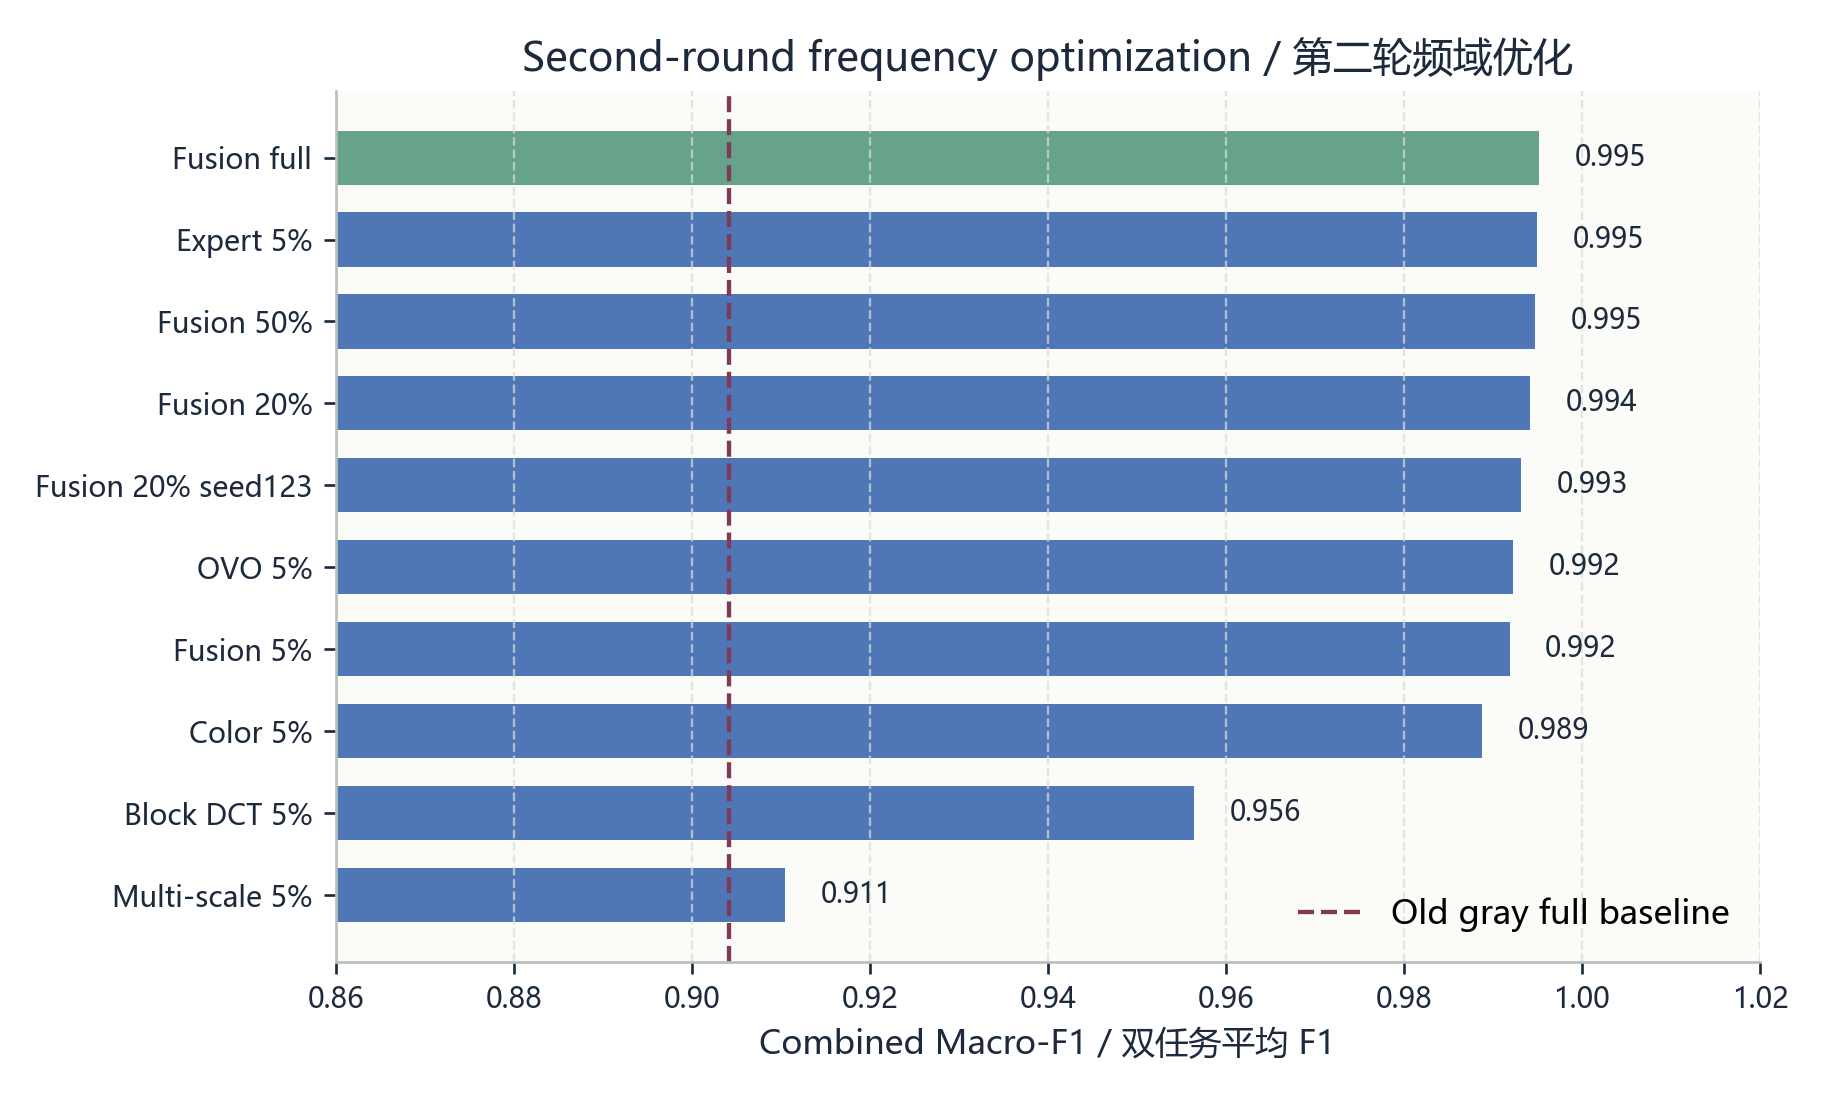

report\figures\scaleup_macro_f1.png


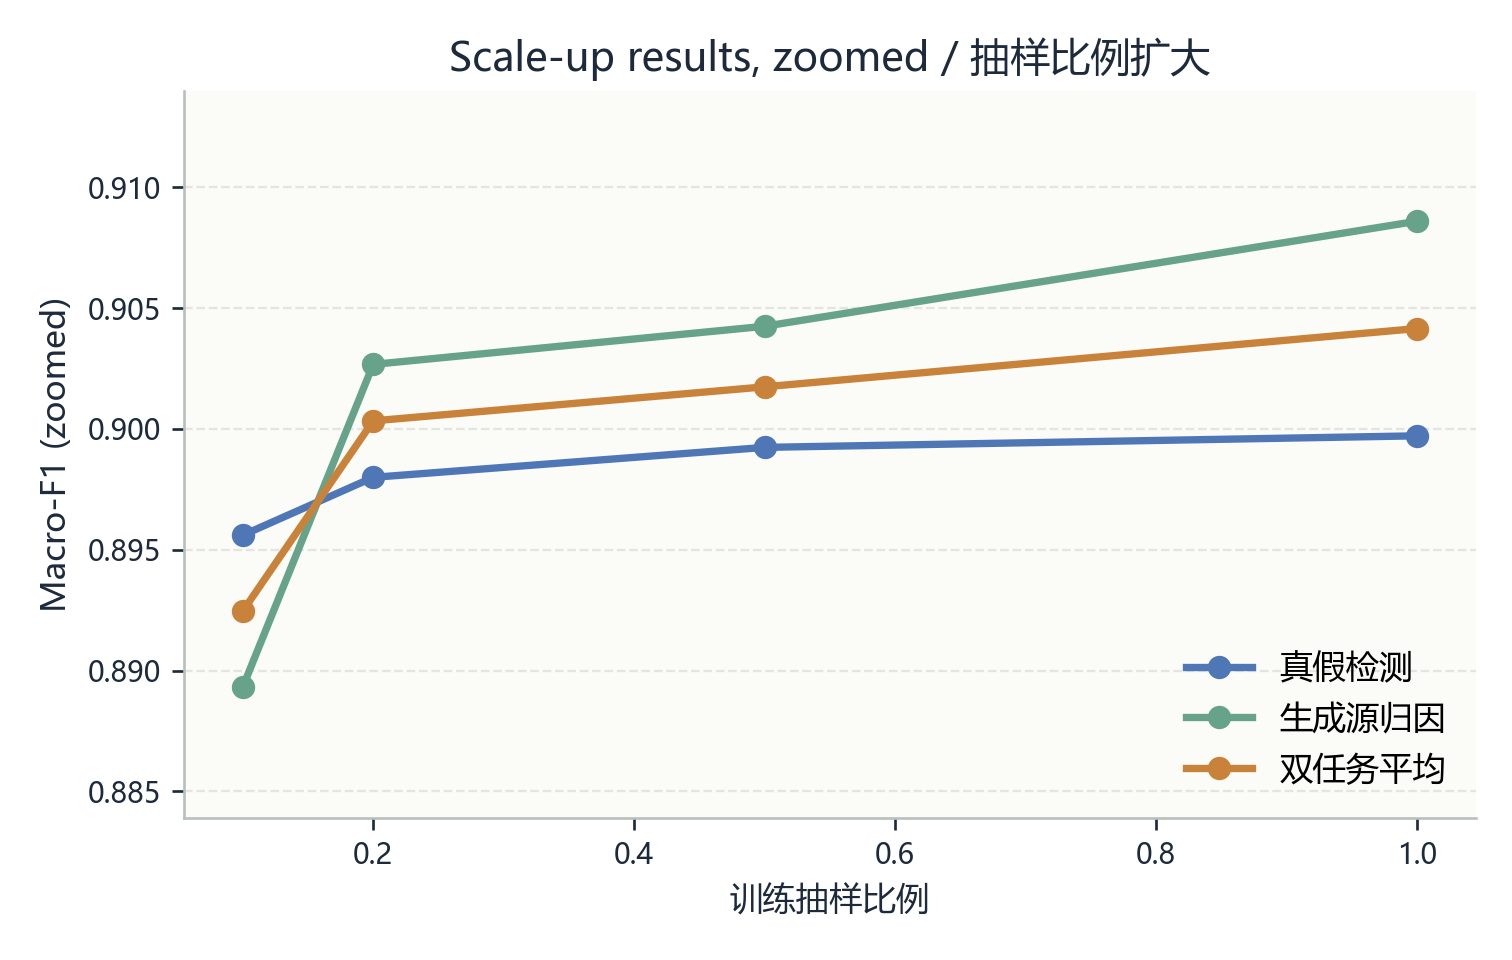

In [5]:
show_fig('optimization_v2_macro_f1.png')
show_fig('scaleup_macro_f1.png')

## 3. 单一频域特征与融合频域特征

这一部分比较不同频域 profile 的贡献，包括 color、multiscale、block-DCT、residual 等单一或局部增强特征，以及最终的 fusion profile。它用于回答：模型性能提升是否来自某一个单独频带，还是来自多类频域统计的互补融合。


report\tables\single_vs_fusion_profiles.csv


,profile,family,task,sample_fraction,macro_f1,accuracy,run
0,color_freq,single-domain,ai_subsource_attribution,0.05,0.994161,0.994167,outputs_v2_5pct_color_freq_flat
1,color_freq,single-domain,binary_ai_vs_nature,0.05,0.983333,0.983333,outputs_v2_5pct_color_freq_flat
2,multiscale_freq,single-domain,ai_subsource_attribution,0.05,0.900663,0.901667,outputs_v2_5pct_multiscale_freq_flat
3,multiscale_freq,single-domain,binary_ai_vs_nature,0.05,0.920403,0.920417,outputs_v2_5pct_multiscale_freq_flat
4,block_dct,single-domain,ai_subsource_attribution,0.05,0.976639,0.976667,outputs_v2_5pct_block_dct_flat
5,block_dct,single-domain,binary_ai_vs_nature,0.05,0.936246,0.936250,outputs_v2_5pct_block_dct_flat
6,residual_freq,single-domain,ai_subsource_attribution,0.05,0.895116,0.895833,outputs_v2_5pct_residual_freq_flat
7,residual_freq,single-domain,binary_ai_vs_nature,0.05,0.908750,0.908750,outputs_v2_5pct_residual_freq_flat
8,fusion_freq,fusion,ai_subsource_attribution,0.05,0.996665,0.996667,outputs_v2_5pct_fusion_freq_flat
9,fusion_freq,fusion,binary_ai_vs_nature,0.05,0.987083,0.987083,outputs_v2_5pct_fusion_freq_flat


report\figures\single_vs_fusion_feature_profiles.png


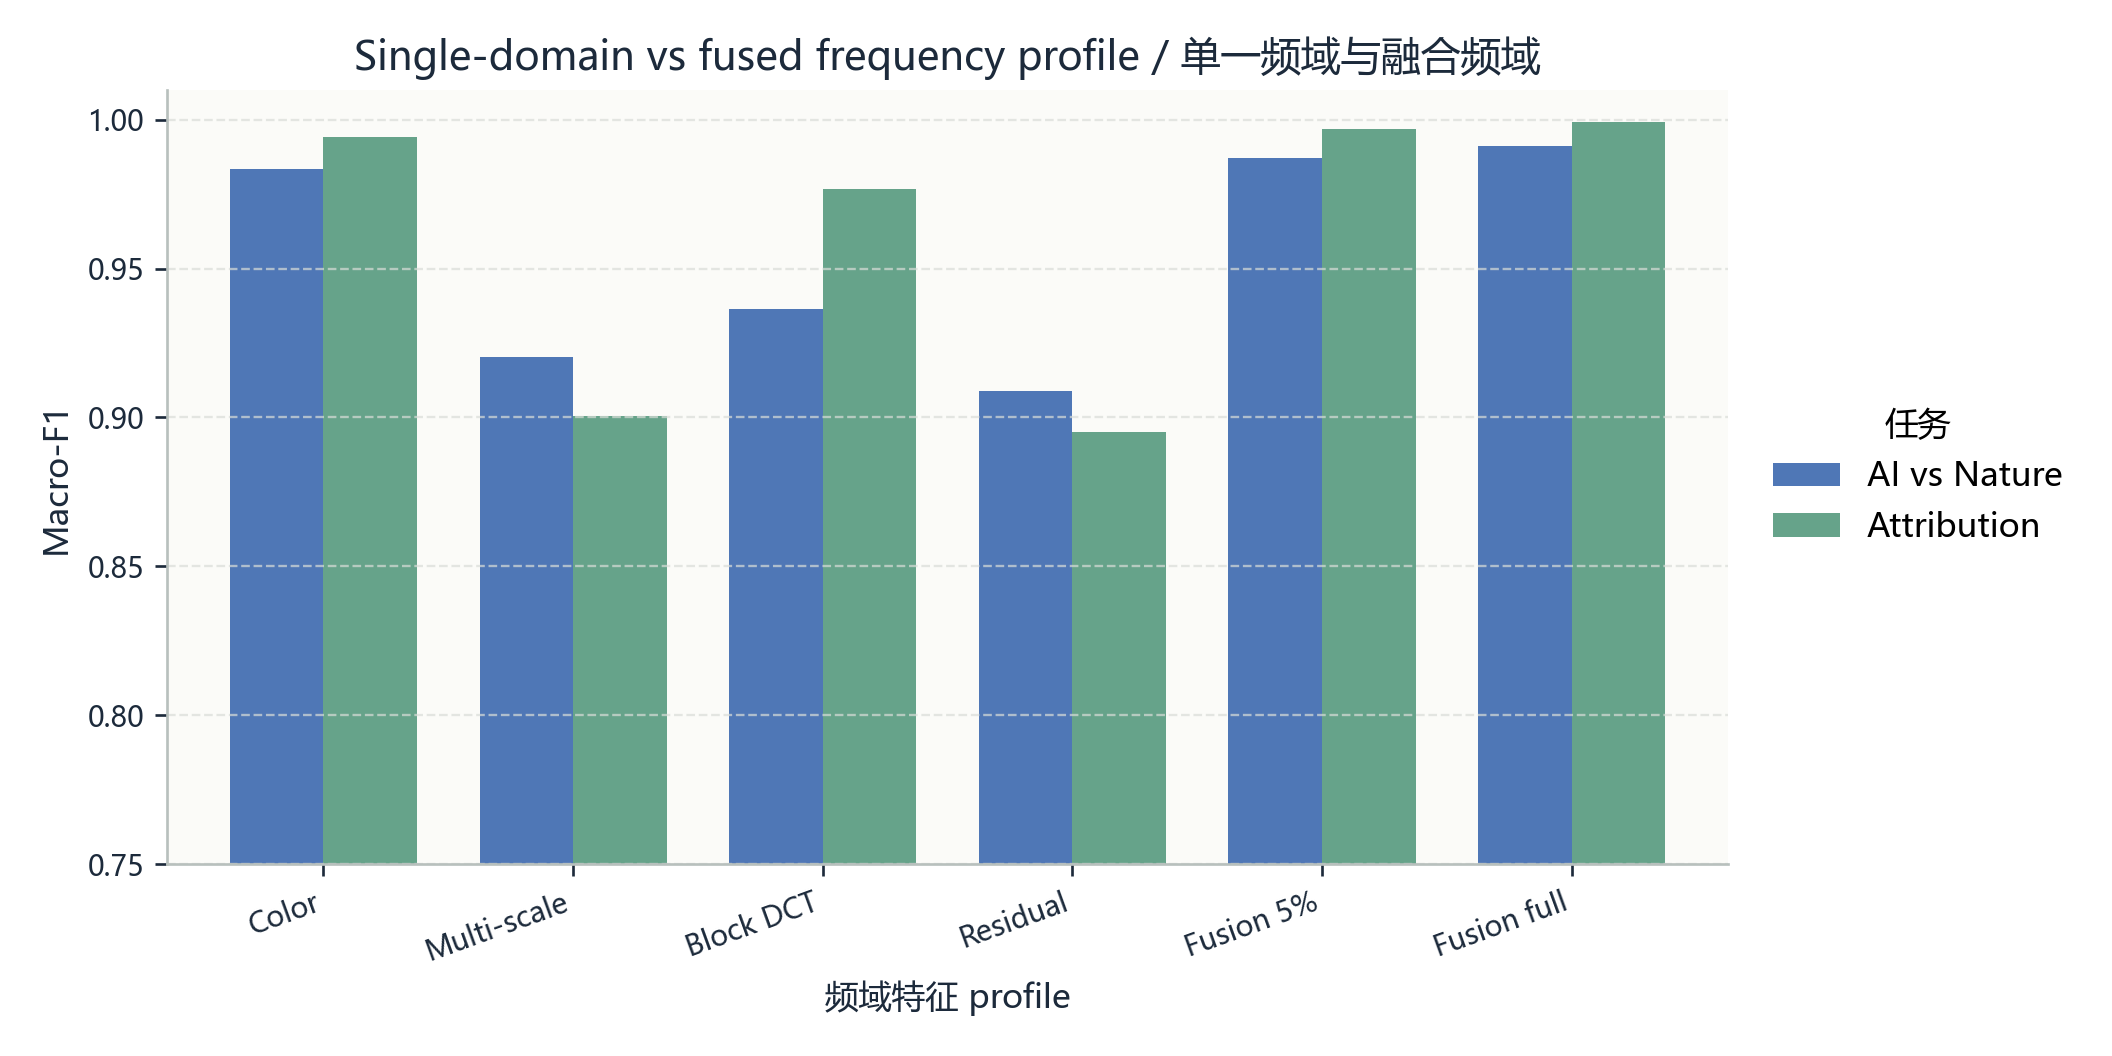

report\figures\feature_ablation_binary_ai_vs_nature.png


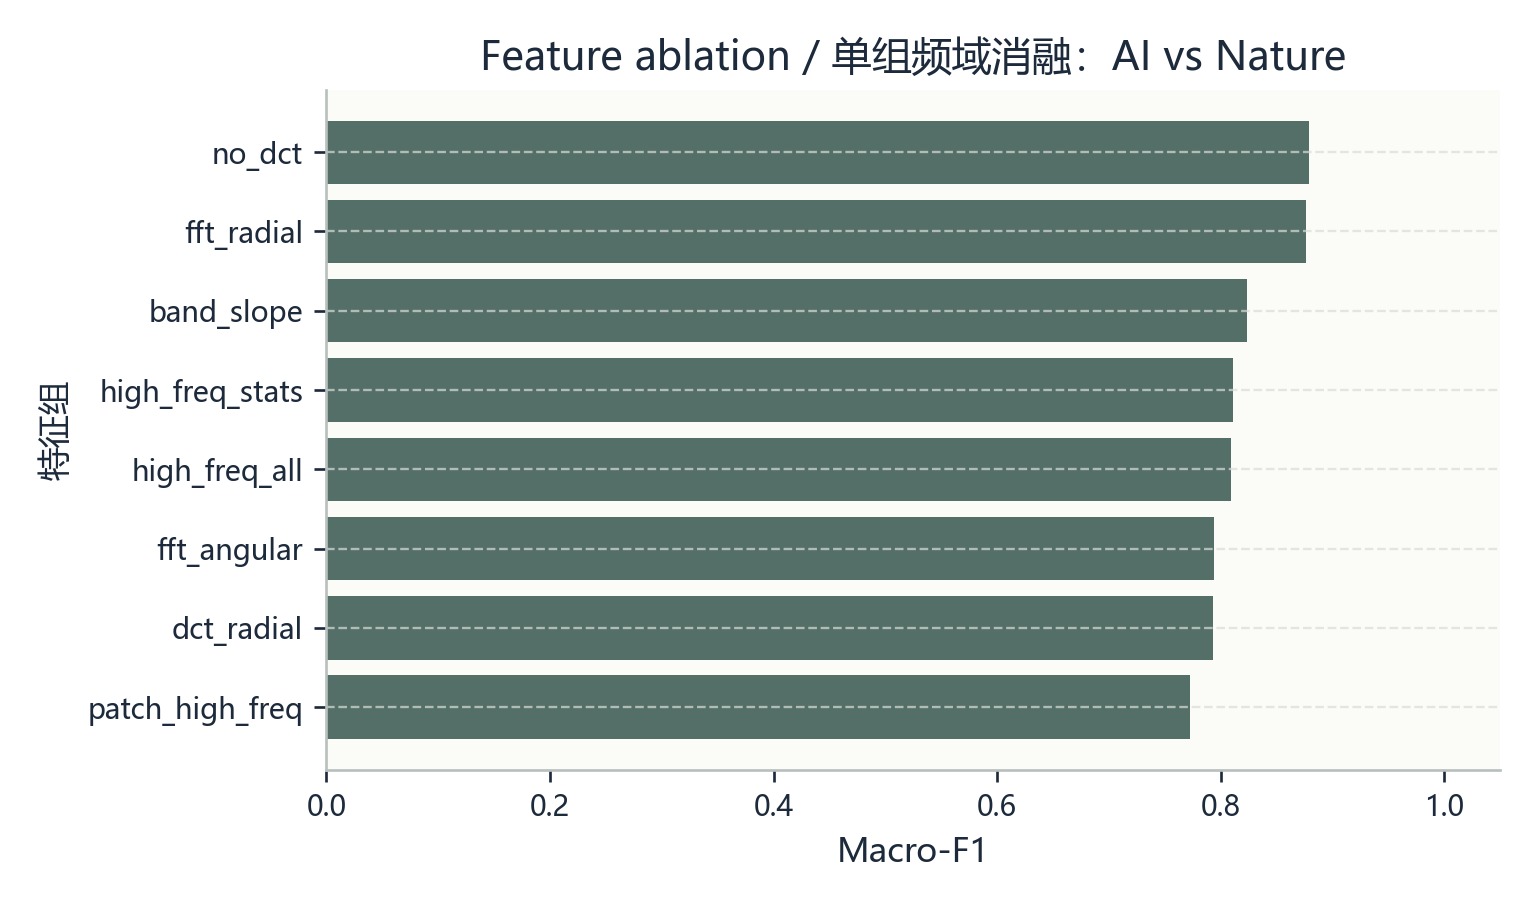

report\figures\feature_ablation_ai_subsource_attribution.png


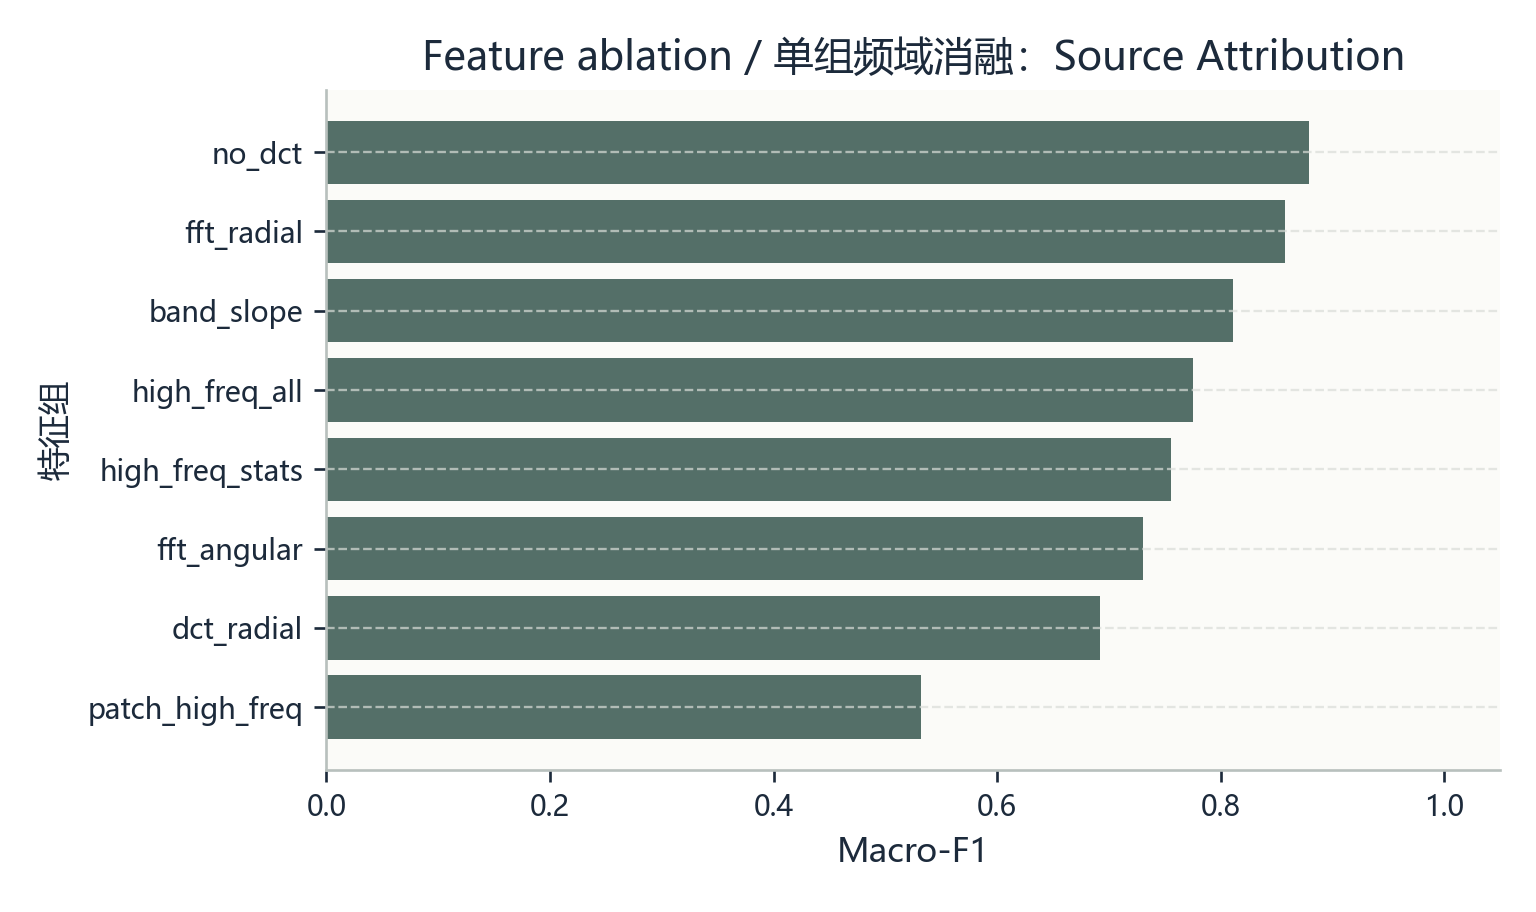

In [6]:
show_csv('single_vs_fusion_profiles.csv', n=20, columns=[
    'profile', 'family', 'task', 'sample_fraction', 'macro_f1', 'accuracy', 'run'
])
show_fig('single_vs_fusion_feature_profiles.png')
show_fig('feature_ablation_binary_ai_vs_nature.png')
show_fig('feature_ablation_ai_subsource_attribution.png')

## 4. 跨 generator 泛化实验

Leave-one-generator-out 实验每次留出一个 generator，只用另外三个 generator 训练二分类模型，再测试 held-out generator。该实验用于检查模型是否学到了较通用的 AIGC 频谱指纹，而不是只记住某几个已见生成器的局部特征。


report\tables\logo_generalization.csv


,heldout_generator,train_generators,sample_fraction,feature_profile,accuracy,macro_f1,auc
0,ADM,"BigGAN,VQDM,glide",0.200,fusion_freq,0.627500,0.569641,0.745563
1,BigGAN,"ADM,VQDM,glide",0.200,fusion_freq,0.730833,0.711982,0.928836
2,VQDM,"ADM,BigGAN,glide",0.200,fusion_freq,0.550417,0.438625,0.762068
3,glide,"ADM,BigGAN,VQDM",0.200,fusion_freq,0.888750,0.887691,0.964453
4,ADM,"BigGAN,VQDM,glide",0.001,stable_freq,0.750000,0.733333,0.888889


report\figures\logo_generalization_macro_f1.png


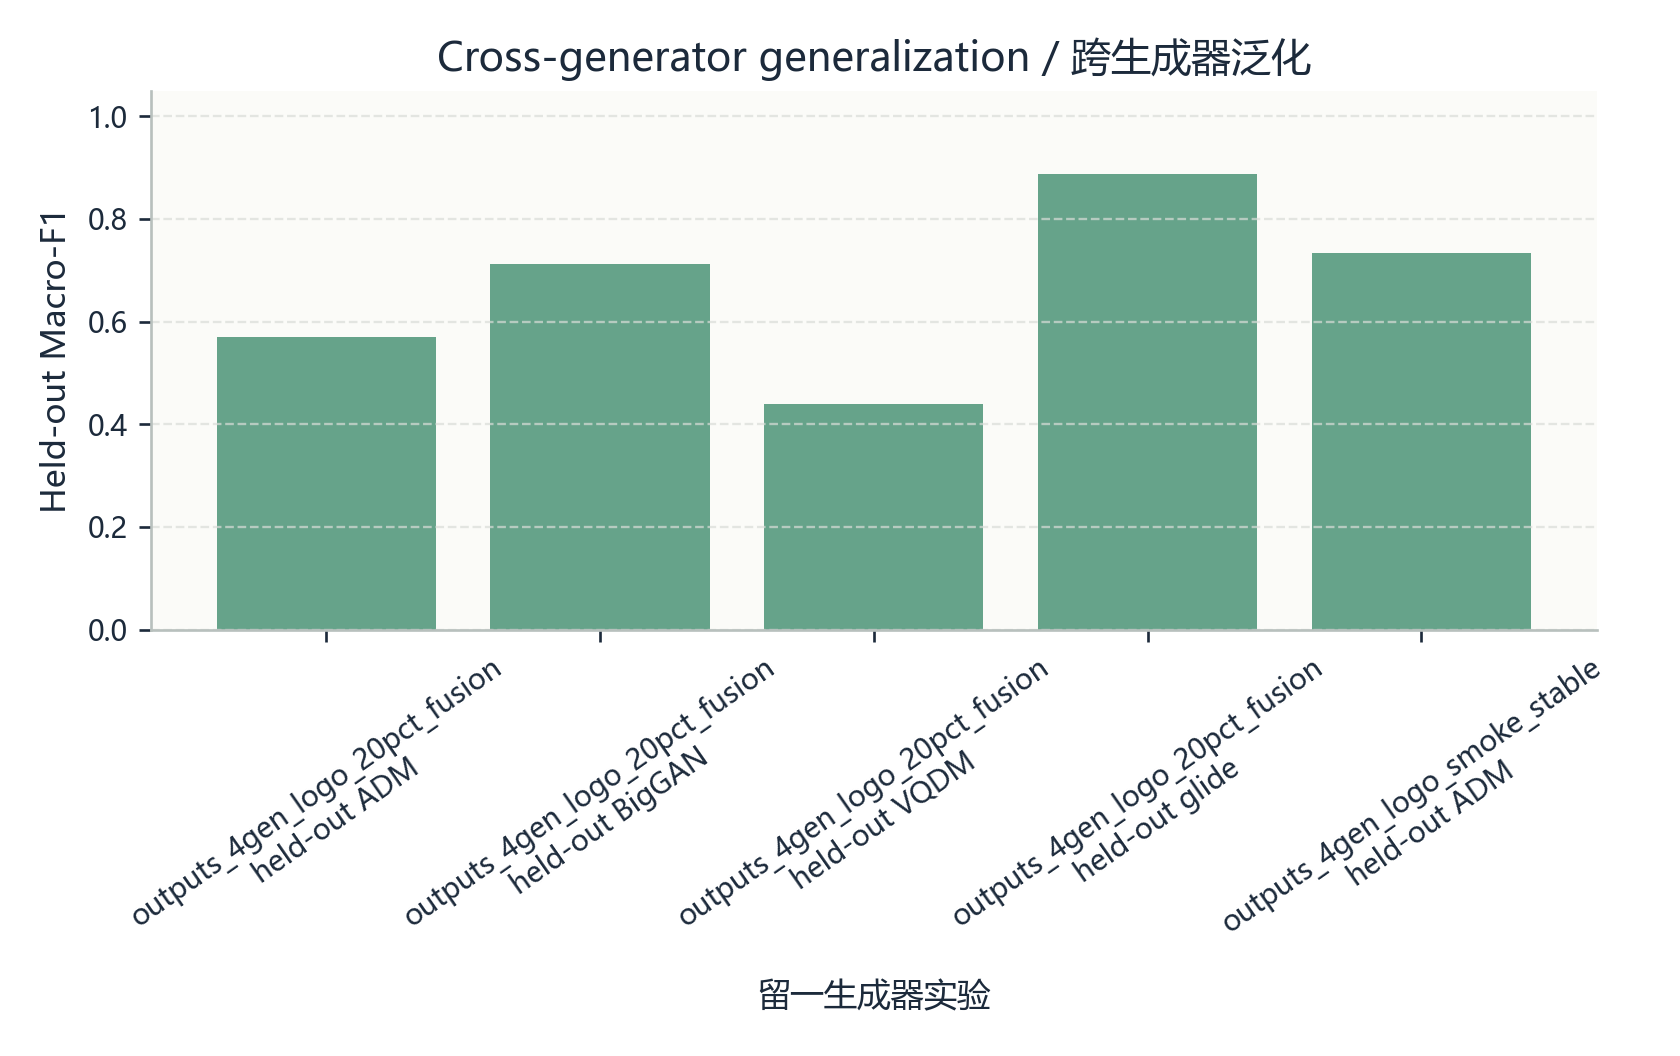

In [7]:
logo = show_csv('logo_generalization.csv', n=10, columns=[
    'heldout_generator', 'train_generators', 'sample_fraction',
    'feature_profile', 'accuracy', 'macro_f1', 'auc'
])
show_fig('logo_generalization_macro_f1.png')

## 5. 鲁棒性诊断

鲁棒性评估不重新训练模型，而是在同一 validation 子集上施加 JPEG 压缩、resize 和 Gaussian noise，再重新提取频域特征并评估模型输出。该部分展示 clean 高分模型在 degraded 图像上的性能退化，并与旧灰度 baseline 进行对照。


In [8]:
robust_cmp = show_csv('robustness_comparison.csv', n=25, columns=[
    'run', 'task', 'attack', 'level', 'n_samples', 'macro_f1', 'accuracy', 'auc'
])

report\tables\robustness_comparison.csv


,run,task,attack,level,n_samples,macro_f1,accuracy,auc
0,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,clean,none,9600,0.990833,0.990833,0.999628
1,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,jpeg,95,9600,0.660730,0.683646,0.787743
2,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,jpeg,75,9600,0.579960,0.612500,0.665828
3,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,jpeg,50,9600,0.566565,0.598750,0.633951
4,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,resize,0.5,9600,0.367118,0.511042,0.412542
5,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,resize,0.75,9600,0.637942,0.674583,0.792209
6,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,resize,1.5,9600,0.813555,0.818542,0.919892
7,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,noise,2,9600,0.748085,0.760312,0.815550
8,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,noise,5,9600,0.433913,0.529896,0.563054
9,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,noise,10,9600,0.337735,0.447708,0.420701


report\figures\robustness_comparison_binary_ai_vs_nature.png


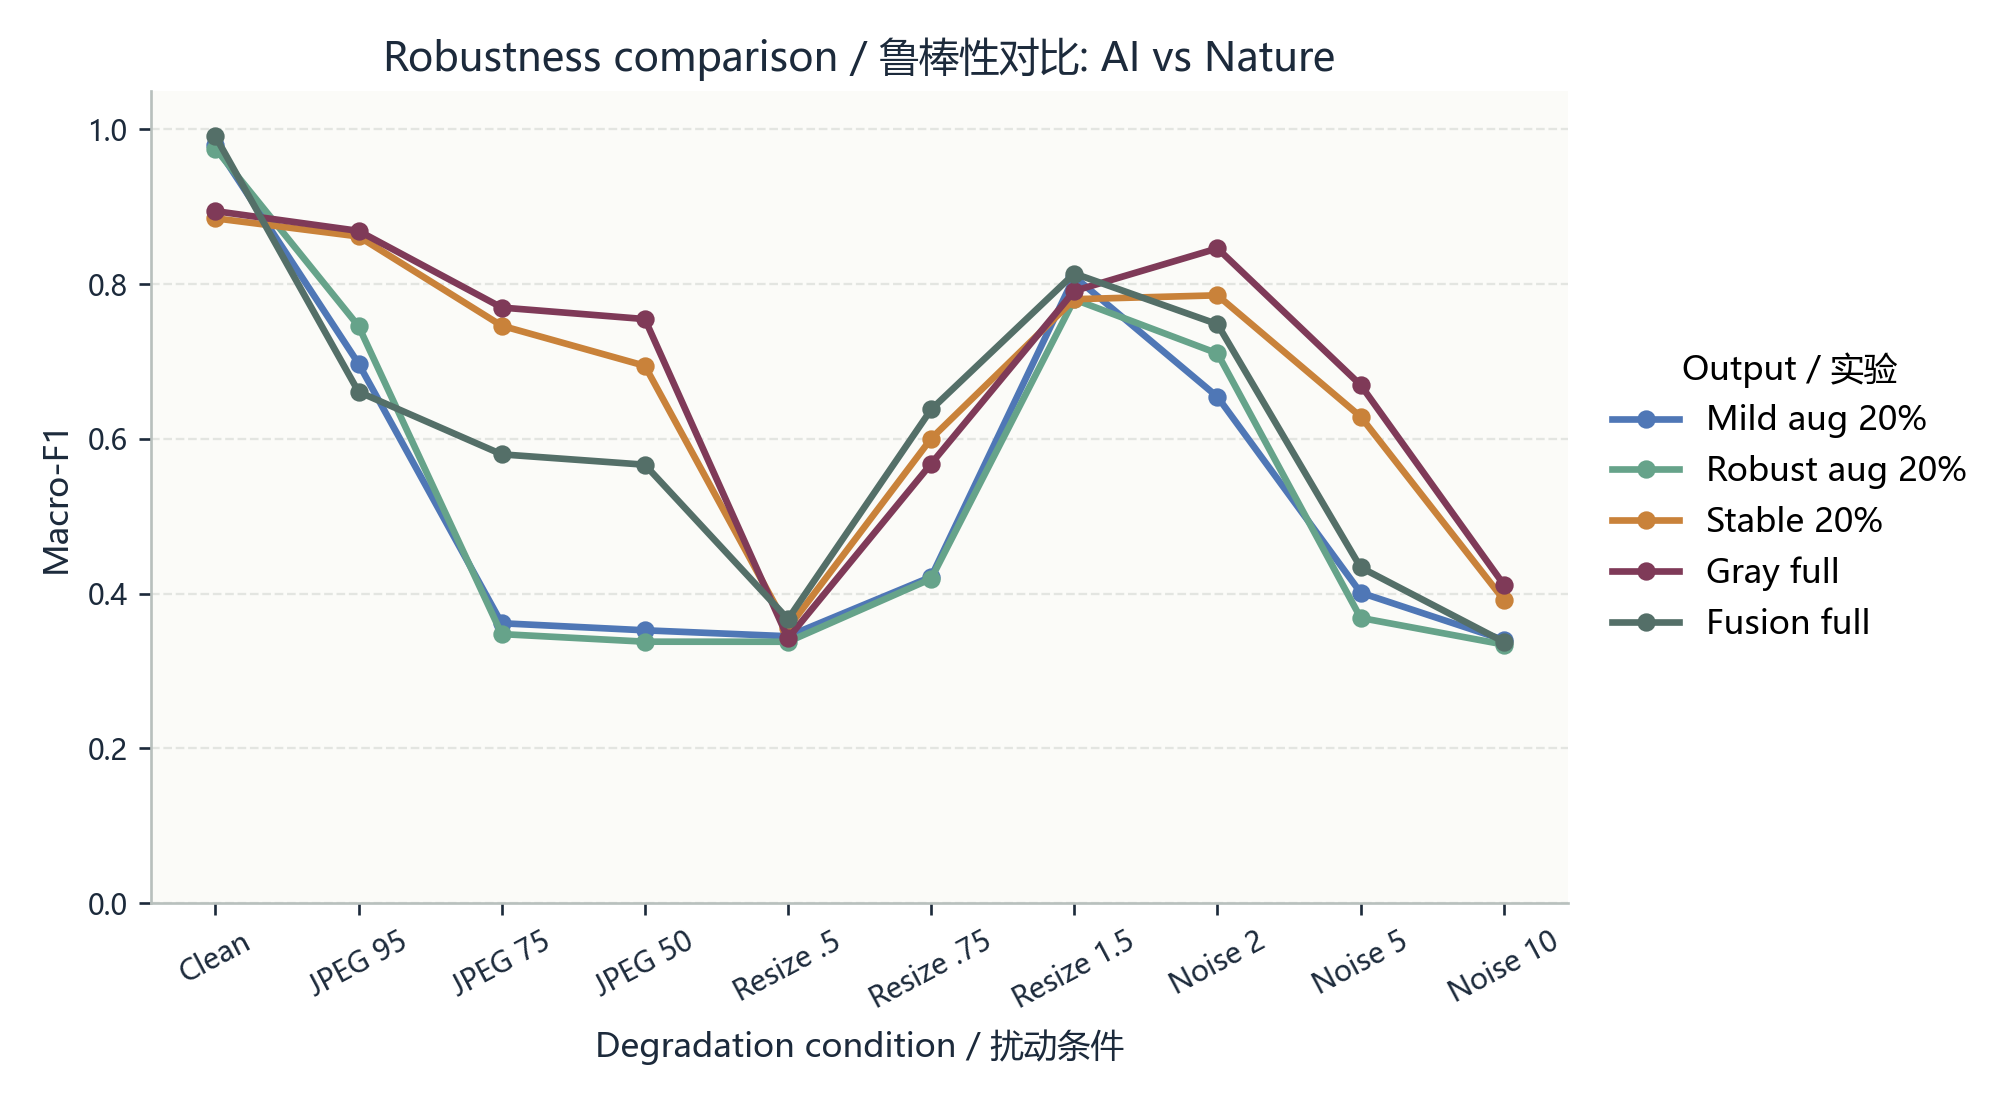

report\figures\robustness_comparison_ai_subsource_attribution.png


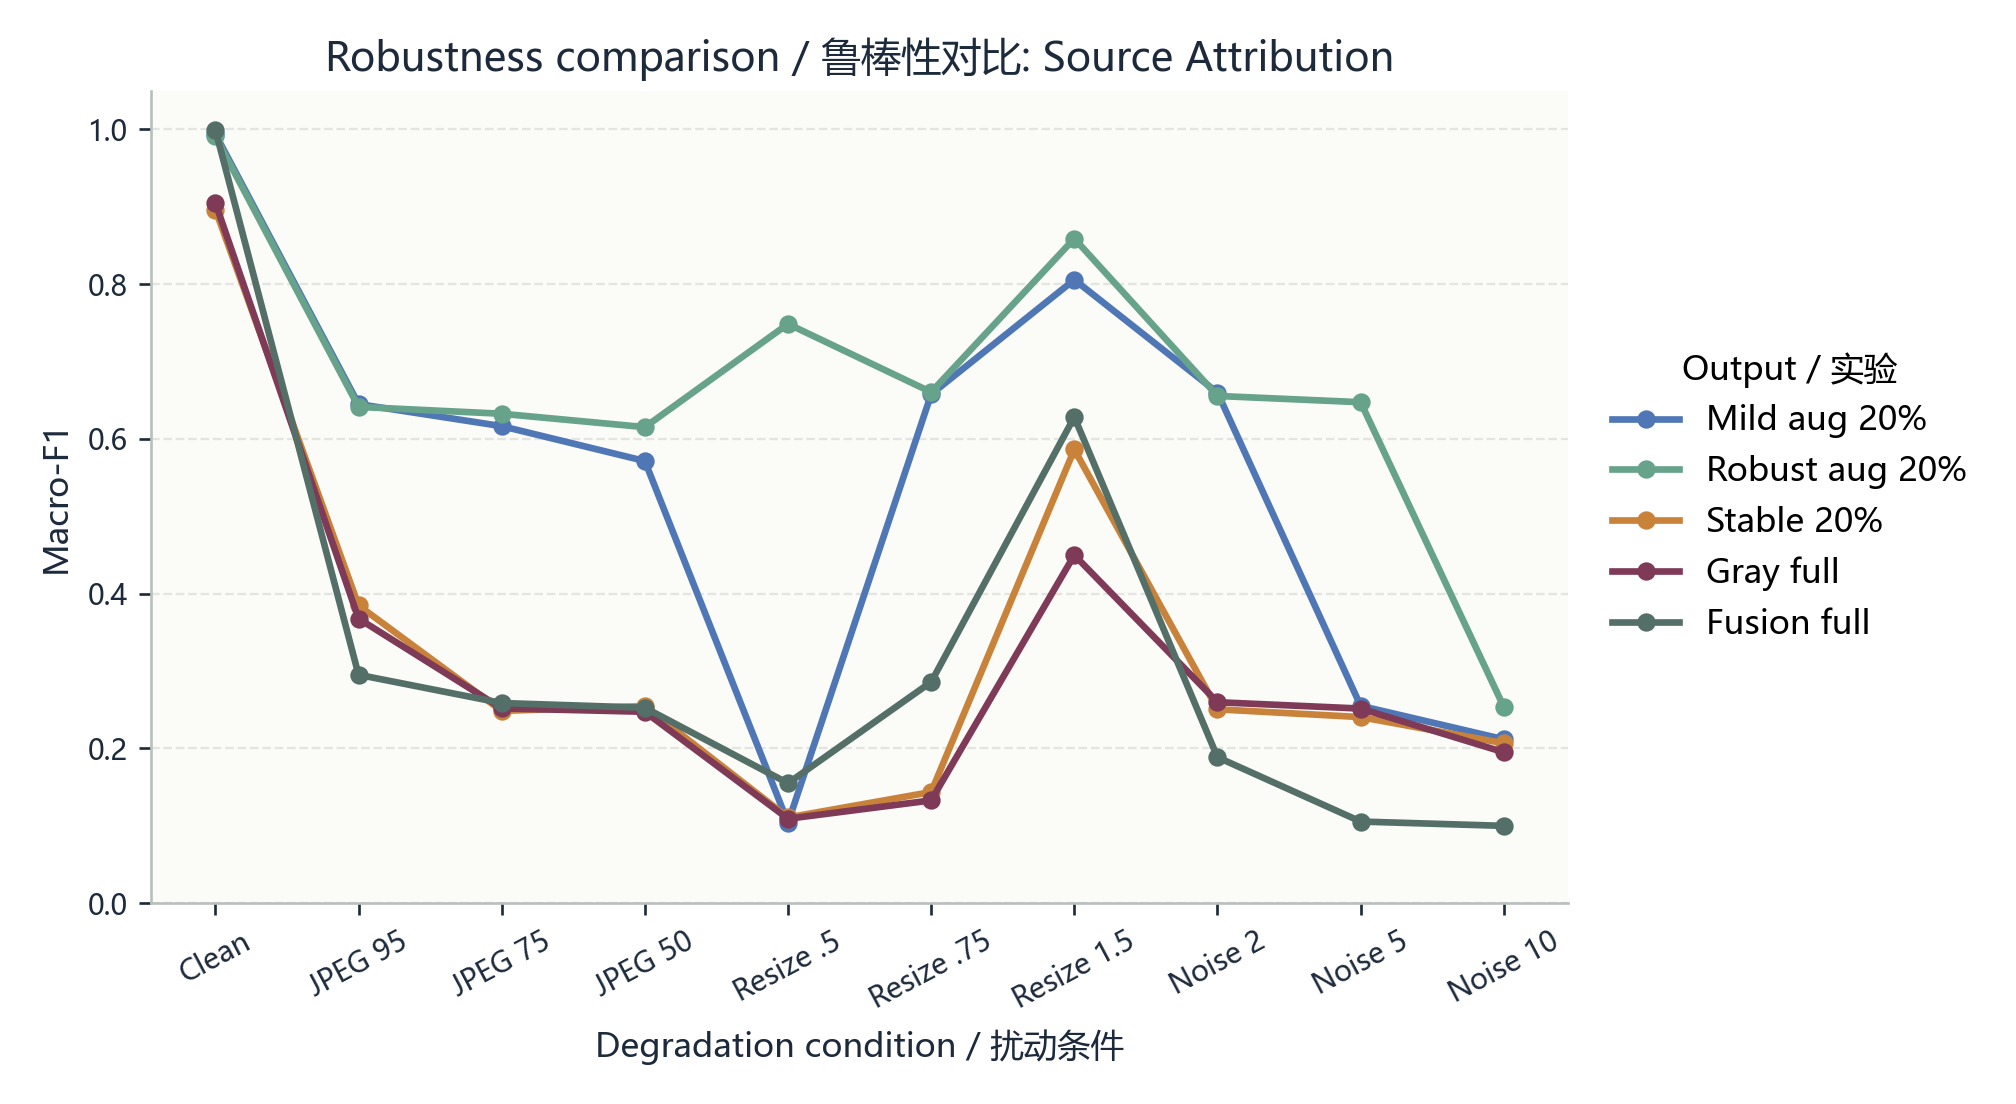

In [9]:
show_fig('robustness_comparison_binary_ai_vs_nature.png')
show_fig('robustness_comparison_ai_subsource_attribution.png')

## 6. Clean-vs-Robustness 权衡

`fusion_freq` 在 clean validation 上最强，但在 degraded 场景下可能明显退化；`stable_freq` 和鲁棒训练配置则用于观察是否能换取更稳定的扰动表现。本节关注的不是单一最高 F1，而是 clean 性能与鲁棒性之间的取舍。


report\tables\robustness_tradeoff.csv


,run,task,clean_macro_f1,degraded_mean_macro_f1,degraded_min_macro_f1,clean_minus_degraded_mean
0,outputs_4gen_20pct_fusion_mild_aug_robust_20pct,ai_subsource_attribution,0.993744,0.502922,0.103995,0.490821
1,outputs_4gen_20pct_fusion_mild_aug_robust_20pct,binary_ai_vs_nature,0.979477,0.487034,0.340193,0.492444
2,outputs_4gen_20pct_fusion_robust_aug_robust_20pct,ai_subsource_attribution,0.990631,0.634743,0.253682,0.355888
3,outputs_4gen_20pct_fusion_robust_aug_robust_20pct,binary_ai_vs_nature,0.974891,0.486868,0.334259,0.488023
4,outputs_4gen_20pct_stable_freq_robust_20pct,ai_subsource_attribution,0.896171,0.269633,0.110826,0.626538
5,outputs_4gen_20pct_stable_freq_robust_20pct,binary_ai_vs_nature,0.884874,0.649341,0.355347,0.235533
6,outputs_4gen_full_best_robust_20pct,ai_subsource_attribution,0.904850,0.251700,0.109203,0.653150
7,outputs_4gen_full_best_robust_20pct,binary_ai_vs_nature,0.894157,0.669061,0.342396,0.225097
8,outputs_v2_full_best_robust_20pct,ai_subsource_attribution,0.999167,0.252206,0.100000,0.746961
9,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,0.990833,0.571734,0.337735,0.419100


report\figures\robustness_tradeoff_binary_ai_vs_nature.png


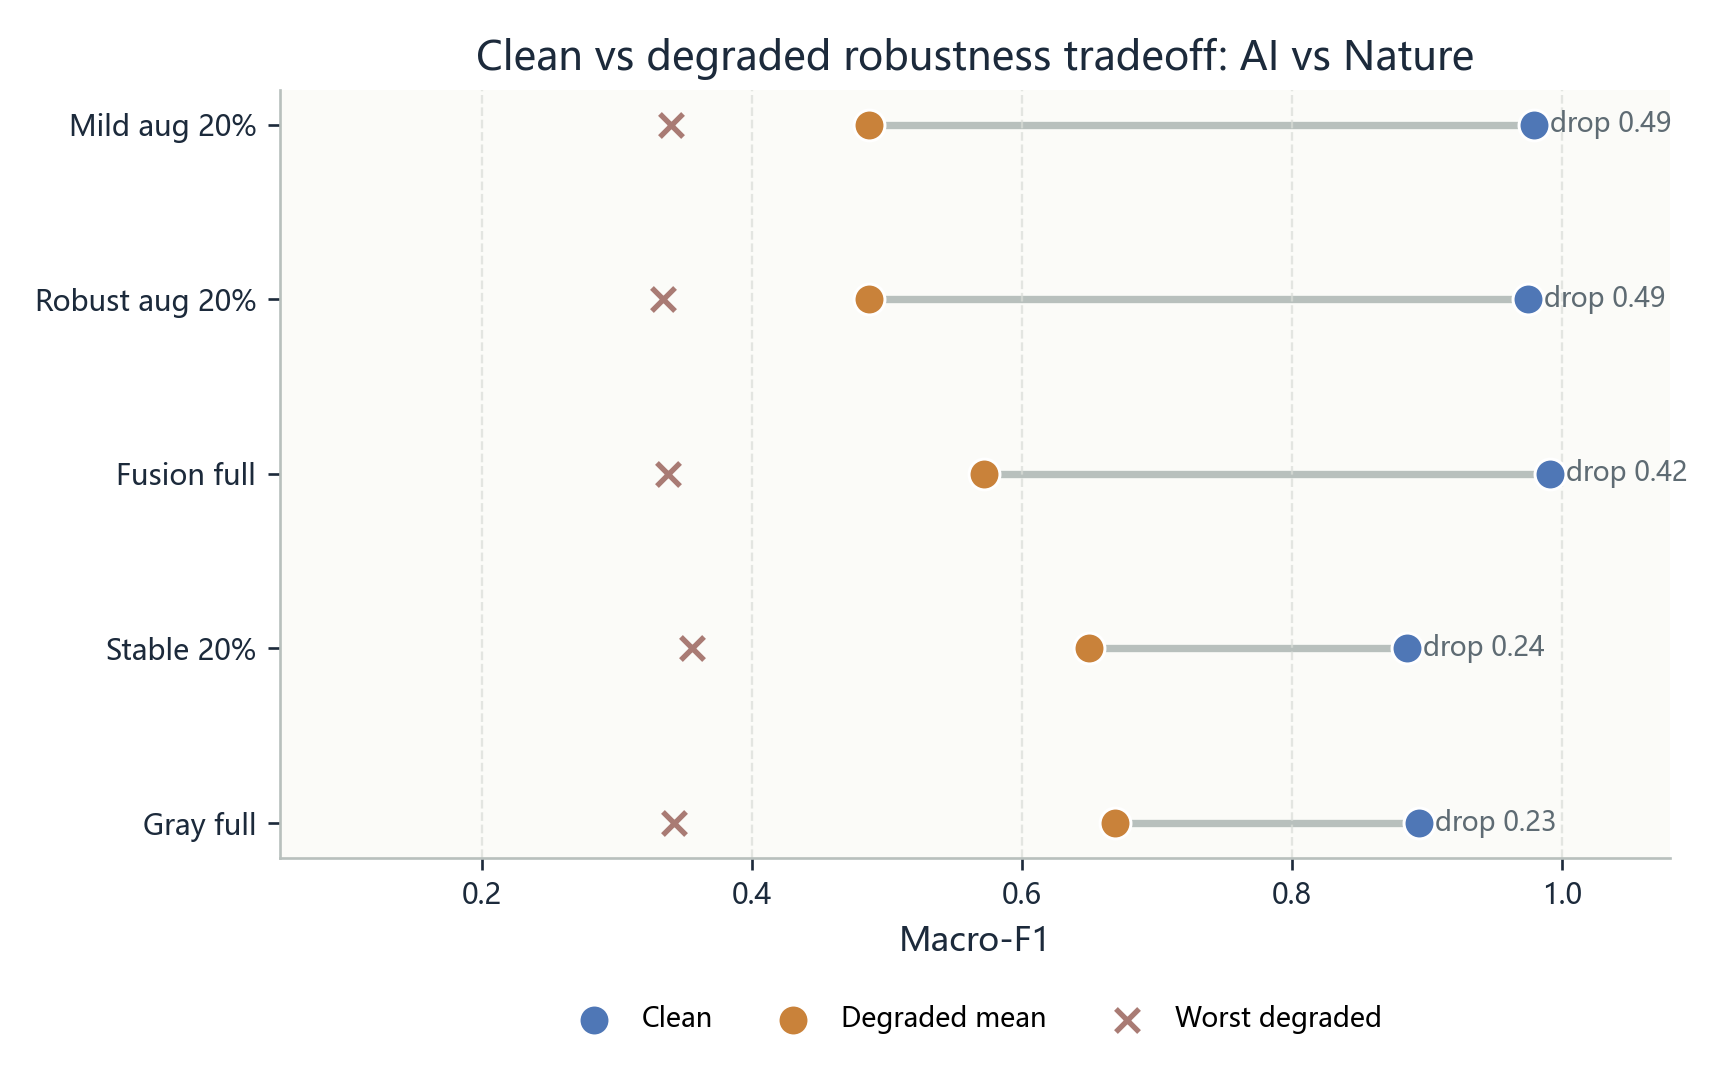

report\figures\robustness_tradeoff_ai_subsource_attribution.png


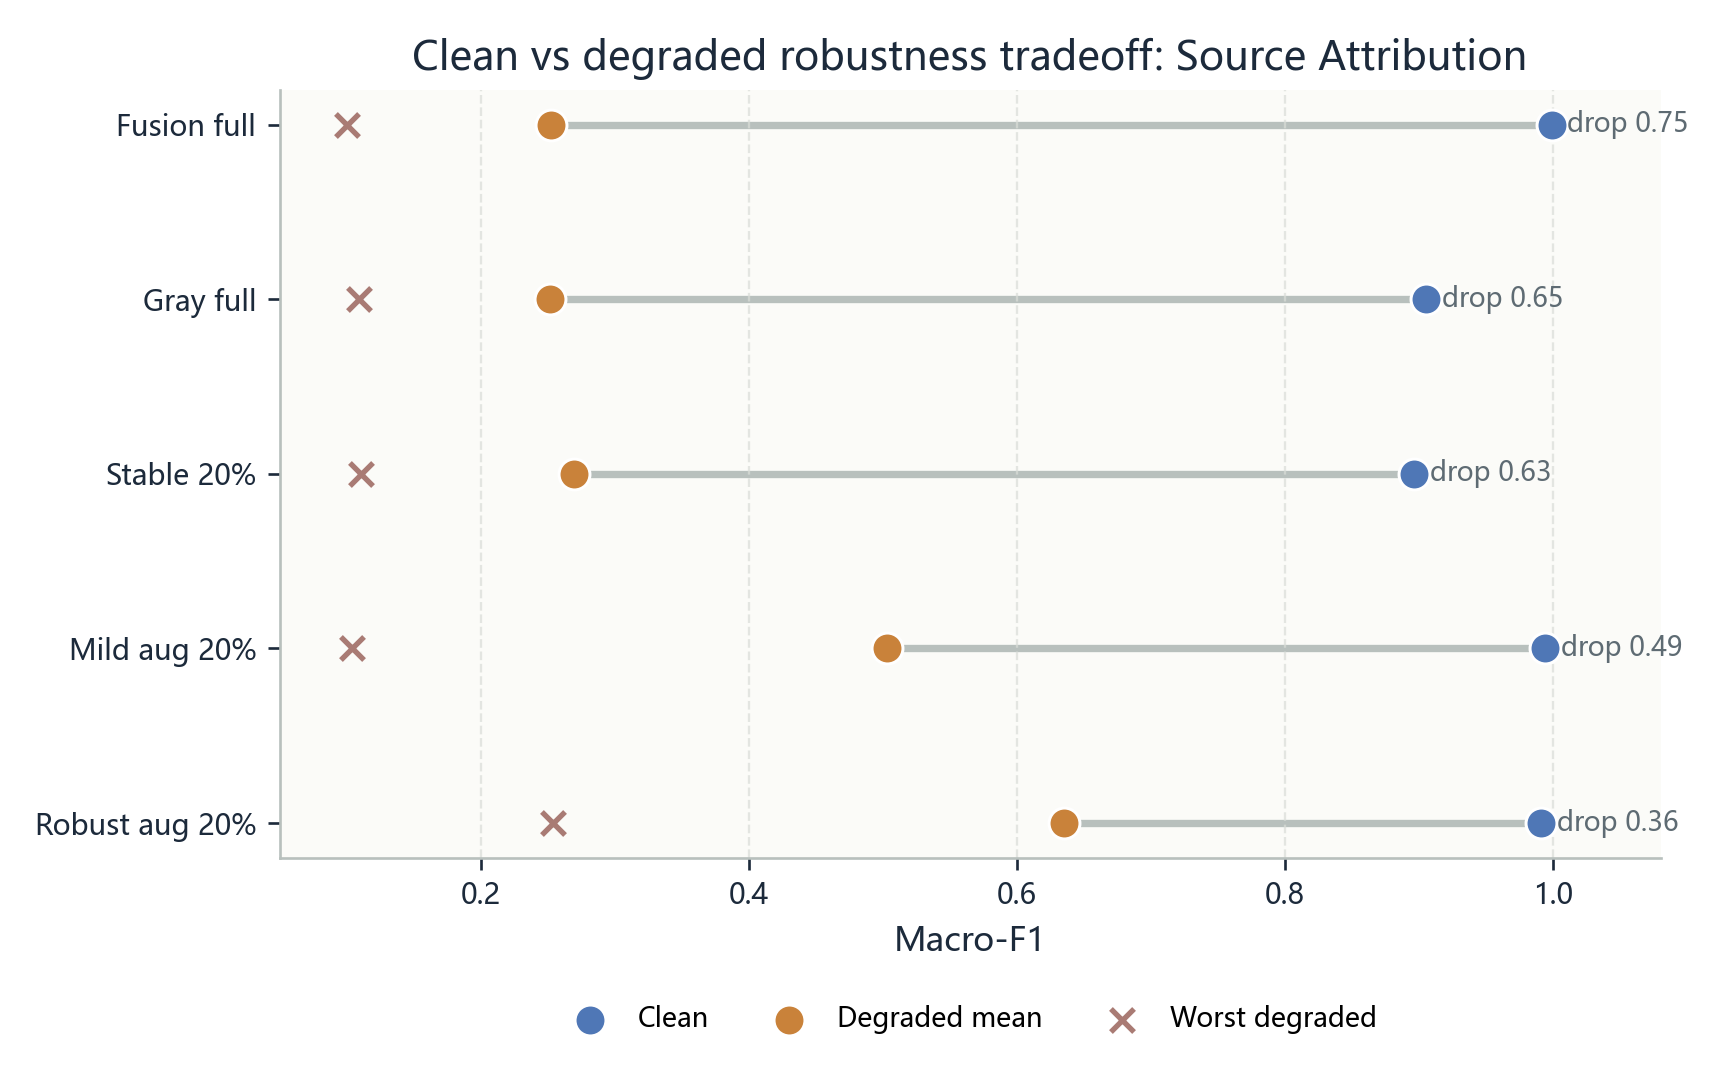

In [10]:
tradeoff = show_csv('robustness_tradeoff.csv', n=20)
show_fig('robustness_tradeoff_binary_ai_vs_nature.png')
show_fig('robustness_tradeoff_ai_subsource_attribution.png')

## 7. 混淆矩阵与特征重要性

混淆矩阵用于查看二分类和归因任务的主要错误模式，特征重要性用于解释 LightGBM 依赖哪些频域统计。报告中重点关注颜色频谱、多尺度频谱、block-DCT 和高频残差等特征族。


report\figures\confusion_binary_ai_vs_nature_lightgbm.png


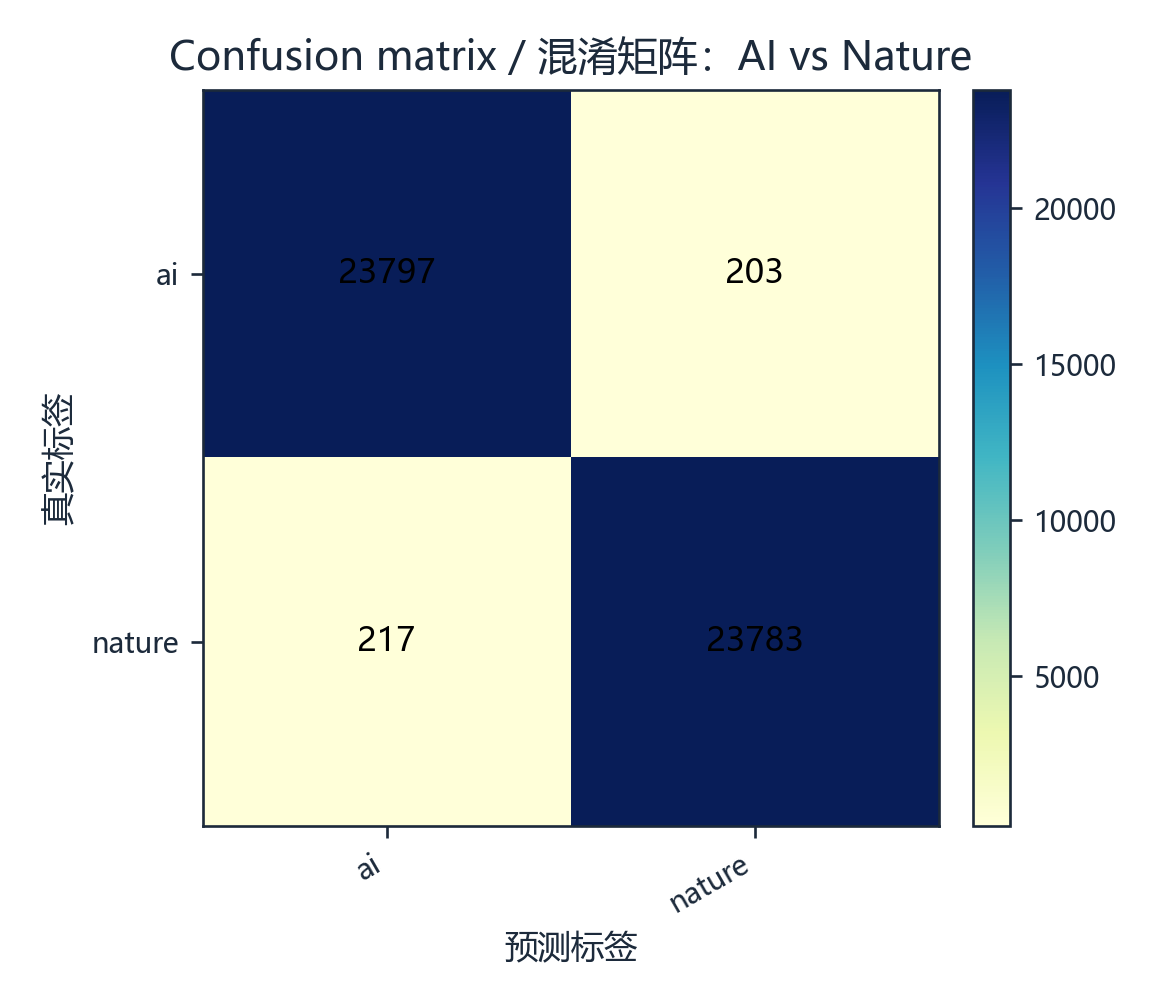

report\figures\confusion_ai_subsource_attribution_lightgbm.png


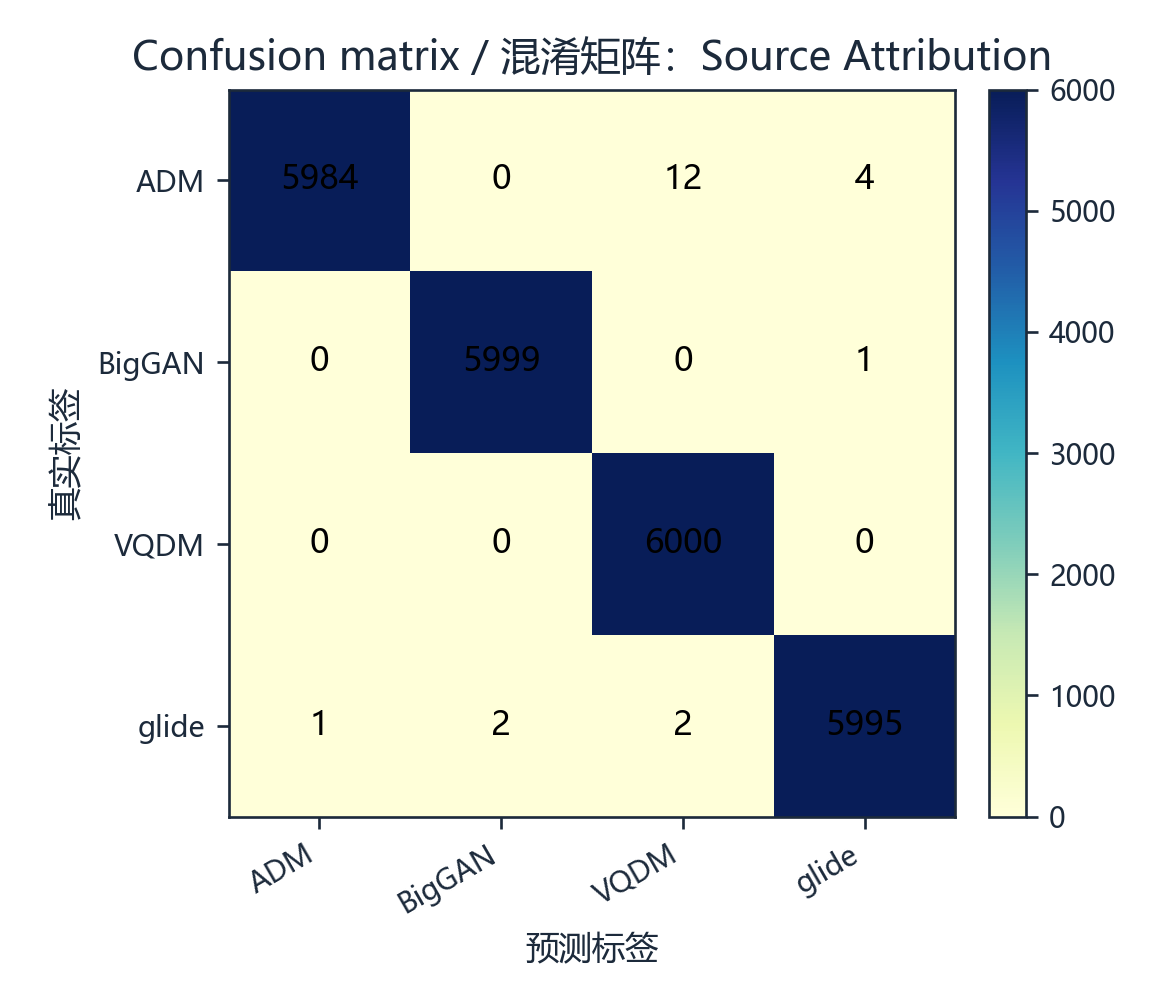

report\tables\top_features_binary_ai_vs_nature.csv


,feature,importance
0,color_ycbcr_cr_hf_std,751.0
1,color_ycbcr_cr_band_mid,697.0
2,block_dct_zigzag_std_9,683.0
3,color_ycbcr_cr_hf_skew,645.0
4,block_dct_zigzag_std_5,627.0
5,color_ycbcr_cb_hf_skew,590.0
6,color_ycbcr_cr_band_high,583.0
7,color_ycbcr_cb_hf_std,557.0
8,color_ycbcr_cb_band_mid,550.0
9,block_dct_band_mid_mean,547.0


,feature,importance
0,color_ycbcr_cr_hf_std,751.0
1,color_ycbcr_cr_band_mid,697.0
2,block_dct_zigzag_std_9,683.0
3,color_ycbcr_cr_hf_skew,645.0
4,block_dct_zigzag_std_5,627.0
5,color_ycbcr_cb_hf_skew,590.0
6,color_ycbcr_cr_band_high,583.0
7,color_ycbcr_cb_hf_std,557.0
8,color_ycbcr_cb_band_mid,550.0
9,block_dct_band_mid_mean,547.0


In [11]:
show_fig('confusion_binary_ai_vs_nature_lightgbm.png', width=650)
show_fig('confusion_ai_subsource_attribution_lightgbm.png', width=650)
show_csv('top_features_binary_ai_vs_nature.csv', n=20)

## 8. 置信度与拒识分析

除了预测类别，本项目还导出预测概率、margin 和 entropy，并绘制 coverage-accuracy 曲线。该分析用于说明：当模型置信度不足时，可以选择输出“不确定”并交给人工复核，从而提升高覆盖率之外的使用安全性。


report\tables\confidence_by_generator_binary_ai_vs_nature.csv


,generator,n_samples,accuracy,mean_confidence,mean_margin,mean_entropy
0,ADM,12000,0.988667,0.980664,0.961327,0.083266
1,BigGAN,12000,0.995250,0.990803,0.981605,0.044664
2,VQDM,12000,0.987917,0.972484,0.944967,0.118316
3,glide,12000,0.993167,0.988023,0.976047,0.053891


report\tables\confidence_by_generator_ai_subsource_attribution.csv


,generator,n_samples,accuracy,mean_confidence,mean_margin,mean_entropy
0,ADM,6000,0.997333,0.999102,0.998207,0.001614
1,BigGAN,6000,0.999833,0.999975,0.999950,0.000053
2,VQDM,6000,1.000000,0.999704,0.999437,0.000522
3,glide,6000,0.999167,0.999629,0.999259,0.000727


report\figures\confidence_coverage_binary_ai_vs_nature.png


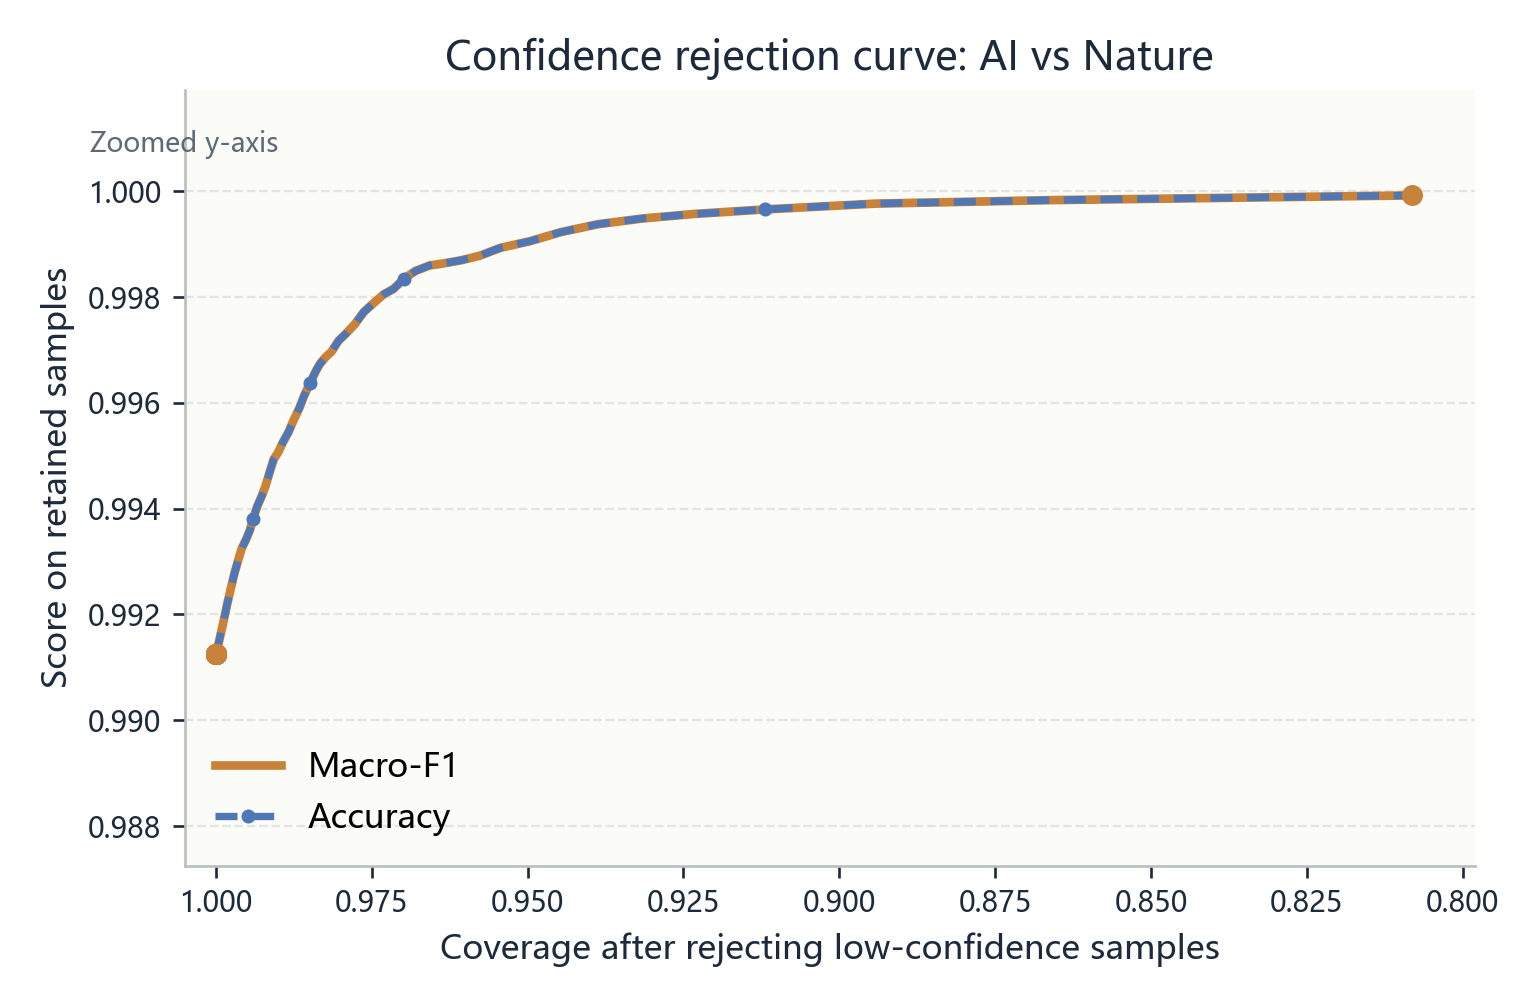

report\figures\confidence_histogram_binary_ai_vs_nature.png


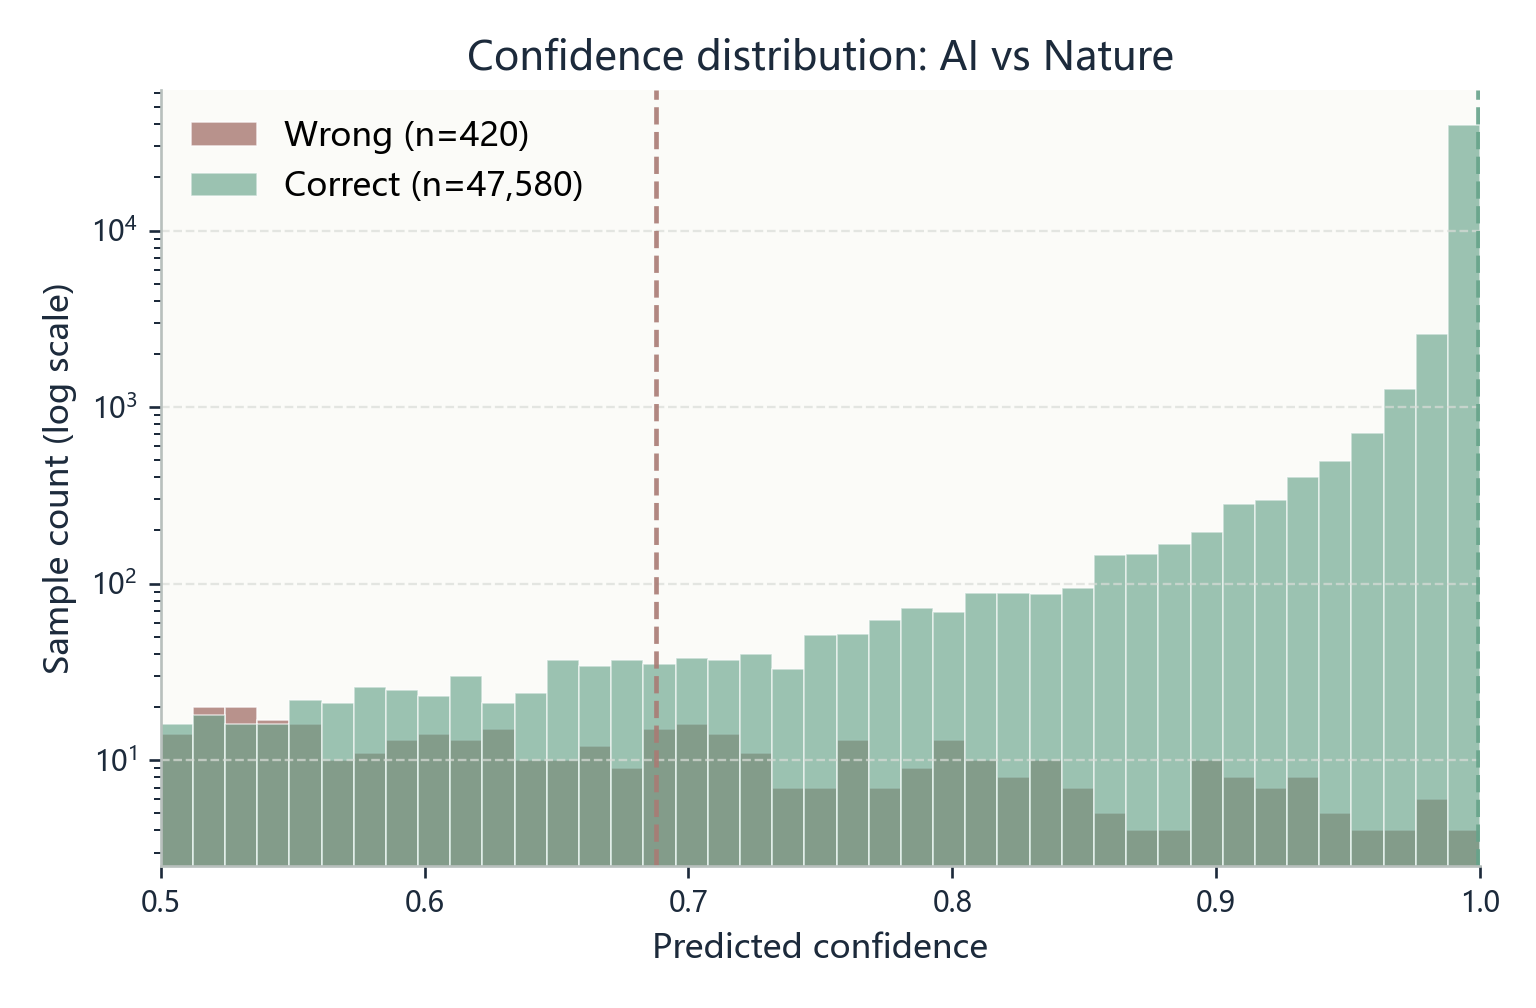

In [12]:
show_csv('confidence_by_generator_binary_ai_vs_nature.csv')
show_csv('confidence_by_generator_ai_subsource_attribution.csv')
show_fig('confidence_coverage_binary_ai_vs_nature.png')
show_fig('confidence_histogram_binary_ai_vs_nature.png')

## 9. 错误模式分析

错误分析按 generator、真实标签和预测标签统计误判情况。二分类中关注 AI 被判成 nature 或 nature 被判成 AI 的分布；归因任务中重点检查 ADM/VQDM 等生成源之间是否存在系统性混淆。


In [13]:
show_csv('v2_error_breakdown_binary_ai_vs_nature.csv', n=10)
show_csv('v2_error_breakdown_ai_subsource_attribution.csv', n=10)

report\tables\v2_error_breakdown_binary_ai_vs_nature.csv


,generator,true_label,pred_label,errors,mean_confidence
0,ADM,ai,nature,1703,0.744853
1,VQDM,ai,nature,822,0.681645
2,ADM,nature,ai,567,0.675598
3,VQDM,nature,ai,536,0.683533
4,BigGAN,nature,ai,509,0.682890
5,glide,nature,ai,507,0.678668
6,glide,ai,nature,166,0.718399
7,BigGAN,ai,nature,3,0.699905


report\tables\v2_error_breakdown_ai_subsource_attribution.csv


,generator,true_label,pred_label,errors,mean_confidence
0,ADM,ADM,VQDM,990,0.673908
1,VQDM,VQDM,ADM,830,0.667530
2,ADM,ADM,glide,189,0.760765
3,glide,glide,ADM,153,0.727695
4,glide,glide,VQDM,16,0.641493
5,glide,glide,BigGAN,5,0.878660
6,BigGAN,BigGAN,glide,3,0.802703
7,VQDM,VQDM,glide,2,0.494012
8,ADM,ADM,BigGAN,1,0.995235


,generator,true_label,pred_label,errors,mean_confidence
0,ADM,ADM,VQDM,990,0.673908
1,VQDM,VQDM,ADM,830,0.667530
2,ADM,ADM,glide,189,0.760765
3,glide,glide,ADM,153,0.727695
4,glide,glide,VQDM,16,0.641493
5,glide,glide,BigGAN,5,0.878660
6,BigGAN,BigGAN,glide,3,0.802703
7,VQDM,VQDM,glide,2,0.494012
8,ADM,ADM,BigGAN,1,0.995235


## 10. 复现实验命令

下面列出报告主结果和鲁棒性诊断对应的核心命令。实际提交时不要求重新运行这些长实验；Notebook 保留命令是为了说明结果如何生成，并帮助助教或组员在需要时复现实验流程。


In [14]:
print(r'''
# final clean route
.\.venv\Scripts\python.exe test.py `
  --dataset-root PATH_TO_GenImage_data `
  --out-dir outputs_v2_full_best `
  --sample-fraction 1.0 --sample-seed 42 `
  --feature-profile fusion_freq --feature-set all `
  --lgbm-profile wide --model-set lightgbm --model-architecture flat `
  --train-augmentation none --calibrate-threshold `
  --lightgbm-device gpu --num-workers 16 --feature-chunksize 64 `
  --feature-cache-dir feature_cache_fusion --sample-cache-dir sample_cache `
  --skip-robustness --resume-completed-tasks

# robustness diagnostic
.\.venv\Scripts\python.exe scripts\evaluate_best_robustness.py `
  --dataset-root PATH_TO_GenImage_data `
  --model-output outputs_v2_full_best `
  --out-dir outputs_v2_full_best_robust_20pct `
  --sample-fraction 0.20 --sample-seed 42 --tasks both `
  --num-workers 16 --feature-chunksize 64 `
  --robust-cache-dir robustness_cache_fusion

# extension suite
.\scripts\run_all_4gen_extension_experiments.ps1 `
  -DatasetRoot PATH_TO_GenImage_data `
  -LightgbmDevice cpu -LogoFraction 0.20 `
  -CandidateFraction 0.20 -RobustnessFraction 0.20

# final validation
.\.venv\Scripts\python.exe scripts\validate_submission.py `
  --dataset-root PATH_TO_GenImage_data --write-report
''')


# final clean route
.\.venv\Scripts\python.exe test.py `
  --dataset-root PATH_TO_GenImage_data `
  --out-dir outputs_v2_full_best `
  --sample-fraction 1.0 --sample-seed 42 `
  --feature-profile fusion_freq --feature-set all `
  --lgbm-profile wide --model-set lightgbm --model-architecture flat `
  --train-augmentation none --calibrate-threshold `
  --lightgbm-device gpu --num-workers 16 --feature-chunksize 64 `
  --feature-cache-dir feature_cache_fusion --sample-cache-dir sample_cache `
  --skip-robustness --resume-completed-tasks

# robustness diagnostic
.\.venv\Scripts\python.exe scripts\evaluate_best_robustness.py `
  --dataset-root PATH_TO_GenImage_data `
  --model-output outputs_v2_full_best `
  --out-dir outputs_v2_full_best_robust_20pct `
  --sample-fraction 0.20 --sample-seed 42 --tasks both `
  --num-workers 16 --feature-chunksize 64 `
  --robust-cache-dir robustness_cache_fusion

# extension suite
.\scripts\run_all_4gen_extension_experiments.ps1 `
  -DatasetRoot PATH_TO_Ge

## 11. 总结

本项目证明了频域统计可以有效支持 clean AIGC 图像检测和生成源归因，但 degraded evaluation 与 leave-one-generator-out 实验也说明，JPEG、resize、noise 和 unseen generator 会削弱模型可靠性。因此最终结论不是“鲁棒性已经解决”，而是：频谱融合特征能提供强 clean 性能和清晰解释，同时仍需要针对真实后处理和跨生成器泛化继续优化。


[SOURCE_CODE_APPENDIX]

## 12. 完整源码附录

下面的代码单元使用 `%%writefile` 保存项目源码。它们把本项目实际参与实验的 `requirements.txt`、`train.py`、`test.py`、`src/` 和关键 `scripts/` 都放入同一个 Notebook 中。如果从空目录执行这些单元，会重新写出对应源码文件；报告中的大规模实验结果仍建议直接读取已有 CSV/PNG。

[SOURCE_CODE_APPENDIX]

### `requirements.txt`

In [15]:
%%writefile requirements.txt
numpy
pandas
scipy
scikit-learn
lightgbm
pillow
tqdm
joblib
matplotlib
ipython
notebook


Overwriting requirements.txt


[SOURCE_CODE_APPENDIX]

### `train.py`

In [16]:
%%writefile train.py
from __future__ import annotations

import argparse
from concurrent.futures import ProcessPoolExecutor
import json
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm

from src.data_utils import (
    Sample,
    discover_ai_subsource_from_roots,
    discover_ai_subsource_split,
    discover_binary_split_multi_root,
    discover_model_roots,
    summarize_labels,
    validate_non_empty,
)
from src.features import (
    FEATURE_SET_CHOICES,
    FEATURE_PROFILE_CHOICES,
    TRAIN_AUGMENTATION_CHOICES,
    FeatureConfig,
    extract_feature_variants_from_path,
    make_feature_names,
    select_feature_columns,
)
from src.robustness import evaluate_robustness
from src.training import (
    LGBM_PROFILE_CHOICES,
    MODEL_ARCHITECTURE_CHOICES,
    MODEL_SET_CHOICES,
    _predict,
    _predict_proba,
    feature_importance_df,
    train_and_select,
)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="AIGC frequency-domain fingerprint training pipeline")
    parser.add_argument("--dataset-root", type=str, default="data", help="Dataset root folder")
    parser.add_argument("--out-dir", type=str, default="outputs", help="Output directory")
    parser.add_argument("--image-size", type=int, default=256)
    parser.add_argument("--radial-bins", type=int, default=64)
    parser.add_argument("--angular-bins", type=int, default=18)
    parser.add_argument("--patch-grid", type=int, default=4)
    parser.add_argument(
        "--num-workers",
        type=int,
        default=0,
        help="Parallel workers for feature extraction. 0 or 1 runs sequentially.",
    )
    parser.add_argument(
        "--feature-chunksize",
        type=int,
        default=32,
        help="Chunk size for parallel feature extraction.",
    )
    parser.add_argument(
        "--lightgbm-device",
        choices=["cpu", "gpu"],
        default="cpu",
        help="Device for LightGBM training. Feature extraction remains CPU-based.",
    )
    parser.add_argument(
        "--lgbm-profile",
        choices=LGBM_PROFILE_CHOICES,
        default="baseline",
        help="LightGBM hyperparameter profile.",
    )
    parser.add_argument(
        "--model-set",
        choices=MODEL_SET_CHOICES,
        default="all",
        help="Candidate models to train. Use lightgbm for tuning-only runs.",
    )
    parser.add_argument(
        "--feature-cache-dir",
        type=str,
        default="",
        help="Optional directory for cached full feature matrices.",
    )
    parser.add_argument(
        "--feature-set",
        choices=FEATURE_SET_CHOICES,
        default="all",
        help="Feature subset used for training. Cache always stores the full feature vector.",
    )
    parser.add_argument(
        "--feature-profile",
        choices=FEATURE_PROFILE_CHOICES,
        default="baseline",
        help="Feature extraction profile. Use enhanced to append extra interpretable frequency features.",
    )
    parser.add_argument(
        "--model-architecture",
        choices=MODEL_ARCHITECTURE_CHOICES,
        default="flat",
        help="Model architecture for LightGBM-based experiments.",
    )
    parser.add_argument(
        "--train-augmentation",
        choices=TRAIN_AUGMENTATION_CHOICES,
        default="none",
        help="Feature-space training augmentation generated from image perturbations. Validation is never augmented.",
    )
    parser.add_argument(
        "--calibrate-threshold",
        action="store_true",
        help="Use a training-only calibration split to tune binary decision threshold.",
    )
    parser.add_argument("--skip-robustness", action="store_true", help="Skip robustness evaluation")
    return parser.parse_args()


def encode_labels(samples: Sequence[Sample], label_to_id: Dict[str, int]) -> np.ndarray:
    return np.asarray([label_to_id[s.label] for s in samples], dtype=np.int64)


def _cfg_json(cfg: FeatureConfig) -> str:
    payload = cfg.__dict__.copy()
    # Keep baseline cache compatibility with feature matrices written before
    # feature_profile existed. Enhanced caches still get a distinct signature.
    if payload.get("feature_profile") == "baseline":
        payload.pop("feature_profile", None)
    return json.dumps(payload, sort_keys=True)


def _safe_cache_token(value: str) -> str:
    keep = []
    for ch in value:
        keep.append(ch if ch.isalnum() or ch in ("-", "_", ".") else "_")
    return "".join(keep).strip("_") or "default"


def sample_group(sample: Sample) -> str:
    parts = list(sample.path.parts)
    for marker in ("train", "val", "test"):
        if marker in parts:
            idx = parts.index(marker)
            if idx > 0:
                return parts[idx - 1]
    return sample.path.parent.name


def feature_cache_path(
    cache_dir: Path | None,
    task_name: str,
    split_name: str,
    cache_tag: str,
) -> Path | None:
    if cache_dir is None:
        return None
    name = f"{task_name}_{split_name}_{_safe_cache_token(cache_tag)}.npz"
    return cache_dir / name


def _load_feature_cache(
    cache_path: Path,
    samples: Sequence[Sample],
    cfg: FeatureConfig,
    desc: str,
) -> Tuple[np.ndarray, List[Sample], List[Tuple[str, str]]] | None:
    if not cache_path.exists():
        return None

    expected_paths = [str(s.path) for s in samples]
    expected_labels = [s.label for s in samples]
    try:
        with np.load(cache_path, allow_pickle=False) as data:
            if str(data["cfg_json"][0]) != _cfg_json(cfg):
                return None
            if data["input_paths"].tolist() != expected_paths:
                return None
            if data["input_labels"].tolist() != expected_labels:
                return None

            X = data["X"].astype(np.float32, copy=False)
            kept_samples = [
                Sample(path=Path(p), label=str(label))
                for p, label in zip(data["kept_paths"].tolist(), data["kept_labels"].tolist())
            ]
            skipped = [
                (str(path), str(err))
                for path, err in zip(data["skipped_paths"].tolist(), data["skipped_errors"].tolist())
            ]
            print(f"[cache hit] {desc}: {cache_path}")
            return X, kept_samples, skipped
    except Exception as exc:
        print(f"[cache ignored] {cache_path}: {exc}")
        return None


def _write_feature_cache(
    cache_path: Path | None,
    samples: Sequence[Sample],
    cfg: FeatureConfig,
    X: np.ndarray,
    kept_samples: Sequence[Sample],
    skipped: Sequence[Tuple[str, str]],
    desc: str,
) -> None:
    if cache_path is None:
        return

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    skipped_paths = [p for p, _ in skipped]
    skipped_errors = [err for _, err in skipped]
    np.savez(
        cache_path,
        X=X.astype(np.float32, copy=False),
        cfg_json=np.asarray([_cfg_json(cfg)]),
        input_paths=np.asarray([str(s.path) for s in samples]),
        input_labels=np.asarray([s.label for s in samples]),
        kept_paths=np.asarray([str(s.path) for s in kept_samples]),
        kept_labels=np.asarray([s.label for s in kept_samples]),
        skipped_paths=np.asarray(skipped_paths),
        skipped_errors=np.asarray(skipped_errors),
    )
    print(f"[cache write] {desc}: {cache_path}")


def extract_matrix(
    samples: Sequence[Sample],
    cfg: FeatureConfig,
    desc: str,
    num_workers: int = 0,
    chunksize: int = 32,
    cache_path: Path | None = None,
    train_augmentation: str = "none",
) -> Tuple[np.ndarray, List[Sample], List[Tuple[str, str]]]:
    if cache_path is not None:
        cached = _load_feature_cache(cache_path, samples, cfg, desc)
        if cached is not None:
            return cached

    feats: List[np.ndarray] = []
    kept_samples: List[Sample] = []
    skipped: List[Tuple[str, str]] = []

    if num_workers and num_workers > 1 and len(samples) > 1:
        cfg_dict = cfg.__dict__.copy()
        worker_count = min(num_workers, len(samples))
        payloads = ((i, s, cfg_dict, train_augmentation) for i, s in enumerate(samples))
        with ProcessPoolExecutor(max_workers=worker_count) as executor:
            iterator = executor.map(_extract_one_feature, payloads, chunksize=max(1, chunksize))
            for _idx, sample, sample_feats, err in tqdm(iterator, total=len(samples), desc=desc, leave=False):
                if err is not None:
                    skipped.append(err)
                elif sample_feats:
                    for feat in sample_feats:
                        feats.append(feat)
                        kept_samples.append(sample)
        X = np.asarray(feats, dtype=np.float32)
        _write_feature_cache(cache_path, samples, cfg, X, kept_samples, skipped, desc)
        return X, kept_samples, skipped

    for s in tqdm(samples, desc=desc, leave=False):
        try:
            sample_feats = extract_feature_variants_from_path(
                str(s.path),
                cfg,
                train_augmentation=train_augmentation,
                seed=abs(hash(str(s.path))) % (2**32),
            )
            for feat in sample_feats:
                feats.append(feat)
                kept_samples.append(s)
        except Exception as exc:
            skipped.append((str(s.path), str(exc)))
    X = np.asarray(feats, dtype=np.float32)
    _write_feature_cache(cache_path, samples, cfg, X, kept_samples, skipped, desc)
    return X, kept_samples, skipped


def _extract_one_feature(
    payload: Tuple[int, Sample, Dict[str, object], str]
) -> Tuple[int, Sample, List[np.ndarray] | None, Tuple[str, str] | None]:
    idx, sample, cfg_dict, train_augmentation = payload
    cfg = FeatureConfig(**cfg_dict)
    try:
        feats = extract_feature_variants_from_path(
            str(sample.path),
            cfg,
            train_augmentation=train_augmentation,
            seed=(idx + 17) % (2**32),
        )
        return idx, sample, feats, None
    except Exception as exc:
        return idx, sample, None, (str(sample.path), str(exc))


def save_metrics_block(
    out_path: Path,
    best_name: str,
    all_results: List[dict],
    label_names: List[str],
) -> None:
    content = {
        "best_model": best_name,
        "all_models": all_results,
        "labels": label_names,
    }
    out_path.write_text(json.dumps(content, indent=2), encoding="utf-8")


def _probability_entropy(proba: np.ndarray) -> float:
    probs = np.asarray(proba, dtype=np.float64)
    probs = probs / (probs.sum() + 1e-12)
    if probs.size <= 1:
        return 0.0
    return float(-np.sum(probs * np.log(probs + 1e-12)) / np.log(probs.size))


def save_prediction_details(
    task_out: Path,
    model: object,
    X_val: np.ndarray,
    y_val: np.ndarray,
    val_samples: Sequence[Sample],
    label_names: List[str],
    val_groups: Sequence[str] | None = None,
) -> None:
    pred = _predict(model, X_val, val_groups)
    proba = _predict_proba(model, X_val, val_groups)
    ai_idx = next((idx for idx, label in enumerate(label_names) if label.lower() == "ai"), None)
    rows = []
    for idx, sample in enumerate(val_samples):
        pred_id = int(pred[idx])
        true_id = int(y_val[idx])
        row = {
            "path": str(sample.path),
            "generator": sample_group(sample),
            "true_label": label_names[true_id],
            "pred_label": label_names[pred_id],
            "correct": bool(true_id == pred_id),
            "confidence": float("nan"),
            "margin": float("nan"),
            "entropy": float("nan"),
            "ai_probability": float("nan"),
        }
        if proba is not None:
            probs = np.asarray(proba[idx], dtype=np.float64)
            order = np.sort(probs)
            row["confidence"] = float(order[-1])
            row["margin"] = float(order[-1] - order[-2]) if order.size >= 2 else float(order[-1])
            row["entropy"] = _probability_entropy(probs)
            if ai_idx is not None and ai_idx < probs.size:
                row["ai_probability"] = float(probs[ai_idx])
        rows.append(row)

    details = pd.DataFrame(rows)
    details.to_csv(task_out / "prediction_details.csv", index=False)
    details[~details["correct"]].to_csv(task_out / "prediction_errors.csv", index=False)


def run_task(
    task_name: str,
    train_samples: Sequence[Sample],
    val_samples: Sequence[Sample],
    out_dir: Path,
    cfg: FeatureConfig,
    run_robustness: bool,
    lightgbm_device: str = "cpu",
    num_workers: int = 0,
    feature_chunksize: int = 32,
    feature_cache_dir: Path | None = None,
    cache_tag: str = "default",
    feature_set: str = "all",
    lightgbm_profile: str = "baseline",
    model_set: str = "all",
    model_architecture: str = "flat",
    train_augmentation: str = "none",
    calibrate_threshold: bool = False,
) -> None:
    print(f"\n===== Task: {task_name} =====")
    print(f"Train counts: {summarize_labels(train_samples)}")
    print(f"Val counts:   {summarize_labels(val_samples)}")
    print(f"Feature set:  {feature_set}")
    print(f"Feature profile: {cfg.feature_profile}")
    print(f"LGBM profile: {lightgbm_profile}")
    print(f"Model set:    {model_set}")
    print(f"Model architecture: {model_architecture}")
    print(f"Train augmentation: {train_augmentation}")
    print(f"Calibrate threshold: {calibrate_threshold}")

    label_names = sorted({s.label for s in train_samples})
    label_to_id = {name: i for i, name in enumerate(label_names)}

    X_train, train_kept, train_skipped = extract_matrix(
        train_samples,
        cfg,
        desc=f"{task_name} train features",
        num_workers=num_workers,
        chunksize=feature_chunksize,
        cache_path=feature_cache_path(
            feature_cache_dir,
            task_name,
            "train",
            f"{cache_tag}_aug{train_augmentation}",
        ),
        train_augmentation=train_augmentation,
    )
    X_val, val_kept, val_skipped = extract_matrix(
        val_samples,
        cfg,
        desc=f"{task_name} val(test) features",
        num_workers=num_workers,
        chunksize=feature_chunksize,
        cache_path=feature_cache_path(feature_cache_dir, task_name, "val", cache_tag),
        train_augmentation="none",
    )
    y_train = encode_labels(train_kept, label_to_id)
    y_val = encode_labels(val_kept, label_to_id)

    if len(train_skipped) > 0 or len(val_skipped) > 0:
        print(
            f"[Warning] Skipped invalid images - train: {len(train_skipped)}, val: {len(val_skipped)}"
        )
        preview = (train_skipped + val_skipped)[:3]
        for p, err in preview:
            print(f"  skipped: {p}")
            print(f"  reason : {err}")

    if X_train.shape[0] == 0 or X_val.shape[0] == 0:
        raise ValueError("No valid images left after filtering unreadable/corrupted files.")

    full_feat_names = make_feature_names(cfg)
    X_train, feat_names = select_feature_columns(X_train, full_feat_names, cfg, feature_set)
    X_val, _ = select_feature_columns(X_val, full_feat_names, cfg, feature_set)
    print(f"Selected features: {len(feat_names)} / {len(full_feat_names)}")
    train_groups = [sample_group(s) for s in train_kept]
    val_groups = [sample_group(s) for s in val_kept]

    best, all_results = train_and_select(
        X_train,
        y_train,
        X_val,
        y_val,
        label_names,
        lightgbm_device=lightgbm_device,
        lightgbm_profile=lightgbm_profile,
        model_set=model_set,
        model_architecture=model_architecture,
        calibrate_threshold=calibrate_threshold,
        train_groups=train_groups,
        val_groups=val_groups,
    )
    task_out = out_dir / task_name
    task_out.mkdir(parents=True, exist_ok=True)

    fi = feature_importance_df(best.model, feat_names)
    fi.to_csv(task_out / "feature_importance.csv", index=False)

    all_rows = []
    for r in all_results:
        row = {"model": r.model_name, **r.metrics}
        all_rows.append(row)
        (task_out / f"classification_report_{r.model_name}.txt").write_text(r.report_text, encoding="utf-8")
        pd.DataFrame(r.confusion).to_csv(task_out / f"confusion_matrix_{r.model_name}.csv", index=False)
    model_compare_df = pd.DataFrame(all_rows)
    model_compare_df.to_csv(task_out / "model_comparison.csv", index=False)
    save_metrics_block(task_out / "metrics_summary.json", best.model_name, all_rows, label_names)
    save_prediction_details(task_out, best.model, X_val, y_val, val_kept, label_names, val_groups)

    model_bundle = {
        "model": best.model,
        "label_to_id": label_to_id,
        "id_to_label": {v: k for k, v in label_to_id.items()},
        "feature_config": cfg.__dict__,
        "feature_names": feat_names,
        "feature_profile": cfg.feature_profile,
        "task_name": task_name,
        "lightgbm_device": lightgbm_device,
        "lightgbm_profile": lightgbm_profile,
        "model_set": model_set,
        "model_architecture": model_architecture,
        "train_augmentation": train_augmentation,
        "calibrate_threshold": calibrate_threshold,
        "num_workers": num_workers,
        "feature_set": feature_set,
        "cache_tag": cache_tag,
    }
    joblib.dump(model_bundle, task_out / "best_model.joblib")

    # Terminal summary for test results (val is used as test split in this project).
    print(f"\n[Terminal Summary] {task_name} (tested on val)")
    print(f"Best model: {best.model_name}")
    print("Best metrics:")
    for k, v in best.metrics.items():
        print(f"  {k}: {v:.6f}")
    print("\nAll model comparison:")
    print(model_compare_df.to_string(index=False))
    print(f"\nClassification report ({best.model_name}):")
    print(best.report_text)
    print(f"Confusion matrix ({best.model_name}):")
    print(pd.DataFrame(best.confusion).to_string(index=False, header=False))

    if run_robustness:
        val_paths = [str(s.path) for s in val_kept]
        robust_df = evaluate_robustness(best.model, val_paths, y_val, cfg, feature_set=feature_set)
        robust_df.to_csv(task_out / "robustness_results.csv", index=False)
        print("\nRobustness summary (val under attacks):")
        print(robust_df.to_string(index=False))
        print("Robustness evaluation saved.")


def main() -> None:
    args = parse_args()
    dataset_root = Path(args.dataset_root)
    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "run_config.json").write_text(json.dumps(vars(args), indent=2), encoding="utf-8")
    feature_cache_dir = Path(args.feature_cache_dir) if args.feature_cache_dir else None

    cfg = FeatureConfig(
        image_size=args.image_size,
        radial_bins=args.radial_bins,
        angular_bins=args.angular_bins,
        patch_grid=args.patch_grid,
        feature_profile=args.feature_profile,
    )

    # Task 1 in the plan: detect whether image is AI-generated (ai vs nature).
    model_roots = discover_model_roots(dataset_root)
    used_root = dataset_root

    # Friendly fallback: if default "data" is not valid, try current folder / script folder.
    if not model_roots:
        fallback_roots: List[Path] = [Path("."), Path(__file__).resolve().parent]
        for candidate in fallback_roots:
            candidate_roots = discover_model_roots(candidate)
            if candidate_roots:
                model_roots = candidate_roots
                used_root = candidate
                print(
                    f"[Info] dataset root '{dataset_root}' not found/invalid. "
                    f"Auto-switched to '{candidate}'."
                )
                break

    if not model_roots:
        raise ValueError(
            f"No valid dataset structure found under '{dataset_root}'. "
            "Expected either (1) train/val directly under dataset root, or "
            "(2) nested model folders each containing train/val. "
            "Try: python train.py --dataset-root . --out-dir outputs"
        )
    print("Detected dataset roots:")
    for r in model_roots:
        print(f"  - {r}")

    print("\n[Plan Task 1] Running AI-vs-Nature detection (binary classification)")
    train_binary = discover_binary_split_multi_root(used_root, "train")
    val_binary = discover_binary_split_multi_root(used_root, "val")
    validate_non_empty(train_binary, "train")
    validate_non_empty(val_binary, "val")
    run_task(
        task_name="binary_ai_vs_nature",
        train_samples=train_binary,
        val_samples=val_binary,
        out_dir=out_dir,
        cfg=cfg,
        run_robustness=not args.skip_robustness,
        lightgbm_device=args.lightgbm_device,
        num_workers=args.num_workers,
        feature_chunksize=args.feature_chunksize,
        feature_cache_dir=feature_cache_dir,
        cache_tag="full",
        feature_set=args.feature_set,
        lightgbm_profile=args.lgbm_profile,
        model_set=args.model_set,
        model_architecture=args.model_architecture,
        train_augmentation=args.train_augmentation,
        calibrate_threshold=args.calibrate_threshold,
    )

    # Task 2 in the plan: identify which AI model/source generated the image.
    train_sub = discover_ai_subsource_split(used_root, "train")
    val_sub = discover_ai_subsource_split(used_root, "val")
    if not train_sub or not val_sub:
        # Fallback for layout where each model has its own root/train/ai folder.
        train_sub = discover_ai_subsource_from_roots(used_root, "train")
        val_sub = discover_ai_subsource_from_roots(used_root, "val")

    if train_sub and val_sub and len({s.label for s in train_sub}) >= 2:
        print("\n[Plan Task 2] Running AI source attribution (multi-class classification)")
        run_task(
            task_name="ai_subsource_attribution",
            train_samples=train_sub,
            val_samples=val_sub,
            out_dir=out_dir,
            cfg=cfg,
            run_robustness=False,
            lightgbm_device=args.lightgbm_device,
            num_workers=args.num_workers,
            feature_chunksize=args.feature_chunksize,
            feature_cache_dir=feature_cache_dir,
            cache_tag="full",
            feature_set=args.feature_set,
            lightgbm_profile=args.lgbm_profile,
            model_set=args.model_set,
            model_architecture=args.model_architecture,
            train_augmentation=args.train_augmentation,
            calibrate_threshold=args.calibrate_threshold,
        )
    else:
        print(
            "\nSkip ai_subsource_attribution: no ai subfolders found. "
            "If needed, prepare data as train/ai/ADM_SELECTED/... or provide multiple model roots."
        )

    print("\nAll done. Check outputs/ for models and reports.")


if __name__ == "__main__":
    main()


Overwriting train.py


[SOURCE_CODE_APPENDIX]

### `test.py`

In [17]:
%%writefile test.py
from __future__ import annotations

import argparse
import csv
import json
from collections import defaultdict
from pathlib import Path
from typing import Callable, List, Sequence

from src.data_utils import (
    Sample,
    discover_ai_subsource_from_roots,
    discover_ai_subsource_split,
    discover_binary_split_multi_root,
    discover_model_roots,
    validate_non_empty,
)
from src.features import FEATURE_PROFILE_CHOICES, FEATURE_SET_CHOICES, TRAIN_AUGMENTATION_CHOICES, FeatureConfig
from src.training import LGBM_PROFILE_CHOICES, MODEL_ARCHITECTURE_CHOICES, MODEL_SET_CHOICES
from train import run_task


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Quick smoke test pipeline (same flow, sampled data).")
    parser.add_argument("--dataset-root", type=str, default="data", help="Dataset root folder")
    parser.add_argument("--out-dir", type=str, default="outputs_smoke", help="Output directory")
    parser.add_argument("--image-size", type=int, default=256)
    parser.add_argument("--radial-bins", type=int, default=64)
    parser.add_argument("--angular-bins", type=int, default=18)
    parser.add_argument("--patch-grid", type=int, default=4)
    parser.add_argument(
        "--num-workers",
        type=int,
        default=0,
        help="Parallel workers for feature extraction. 0 or 1 runs sequentially.",
    )
    parser.add_argument(
        "--feature-chunksize",
        type=int,
        default=32,
        help="Chunk size for parallel feature extraction.",
    )
    parser.add_argument(
        "--lightgbm-device",
        choices=["cpu", "gpu"],
        default="cpu",
        help="Device for LightGBM training. Feature extraction remains CPU-based.",
    )
    parser.add_argument(
        "--lgbm-profile",
        choices=LGBM_PROFILE_CHOICES,
        default="baseline",
        help="LightGBM hyperparameter profile.",
    )
    parser.add_argument(
        "--model-set",
        choices=MODEL_SET_CHOICES,
        default="all",
        help="Candidate models to train. Use lightgbm for tuning-only runs.",
    )
    parser.add_argument(
        "--feature-cache-dir",
        type=str,
        default="",
        help="Optional directory for cached full feature matrices.",
    )
    parser.add_argument(
        "--sample-cache-dir",
        type=str,
        default="",
        help="Optional directory for cached sampled path lists.",
    )
    parser.add_argument(
        "--feature-set",
        choices=FEATURE_SET_CHOICES,
        default="all",
        help="Feature subset used for training. Cache always stores the full feature vector.",
    )
    parser.add_argument(
        "--feature-profile",
        choices=FEATURE_PROFILE_CHOICES,
        default="baseline",
        help="Feature extraction profile. Use enhanced to append extra interpretable frequency features.",
    )
    parser.add_argument(
        "--model-architecture",
        choices=MODEL_ARCHITECTURE_CHOICES,
        default="flat",
        help="Model architecture for LightGBM-based experiments.",
    )
    parser.add_argument(
        "--train-augmentation",
        choices=TRAIN_AUGMENTATION_CHOICES,
        default="none",
        help="Feature-space training augmentation generated from image perturbations. Validation is never augmented.",
    )
    parser.add_argument(
        "--calibrate-threshold",
        action="store_true",
        help="Use a training-only calibration split to tune binary decision threshold.",
    )
    parser.add_argument("--skip-robustness", action="store_true", help="Skip robustness evaluation")
    parser.add_argument(
        "--sample-fraction",
        type=float,
        default=0.1,
        help="Per-label sampling fraction for smoke test. Default is 0.1.",
    )
    parser.add_argument("--sample-seed", type=int, default=42, help="Random seed for sample subsetting")
    parser.add_argument(
        "--resume-completed-tasks",
        action="store_true",
        help="Skip a task when its metrics_summary.json and model_comparison.csv already exist.",
    )
    return parser.parse_args()


def subsample_by_label(samples: Sequence[Sample], fraction: float, seed: int) -> List[Sample]:
    if fraction >= 1.0:
        return list(samples)
    if fraction <= 0.0:
        raise ValueError("--sample-fraction must be > 0")

    import numpy as np

    grouped = defaultdict(list)
    for s in samples:
        grouped[s.label].append(s)

    rng = np.random.default_rng(seed)
    out: List[Sample] = []
    for label, items in grouped.items():
        keep = max(1, int(round(len(items) * fraction)))
        keep = min(keep, len(items))
        idx = rng.choice(len(items), size=keep, replace=False)
        out.extend([items[i] for i in idx])
    return out


def cache_tag_for_sample(fraction: float, seed: int) -> str:
    fraction_token = f"{fraction:g}".replace(".", "p")
    return f"frac{fraction_token}_seed{seed}"


def sample_cache_path(
    sample_cache_dir: Path | None,
    task_name: str,
    split_name: str,
    fraction: float,
    experiment_seed: int,
) -> Path | None:
    if sample_cache_dir is None:
        return None
    tag = cache_tag_for_sample(fraction, experiment_seed)
    return sample_cache_dir / f"{task_name}_{split_name}_{tag}.csv"


def load_sample_cache(path: Path | None) -> List[Sample] | None:
    if path is None or not path.exists():
        return None
    samples: List[Sample] = []
    with path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            samples.append(Sample(path=Path(row["path"]), label=row["label"]))
    print(f"[sample cache hit] {path} ({len(samples)} samples)")
    return samples


def write_sample_cache(path: Path | None, samples: Sequence[Sample]) -> None:
    if path is None:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=["path", "label"])
        writer.writeheader()
        for sample in samples:
            writer.writerow({"path": str(sample.path), "label": sample.label})
    print(f"[sample cache write] {path} ({len(samples)} samples)")


def cached_subsample(
    sample_cache_dir: Path | None,
    task_name: str,
    split_name: str,
    fraction: float,
    experiment_seed: int,
    subsample_seed: int,
    discover: Callable[[], List[Sample]],
) -> List[Sample]:
    cache_path = sample_cache_path(sample_cache_dir, task_name, split_name, fraction, experiment_seed)
    cached = load_sample_cache(cache_path)
    if cached is not None:
        return cached

    samples = subsample_by_label(discover(), fraction, subsample_seed)
    write_sample_cache(cache_path, samples)
    return samples


def task_output_complete(out_dir: Path, task_name: str) -> bool:
    task_dir = out_dir / task_name
    return (task_dir / "metrics_summary.json").exists() and (task_dir / "model_comparison.csv").exists()


def discover_subsource_samples(dataset_root: Path, split: str) -> List[Sample]:
    samples = discover_ai_subsource_split(dataset_root, split)
    if not samples:
        samples = discover_ai_subsource_from_roots(dataset_root, split)
    return samples


def main() -> None:
    args = parse_args()
    dataset_root = Path(args.dataset_root)
    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "run_config.json").write_text(json.dumps(vars(args), indent=2), encoding="utf-8")
    feature_cache_dir = Path(args.feature_cache_dir) if args.feature_cache_dir else None
    sample_cache_dir = Path(args.sample_cache_dir) if args.sample_cache_dir else None
    cache_tag = cache_tag_for_sample(args.sample_fraction, args.sample_seed)

    cfg = FeatureConfig(
        image_size=args.image_size,
        radial_bins=args.radial_bins,
        angular_bins=args.angular_bins,
        patch_grid=args.patch_grid,
        feature_profile=args.feature_profile,
    )

    model_roots = discover_model_roots(dataset_root)
    used_root = dataset_root
    if not model_roots:
        fallback_roots: List[Path] = [Path("."), Path(__file__).resolve().parent]
        for candidate in fallback_roots:
            candidate_roots = discover_model_roots(candidate)
            if candidate_roots:
                model_roots = candidate_roots
                used_root = candidate
                print(f"[Info] dataset root '{dataset_root}' not found/invalid. Auto-switched to '{candidate}'.")
                break

    if not model_roots:
        raise ValueError(
            f"No valid dataset structure found under '{dataset_root}'. "
            "Try: python test.py --dataset-root . --out-dir outputs_smoke"
        )

    print("[Smoke Test] Using sampled data with same pipeline.")
    print(f"[Smoke Test] sample_fraction={args.sample_fraction}, sample_seed={args.sample_seed}")
    print(f"[Smoke Test] feature_profile={args.feature_profile}")
    print(f"[Smoke Test] model_architecture={args.model_architecture}")
    print(f"[Smoke Test] train_augmentation={args.train_augmentation}")
    print("Detected dataset roots:")
    for r in model_roots:
        print(f"  - {r}")

    if args.resume_completed_tasks and task_output_complete(out_dir, "binary_ai_vs_nature"):
        print(f"[resume] Skip completed task: {out_dir / 'binary_ai_vs_nature'}")
    else:
        train_binary = cached_subsample(
            sample_cache_dir,
            "binary_ai_vs_nature",
            "train",
            args.sample_fraction,
            args.sample_seed,
            args.sample_seed,
            lambda: discover_binary_split_multi_root(used_root, "train"),
        )
        val_binary = cached_subsample(
            sample_cache_dir,
            "binary_ai_vs_nature",
            "val",
            args.sample_fraction,
            args.sample_seed,
            args.sample_seed + 1,
            lambda: discover_binary_split_multi_root(used_root, "val"),
        )
        validate_non_empty(train_binary, "train")
        validate_non_empty(val_binary, "val")
        run_task(
            task_name="binary_ai_vs_nature",
            train_samples=train_binary,
            val_samples=val_binary,
            out_dir=out_dir,
            cfg=cfg,
            run_robustness=not args.skip_robustness,
            lightgbm_device=args.lightgbm_device,
            num_workers=args.num_workers,
            feature_chunksize=args.feature_chunksize,
            feature_cache_dir=feature_cache_dir,
            cache_tag=cache_tag,
            feature_set=args.feature_set,
            lightgbm_profile=args.lgbm_profile,
            model_set=args.model_set,
            model_architecture=args.model_architecture,
            train_augmentation=args.train_augmentation,
            calibrate_threshold=args.calibrate_threshold,
        )
    if args.resume_completed_tasks and task_output_complete(out_dir, "ai_subsource_attribution"):
        print(f"[resume] Skip completed task: {out_dir / 'ai_subsource_attribution'}")
    else:
        train_sub = cached_subsample(
            sample_cache_dir,
            "ai_subsource_attribution",
            "train",
            args.sample_fraction,
            args.sample_seed,
            args.sample_seed,
            lambda: discover_subsource_samples(used_root, "train"),
        )
        val_sub = cached_subsample(
            sample_cache_dir,
            "ai_subsource_attribution",
            "val",
            args.sample_fraction,
            args.sample_seed,
            args.sample_seed + 1,
            lambda: discover_subsource_samples(used_root, "val"),
        )
        if train_sub and val_sub and len({s.label for s in train_sub}) >= 2:
            run_task(
                task_name="ai_subsource_attribution",
                train_samples=train_sub,
                val_samples=val_sub,
                out_dir=out_dir,
                cfg=cfg,
                run_robustness=False,
                lightgbm_device=args.lightgbm_device,
                num_workers=args.num_workers,
                feature_chunksize=args.feature_chunksize,
                feature_cache_dir=feature_cache_dir,
                cache_tag=cache_tag,
                feature_set=args.feature_set,
                lightgbm_profile=args.lgbm_profile,
                model_set=args.model_set,
                model_architecture=args.model_architecture,
                train_augmentation=args.train_augmentation,
                calibrate_threshold=args.calibrate_threshold,
            )
        else:
            print("Skip ai_subsource_attribution in smoke test.")

    print("\nSmoke test done. Check outputs_smoke/ for results.")


if __name__ == "__main__":
    main()


Overwriting test.py


[SOURCE_CODE_APPENDIX]

### `src/__init__.py`

In [18]:
%%writefile src/__init__.py
# Package marker for Final_Project source modules.


Overwriting src/__init__.py


[SOURCE_CODE_APPENDIX]

### `src/data_utils.py`

In [19]:
%%writefile src/data_utils.py
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


@dataclass
class Sample:
    path: Path
    label: str


def _is_image(path: Path) -> bool:
    return path.suffix.lower() in IMAGE_SUFFIXES


def _list_images(folder: Path) -> List[Path]:
    if not folder.exists():
        return []
    return [p for p in folder.rglob("*") if p.is_file() and _is_image(p)]


def discover_binary_split(dataset_root: Path, split: str) -> List[Sample]:
    split_dir = dataset_root / split
    ai_dir = split_dir / "ai"
    nature_dir = split_dir / "nature"

    ai_images = [Sample(path=p, label="ai") for p in _list_images(ai_dir)]
    nature_images = [Sample(path=p, label="nature") for p in _list_images(nature_dir)]
    return ai_images + nature_images


def discover_model_roots(dataset_root: Path) -> List[Path]:
    roots: List[Path] = []

    # Layout A: single merged root with train/val directly under dataset_root.
    if (
        (dataset_root / "train" / "ai").exists()
        and (dataset_root / "train" / "nature").exists()
        and (dataset_root / "val" / "ai").exists()
        and (dataset_root / "val" / "nature").exists()
    ):
        return [dataset_root]

    # Layout B: multiple model folders, each with train/val/ai/nature.
    for train_dir in dataset_root.rglob("train"):
        root = train_dir.parent
        if (
            (root / "train" / "ai").exists()
            and (root / "train" / "nature").exists()
            and (root / "val" / "ai").exists()
            and (root / "val" / "nature").exists()
        ):
            roots.append(root)

    # de-duplicate and stable sort
    unique = sorted({r.resolve() for r in roots}, key=lambda p: str(p))
    return [Path(p) for p in unique]


def discover_binary_split_multi_root(dataset_root: Path, split: str) -> List[Sample]:
    roots = discover_model_roots(dataset_root)
    samples: List[Sample] = []
    for root in roots:
        samples.extend(discover_binary_split(root, split))
    return samples


def discover_ai_subsource_from_roots(dataset_root: Path, split: str) -> List[Sample]:
    roots = discover_model_roots(dataset_root)
    samples: List[Sample] = []
    for root in roots:
        model_label = root.parent.name if root.parent != dataset_root else root.name
        ai_dir = root / split / "ai"
        for img_path in _list_images(ai_dir):
            samples.append(Sample(path=img_path, label=model_label))
    return samples


def discover_ai_subsource_split(dataset_root: Path, split: str) -> List[Sample]:
    split_dir = dataset_root / split
    ai_dir = split_dir / "ai"
    if not ai_dir.exists():
        return []

    samples: List[Sample] = []
    for subdir in sorted([p for p in ai_dir.iterdir() if p.is_dir()]):
        for img_path in _list_images(subdir):
            samples.append(Sample(path=img_path, label=subdir.name))
    return samples


def summarize_labels(samples: Sequence[Sample]) -> Dict[str, int]:
    counts: Dict[str, int] = {}
    for s in samples:
        counts[s.label] = counts.get(s.label, 0) + 1
    return counts


def validate_non_empty(samples: Sequence[Sample], split_name: str) -> None:
    if not samples:
        raise ValueError(
            f"No images found for split '{split_name}'. "
            "Expected folders like train/ai, train/nature, val/ai, val/nature."
        )


Overwriting src/data_utils.py


[SOURCE_CODE_APPENDIX]

### `src/features.py`

In [20]:
%%writefile src/features.py
from __future__ import annotations

from dataclasses import dataclass
from io import BytesIO
from typing import Dict, List

import numpy as np
from PIL import Image
from scipy.fft import fft2, fftshift
from scipy.fftpack import dctn
from scipy.ndimage import laplace, median_filter, uniform_filter
from scipy.stats import kurtosis, skew


@dataclass
class FeatureConfig:
    image_size: int = 256
    radial_bins: int = 64
    angular_bins: int = 18
    patch_grid: int = 4
    feature_profile: str = "baseline"


FEATURE_PROFILE_CHOICES = (
    "baseline",
    "enhanced",
    "color_freq",
    "multiscale_freq",
    "block_dct",
    "residual_freq",
    "stable_freq",
    "fusion_freq",
)

TRAIN_AUGMENTATION_CHOICES = ("none", "mild_freq", "robust_freq")

FEATURE_SET_CHOICES = (
    "all",
    "fft_radial",
    "fft_angular",
    "band_slope",
    "high_freq_stats",
    "patch_high_freq",
    "high_freq_all",
    "dct_radial",
    "no_dct",
)


def load_grayscale(path: str, size: int) -> np.ndarray:
    img = Image.open(path).convert("L")
    img = img.resize((size, size), Image.Resampling.BICUBIC)
    return np.asarray(img, dtype=np.float32)


def load_rgb(path: str, size: int) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size), Image.Resampling.BICUBIC)
    return np.asarray(img, dtype=np.float32)


def load_feature_image(path: str, cfg: FeatureConfig) -> np.ndarray:
    if cfg.feature_profile in {"color_freq", "fusion_freq"}:
        return load_rgb(path, cfg.image_size)
    return load_grayscale(path, cfg.image_size)


def apply_jpeg_compression(image: np.ndarray, quality: int) -> np.ndarray:
    mode = "RGB" if image.ndim == 3 else "L"
    pil_img = Image.fromarray(np.clip(image, 0, 255).astype(np.uint8), mode=mode)
    buffer = BytesIO()
    pil_img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return np.asarray(Image.open(buffer).convert(mode), dtype=np.float32)


def apply_resize_attack(image: np.ndarray, scale: float) -> np.ndarray:
    h, w = image.shape[:2]
    small_w = max(8, int(round(w * scale)))
    small_h = max(8, int(round(h * scale)))
    pil_img = Image.fromarray(np.clip(image, 0, 255).astype(np.uint8))
    down = pil_img.resize((small_w, small_h), Image.Resampling.BICUBIC)
    up = down.resize((w, h), Image.Resampling.BICUBIC)
    return np.asarray(up, dtype=np.float32)


def apply_gaussian_noise(image: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    noisy = image + rng.normal(0.0, sigma, size=image.shape)
    return np.clip(noisy, 0.0, 255.0).astype(np.float32)


def _as_gray(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return image.astype(np.float32)
    rgb = image[..., :3].astype(np.float32)
    return (0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]).astype(np.float32)


def _as_rgb(image: np.ndarray) -> np.ndarray:
    if image.ndim == 3 and image.shape[2] >= 3:
        return image[..., :3].astype(np.float32)
    gray = image.astype(np.float32)
    return np.stack([gray, gray, gray], axis=-1)


def _resize_array(image: np.ndarray, size: int) -> np.ndarray:
    mode = "RGB" if image.ndim == 3 else "L"
    pil_img = Image.fromarray(np.clip(image, 0, 255).astype(np.uint8), mode=mode)
    pil_img = pil_img.resize((size, size), Image.Resampling.BICUBIC)
    return np.asarray(pil_img, dtype=np.float32)


def _load_pil(path: str) -> Image.Image:
    return Image.open(path).convert("RGB")


def _pil_to_array(pil_img: Image.Image, size: int, color: bool) -> np.ndarray:
    mode = "RGB" if color else "L"
    return np.asarray(pil_img.convert(mode).resize((size, size), Image.Resampling.BICUBIC), dtype=np.float32)


def _jpeg_pil(pil_img: Image.Image, quality: int) -> Image.Image:
    buffer = BytesIO()
    pil_img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")


def _resize_attack_pil(pil_img: Image.Image, scale: float) -> Image.Image:
    w, h = pil_img.size
    small = (max(8, int(round(w * scale))), max(8, int(round(h * scale))))
    down = pil_img.resize(small, Image.Resampling.BICUBIC)
    return down.resize((w, h), Image.Resampling.BICUBIC)


def _noise_pil(pil_img: Image.Image, sigma: float, rng: np.random.Generator) -> Image.Image:
    arr = np.asarray(pil_img.convert("RGB"), dtype=np.float32)
    noisy = arr + rng.normal(0.0, sigma, size=arr.shape)
    return Image.fromarray(np.clip(noisy, 0, 255).astype(np.uint8), mode="RGB")


def augmented_pil_variants(
    pil_img: Image.Image,
    train_augmentation: str,
    seed: int = 42,
) -> List[Image.Image]:
    if train_augmentation not in TRAIN_AUGMENTATION_CHOICES:
        raise ValueError(
            f"Unknown train augmentation '{train_augmentation}'. "
            f"Expected one of: {', '.join(TRAIN_AUGMENTATION_CHOICES)}"
        )
    if train_augmentation == "none":
        return [pil_img]

    rng = np.random.default_rng(seed)
    if train_augmentation == "mild_freq":
        return [
            pil_img,
            _jpeg_pil(pil_img, 90),
            _resize_attack_pil(pil_img, 0.75),
            _noise_pil(pil_img, 2.0, rng),
        ]

    return [
        pil_img,
        _jpeg_pil(pil_img, 90),
        _resize_attack_pil(pil_img, 0.75),
        _noise_pil(pil_img, 2.0, rng),
        _jpeg_pil(pil_img, 70),
        _resize_attack_pil(pil_img, 0.50),
        _noise_pil(pil_img, 5.0, rng),
    ]


def _radial_profile(mag: np.ndarray, bins: int) -> np.ndarray:
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r_norm = r / (r.max() + 1e-8)
    edges = np.linspace(0.0, 1.0, bins + 1)
    out = np.zeros(bins, dtype=np.float32)
    for i in range(bins):
        mask = (r_norm >= edges[i]) & (r_norm < edges[i + 1])
        out[i] = float(mag[mask].mean()) if np.any(mask) else 0.0
    return out


def _angular_profile(mag: np.ndarray, bins: int) -> np.ndarray:
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    angles = np.arctan2(y - cy, x - cx)
    edges = np.linspace(-np.pi, np.pi, bins + 1)
    out = np.zeros(bins, dtype=np.float32)
    for i in range(bins):
        mask = (angles >= edges[i]) & (angles < edges[i + 1])
        out[i] = float(mag[mask].mean()) if np.any(mask) else 0.0
    return out


def _band_energy(radial_psd: np.ndarray) -> np.ndarray:
    n = len(radial_psd)
    thirds = [0, n // 3, 2 * n // 3, n]
    vals = []
    total = radial_psd.sum() + 1e-8
    for i in range(3):
        vals.append(float(radial_psd[thirds[i] : thirds[i + 1]].sum() / total))
    return np.asarray(vals, dtype=np.float32)


def _multi_band_energy(radial_psd: np.ndarray, bands: int = 5) -> np.ndarray:
    edges = np.linspace(0, len(radial_psd), bands + 1, dtype=int)
    total = radial_psd.sum() + 1e-8
    vals = []
    for i in range(bands):
        vals.append(float(radial_psd[edges[i] : edges[i + 1]].sum() / total))
    return np.asarray(vals, dtype=np.float32)


def _spectral_shape_stats(radial_psd: np.ndarray) -> np.ndarray:
    weights = np.maximum(radial_psd.astype(np.float64), 0.0)
    probs = weights / (weights.sum() + 1e-12)
    pos = np.linspace(0.0, 1.0, len(probs), dtype=np.float64)
    centroid = float(np.sum(pos * probs))
    spread = float(np.sqrt(np.sum(((pos - centroid) ** 2) * probs)))
    entropy = float(-np.sum(probs * np.log(probs + 1e-12)) / np.log(len(probs)))
    return np.asarray([centroid, spread, entropy], dtype=np.float32)


def _radial_diff_stats(radial_psd: np.ndarray) -> np.ndarray:
    diff = np.diff(radial_psd.astype(np.float64))
    if diff.size == 0:
        return np.zeros(4, dtype=np.float32)
    return np.asarray([diff.mean(), diff.std(), diff.min(), diff.max()], dtype=np.float32)


def _spectral_slope(radial_psd: np.ndarray) -> np.ndarray:
    x = np.arange(1, len(radial_psd) + 1, dtype=np.float32)
    y = np.maximum(radial_psd, 1e-8)
    lx, ly = np.log(x), np.log(y)
    slope, intercept = np.polyfit(lx, ly, 1)
    return np.asarray([slope, intercept], dtype=np.float32)


def _high_freq_residual_stats(mag: np.ndarray, threshold: float = 0.6) -> np.ndarray:
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r_norm = r / (r.max() + 1e-8)
    hi = mag[r_norm >= threshold]
    if hi.size == 0:
        return np.zeros(4, dtype=np.float32)
    return np.asarray(
        [
            float(np.mean(hi)),
            float(np.std(hi)),
            float(skew(hi, bias=False)),
            float(kurtosis(hi, fisher=True, bias=False)),
        ],
        dtype=np.float32,
    )


def _high_freq_annulus_quantiles(mag: np.ndarray, threshold: float = 0.6) -> np.ndarray:
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r_norm = r / (r.max() + 1e-8)
    hi = mag[r_norm >= threshold]
    if hi.size == 0:
        return np.zeros(5, dtype=np.float32)
    return np.asarray(np.quantile(hi, [0.10, 0.25, 0.50, 0.75, 0.90]), dtype=np.float32)


def _tail_energy_ratios(radial_psd: np.ndarray) -> np.ndarray:
    n = len(radial_psd)
    low = float(radial_psd[: max(1, n // 3)].sum()) + 1e-8
    mid = float(radial_psd[n // 3 : max(n // 3 + 1, 2 * n // 3)].sum()) + 1e-8
    high = float(radial_psd[2 * n // 3 :].sum()) + 1e-8
    tail = float(radial_psd[max(0, int(0.8 * n)) :].sum()) + 1e-8
    return np.asarray([tail / low, tail / mid, high / (low + mid)], dtype=np.float32)


def _patch_high_freq_variation(image: np.ndarray, patch_grid: int = 4) -> np.ndarray:
    h, w = image.shape
    ph, pw = h // patch_grid, w // patch_grid
    values: List[float] = []
    for gy in range(patch_grid):
        for gx in range(patch_grid):
            patch = image[gy * ph : (gy + 1) * ph, gx * pw : (gx + 1) * pw]
            patch = patch - np.mean(patch)
            f = fftshift(fft2(patch))
            mag = np.log1p(np.abs(f) ** 2)
            rh = _high_freq_residual_stats(mag, threshold=0.7)[0]
            values.append(float(rh))
    arr = np.asarray(values, dtype=np.float32)
    return np.asarray([arr.mean(), arr.std(), arr.max(), arr.min()], dtype=np.float32)


def _dct_radial_profile(image: np.ndarray, bins: int) -> np.ndarray:
    dct = np.abs(dctn(image, norm="ortho"))
    dct = np.log1p(dct)
    return _radial_profile(dct, bins=bins)


def _windowed_power(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    image = image.astype(np.float32)
    image = image - np.mean(image)
    image = image * np.outer(np.hanning(image.shape[0]), np.hanning(image.shape[1]))
    spectrum = fftshift(fft2(image))
    power = np.log1p(np.abs(spectrum) ** 2)
    return image, power


def _base_frequency_features(gray: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    image, power = _windowed_power(gray)
    radial = _radial_profile(power, cfg.radial_bins)
    angular = _angular_profile(power, cfg.angular_bins)
    bands = _band_energy(radial)
    slope = _spectral_slope(radial)
    high_stats = _high_freq_residual_stats(power)
    patch_stats = _patch_high_freq_variation(image, cfg.patch_grid)
    dct_radial = _dct_radial_profile(image, bins=max(16, cfg.radial_bins // 2))
    return np.concatenate([radial, angular, bands, slope, high_stats, patch_stats, dct_radial])


def _compact_frequency_features(gray: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    image, power = _windowed_power(gray)
    radial = _radial_profile(power, cfg.radial_bins)
    bands = _band_energy(radial)
    slope = _spectral_slope(radial)
    high_stats = _high_freq_residual_stats(power)
    dct_radial = _dct_radial_profile(image, bins=max(16, cfg.radial_bins // 2))
    return np.concatenate([radial, bands, slope, high_stats, dct_radial])


def _residual_compact_frequency_features(gray: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    image, power = _windowed_power(gray)
    radial = _radial_profile(power, cfg.radial_bins)
    bands = _band_energy(radial)
    slope = _spectral_slope(radial)
    high_stats = _high_freq_residual_stats(power)
    return np.concatenate([radial, bands, slope, high_stats])


def _enhanced_frequency_features(radial: np.ndarray, power: np.ndarray) -> np.ndarray:
    feats = np.concatenate(
        [
            _multi_band_energy(radial, bands=5),
            _spectral_shape_stats(radial),
            _radial_diff_stats(radial),
            _high_freq_annulus_quantiles(power),
            _tail_energy_ratios(radial),
        ]
    )
    return np.nan_to_num(feats.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)


def _enhanced_from_gray(gray: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    _, power = _windowed_power(gray)
    radial = _radial_profile(power, cfg.radial_bins)
    return _enhanced_frequency_features(radial, power)


def _stable_radial_bins(cfg: FeatureConfig) -> int:
    return max(8, int(round(cfg.radial_bins * 0.75)))


def _stable_dct_bins(cfg: FeatureConfig) -> int:
    return max(8, int(round(max(16, cfg.radial_bins // 2) * 0.75)))


def _smooth_vector(values: np.ndarray, window: int = 5) -> np.ndarray:
    if values.size == 0:
        return values
    window = max(1, min(window, values.size))
    kernel = np.ones(window, dtype=np.float64) / float(window)
    return np.convolve(values.astype(np.float64), kernel, mode="same").astype(np.float32)


def _stable_frequency_features(gray: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    image, power = _windowed_power(gray)
    radial = _radial_profile(power, cfg.radial_bins)
    radial_norm = radial / (float(radial.sum()) + 1e-8)
    stable_bins = _stable_radial_bins(cfg)
    dct_bins = _stable_dct_bins(cfg)
    dct_radial = _dct_radial_profile(image, bins=max(16, cfg.radial_bins // 2))
    feats = np.concatenate(
        [
            radial_norm[:stable_bins],
            _smooth_vector(radial_norm, window=5)[:stable_bins],
            _multi_band_energy(radial, bands=6),
            _spectral_shape_stats(radial),
            _radial_diff_stats(_smooth_vector(radial_norm, window=5)),
            _spectral_slope(radial),
            _tail_energy_ratios(radial),
            dct_radial[:dct_bins],
        ]
    )
    return np.nan_to_num(feats.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)


def _rgb_ycbcr_channels(image: np.ndarray) -> Dict[str, np.ndarray]:
    rgb = _as_rgb(image)
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    cb = 128.0 - 0.168736 * r - 0.331264 * g + 0.5 * b
    cr = 128.0 + 0.5 * r - 0.418688 * g - 0.081312 * b
    return {
        "rgb_r": r,
        "rgb_g": g,
        "rgb_b": b,
        "ycbcr_y": y,
        "ycbcr_cb": cb,
        "ycbcr_cr": cr,
    }


def _color_frequency_features(image: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    parts = []
    for channel in _rgb_ycbcr_channels(image).values():
        parts.append(_compact_frequency_features(channel.astype(np.float32), cfg))
    return np.concatenate(parts)


def _multiscale_sizes(cfg: FeatureConfig) -> tuple[int, int, int]:
    return (max(64, cfg.image_size // 2), cfg.image_size, max(cfg.image_size + 1, int(round(cfg.image_size * 1.5))))


def _multiscale_frequency_features(image: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    gray = _as_gray(image)
    parts = []
    for size in _multiscale_sizes(cfg):
        resized = _resize_array(gray, size)
        parts.append(_compact_frequency_features(resized, cfg))
    return np.concatenate(parts)


def _zigzag_indices(n: int = 8) -> List[tuple[int, int]]:
    out: List[tuple[int, int]] = []
    for s in range(2 * n - 1):
        if s % 2 == 0:
            xs = range(min(s, n - 1), max(-1, s - n), -1)
        else:
            xs = range(max(0, s - n + 1), min(s, n - 1) + 1)
        for i in xs:
            j = s - i
            if 0 <= i < n and 0 <= j < n:
                out.append((i, j))
    return out


def _block_dct_features(image: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    gray = _as_gray(_resize_array(_as_gray(image), cfg.image_size))
    h, w = gray.shape
    block = 8
    h = h - (h % block)
    w = w - (w % block)
    gray = gray[:h, :w]
    coeffs = []
    low_mid_high = []
    dc_vals = []
    ac_energy = []
    zigzag = [pos for pos in _zigzag_indices(block) if pos != (0, 0)][:12]
    for y in range(0, h, block):
        for x in range(0, w, block):
            patch = gray[y : y + block, x : x + block]
            dct = np.abs(dctn(patch - patch.mean(), norm="ortho"))
            dc_vals.append(float(dct[0, 0]))
            ac = dct.copy()
            ac[0, 0] = 0.0
            ac_energy.append(float(np.mean(ac**2)))
            coeffs.append([float(dct[i, j]) for i, j in zigzag])
            low = float(dct[:3, :3].sum() - dct[0, 0])
            mid = float(dct[:5, :5].sum() - dct[:3, :3].sum())
            high = float(dct.sum() - dct[:5, :5].sum())
            total = low + mid + high + 1e-8
            low_mid_high.append([low / total, mid / total, high / total])

    coeff_arr = np.asarray(coeffs, dtype=np.float32)
    bands = np.asarray(low_mid_high, dtype=np.float32)
    dc = np.asarray(dc_vals, dtype=np.float32)
    ac = np.asarray(ac_energy, dtype=np.float32)
    v_boundary = np.abs(np.diff(gray[:, 7::8], axis=1)).ravel() if gray.shape[1] >= 16 else np.asarray([0.0])
    h_boundary = np.abs(np.diff(gray[7::8, :], axis=0)).ravel() if gray.shape[0] >= 16 else np.asarray([0.0])
    v_all = np.abs(np.diff(gray, axis=1)).ravel()
    h_all = np.abs(np.diff(gray, axis=0)).ravel()
    aggregate = np.asarray(
        [
            float(dc.mean()),
            float(dc.std()),
            float(ac.mean()),
            float(ac.std()),
            float(skew(ac, bias=False)) if ac.size > 2 else 0.0,
            float(kurtosis(ac, fisher=True, bias=False)) if ac.size > 3 else 0.0,
            float(v_boundary.mean()),
            float(v_boundary.std()),
            float(h_boundary.mean()),
            float(h_boundary.std()),
            float(v_boundary.mean() / (v_all.mean() + 1e-8)),
            float(h_boundary.mean() / (h_all.mean() + 1e-8)),
        ],
        dtype=np.float32,
    )
    return np.concatenate([coeff_arr.mean(axis=0), coeff_arr.std(axis=0), bands.mean(axis=0), bands.std(axis=0), aggregate])


def _residual_images(image: np.ndarray, cfg: FeatureConfig) -> Dict[str, np.ndarray]:
    gray = _as_gray(_resize_array(_as_gray(image), cfg.image_size))
    median_resid = gray - median_filter(gray, size=3)
    smooth_resid = gray - uniform_filter(gray, size=5)
    laplace_resid = laplace(gray)
    return {
        "median": median_resid.astype(np.float32),
        "smooth": smooth_resid.astype(np.float32),
        "laplace": laplace_resid.astype(np.float32),
    }


def _residual_frequency_features(image: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    return np.concatenate([_residual_compact_frequency_features(resid, cfg) for resid in _residual_images(image, cfg).values()])


def _base_feature_names(cfg: FeatureConfig) -> List[str]:
    names: List[str] = []
    names += [f"fft_radial_{i}" for i in range(cfg.radial_bins)]
    names += [f"fft_angular_{i}" for i in range(cfg.angular_bins)]
    names += ["band_low", "band_mid", "band_high"]
    names += ["spectral_slope", "spectral_intercept"]
    names += ["hf_mean", "hf_std", "hf_skew", "hf_kurtosis"]
    names += ["patch_hf_mean", "patch_hf_std", "patch_hf_max", "patch_hf_min"]
    names += [f"dct_radial_{i}" for i in range(max(16, cfg.radial_bins // 2))]
    return names


def _compact_feature_names(prefix: str, cfg: FeatureConfig) -> List[str]:
    names: List[str] = []
    names += [f"{prefix}_fft_radial_{i}" for i in range(cfg.radial_bins)]
    names += [f"{prefix}_band_low", f"{prefix}_band_mid", f"{prefix}_band_high"]
    names += [f"{prefix}_spectral_slope", f"{prefix}_spectral_intercept"]
    names += [f"{prefix}_hf_mean", f"{prefix}_hf_std", f"{prefix}_hf_skew", f"{prefix}_hf_kurtosis"]
    names += [f"{prefix}_dct_radial_{i}" for i in range(max(16, cfg.radial_bins // 2))]
    return names


def _residual_compact_feature_names(prefix: str, cfg: FeatureConfig) -> List[str]:
    names: List[str] = []
    names += [f"{prefix}_fft_radial_{i}" for i in range(cfg.radial_bins)]
    names += [f"{prefix}_band_low", f"{prefix}_band_mid", f"{prefix}_band_high"]
    names += [f"{prefix}_spectral_slope", f"{prefix}_spectral_intercept"]
    names += [f"{prefix}_hf_mean", f"{prefix}_hf_std", f"{prefix}_hf_skew", f"{prefix}_hf_kurtosis"]
    return names


def _enhanced_feature_names() -> List[str]:
    names = [f"five_band_energy_{i}" for i in range(5)]
    names += ["spectral_centroid", "spectral_spread", "spectral_entropy"]
    names += ["radial_diff_mean", "radial_diff_std", "radial_diff_min", "radial_diff_max"]
    names += [f"hf_annulus_q{q}" for q in ("10", "25", "50", "75", "90")]
    names += ["tail_to_low_energy", "tail_to_mid_energy", "high_to_low_mid_energy"]
    return names


def _color_feature_names(cfg: FeatureConfig) -> List[str]:
    names: List[str] = []
    for channel in ("rgb_r", "rgb_g", "rgb_b", "ycbcr_y", "ycbcr_cb", "ycbcr_cr"):
        names += _compact_feature_names(f"color_{channel}", cfg)
    return names


def _multiscale_feature_names(cfg: FeatureConfig) -> List[str]:
    names: List[str] = []
    for size in _multiscale_sizes(cfg):
        names += _compact_feature_names(f"scale_{size}", cfg)
    return names


def _block_dct_feature_names() -> List[str]:
    names = [f"block_dct_zigzag_mean_{i}" for i in range(12)]
    names += [f"block_dct_zigzag_std_{i}" for i in range(12)]
    names += ["block_dct_band_low_mean", "block_dct_band_mid_mean", "block_dct_band_high_mean"]
    names += ["block_dct_band_low_std", "block_dct_band_mid_std", "block_dct_band_high_std"]
    names += [
        "block_dct_dc_mean",
        "block_dct_dc_std",
        "block_dct_ac_energy_mean",
        "block_dct_ac_energy_std",
        "block_dct_ac_energy_skew",
        "block_dct_ac_energy_kurtosis",
        "block_boundary_vertical_mean",
        "block_boundary_vertical_std",
        "block_boundary_horizontal_mean",
        "block_boundary_horizontal_std",
        "block_boundary_vertical_ratio",
        "block_boundary_horizontal_ratio",
    ]
    return names


def _residual_feature_names(cfg: FeatureConfig) -> List[str]:
    names: List[str] = []
    for resid in ("median", "smooth", "laplace"):
        names += _residual_compact_feature_names(f"residual_{resid}", cfg)
    return names


def _stable_feature_names(cfg: FeatureConfig) -> List[str]:
    stable_bins = _stable_radial_bins(cfg)
    dct_bins = _stable_dct_bins(cfg)
    names: List[str] = []
    names += [f"stable_radial_norm_{i}" for i in range(stable_bins)]
    names += [f"stable_radial_smooth_{i}" for i in range(stable_bins)]
    names += [f"stable_six_band_energy_{i}" for i in range(6)]
    names += ["stable_spectral_centroid", "stable_spectral_spread", "stable_spectral_entropy"]
    names += ["stable_radial_diff_mean", "stable_radial_diff_std", "stable_radial_diff_min", "stable_radial_diff_max"]
    names += ["stable_spectral_slope", "stable_spectral_intercept"]
    names += ["stable_tail_to_low_energy", "stable_tail_to_mid_energy", "stable_high_to_low_mid_energy"]
    names += [f"stable_dct_radial_low_mid_{i}" for i in range(dct_bins)]
    return names


def extract_feature_vector(image: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    if cfg.feature_profile not in FEATURE_PROFILE_CHOICES:
        raise ValueError(f"Unknown feature profile '{cfg.feature_profile}'. Expected one of: {', '.join(FEATURE_PROFILE_CHOICES)}")

    gray = _as_gray(image)
    if cfg.feature_profile == "stable_freq":
        feats = _stable_frequency_features(gray, cfg).astype(np.float32)
        return np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)

    parts = [_base_frequency_features(gray, cfg)]
    if cfg.feature_profile == "enhanced":
        parts.append(_enhanced_from_gray(gray, cfg))
    elif cfg.feature_profile == "color_freq":
        parts.append(_color_frequency_features(image, cfg))
    elif cfg.feature_profile == "multiscale_freq":
        parts.append(_multiscale_frequency_features(image, cfg))
    elif cfg.feature_profile == "block_dct":
        parts.append(_block_dct_features(image, cfg))
    elif cfg.feature_profile == "residual_freq":
        parts.append(_residual_frequency_features(image, cfg))
    elif cfg.feature_profile == "stable_freq":
        parts.append(_stable_frequency_features(gray, cfg))
    elif cfg.feature_profile == "fusion_freq":
        parts.extend(
            [
                _color_frequency_features(image, cfg),
                _multiscale_frequency_features(image, cfg),
                _block_dct_features(image, cfg),
                _residual_frequency_features(image, cfg),
            ]
        )

    feats = np.concatenate(parts).astype(np.float32)
    return np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)


def extract_feature_vector_from_path(path: str, cfg: FeatureConfig) -> np.ndarray:
    color = cfg.feature_profile in {"color_freq", "fusion_freq"}
    image = _pil_to_array(_load_pil(path), cfg.image_size, color=color)
    return extract_feature_vector(image, cfg)


def extract_feature_variants_from_path(
    path: str,
    cfg: FeatureConfig,
    train_augmentation: str = "none",
    seed: int = 42,
) -> List[np.ndarray]:
    color = cfg.feature_profile in {"color_freq", "fusion_freq"}
    pil_img = _load_pil(path)
    features = []
    for variant in augmented_pil_variants(pil_img, train_augmentation, seed=seed):
        image = _pil_to_array(variant, cfg.image_size, color=color)
        features.append(extract_feature_vector(image, cfg))
    return features


def make_feature_names(cfg: FeatureConfig) -> List[str]:
    if cfg.feature_profile not in FEATURE_PROFILE_CHOICES:
        raise ValueError(f"Unknown feature profile '{cfg.feature_profile}'. Expected one of: {', '.join(FEATURE_PROFILE_CHOICES)}")

    if cfg.feature_profile == "stable_freq":
        return _stable_feature_names(cfg)

    names = _base_feature_names(cfg)
    if cfg.feature_profile == "enhanced":
        names += _enhanced_feature_names()
    elif cfg.feature_profile == "color_freq":
        names += _color_feature_names(cfg)
    elif cfg.feature_profile == "multiscale_freq":
        names += _multiscale_feature_names(cfg)
    elif cfg.feature_profile == "block_dct":
        names += _block_dct_feature_names()
    elif cfg.feature_profile == "residual_freq":
        names += _residual_feature_names(cfg)
    elif cfg.feature_profile == "stable_freq":
        names += _stable_feature_names(cfg)
    elif cfg.feature_profile == "fusion_freq":
        names += _color_feature_names(cfg)
        names += _multiscale_feature_names(cfg)
        names += _block_dct_feature_names()
        names += _residual_feature_names(cfg)
    return names


def feature_group_indices(cfg: FeatureConfig) -> Dict[str, np.ndarray]:
    if cfg.feature_profile == "stable_freq":
        names = make_feature_names(cfg)
        all_indices = np.arange(len(names))
        dct_start = len(names) - _stable_dct_bins(cfg)
        groups: Dict[str, np.ndarray] = {
            "all": all_indices,
            "fft_radial": np.arange(0, _stable_radial_bins(cfg)),
            "fft_angular": all_indices,
            "band_slope": np.arange(_stable_radial_bins(cfg) * 2, _stable_radial_bins(cfg) * 2 + 11),
            "high_freq_stats": all_indices,
            "patch_high_freq": all_indices,
            "high_freq_all": all_indices,
            "dct_radial": np.arange(dct_start, len(names)),
        }
        groups["no_dct"] = np.setdiff1d(all_indices, groups["dct_radial"], assume_unique=True)
        return groups

    dct_bins = max(16, cfg.radial_bins // 2)
    start = 0
    groups: Dict[str, np.ndarray] = {}

    groups["fft_radial"] = np.arange(start, start + cfg.radial_bins)
    start += cfg.radial_bins

    groups["fft_angular"] = np.arange(start, start + cfg.angular_bins)
    start += cfg.angular_bins

    band = np.arange(start, start + 3)
    start += 3
    slope = np.arange(start, start + 2)
    start += 2
    groups["band_slope"] = np.concatenate([band, slope])

    groups["high_freq_stats"] = np.arange(start, start + 4)
    start += 4

    groups["patch_high_freq"] = np.arange(start, start + 4)
    start += 4

    groups["dct_radial"] = np.arange(start, start + dct_bins)
    groups["high_freq_all"] = np.concatenate([groups["high_freq_stats"], groups["patch_high_freq"]])

    all_indices = np.arange(len(make_feature_names(cfg)))
    groups["all"] = all_indices
    groups["no_dct"] = np.setdiff1d(all_indices, groups["dct_radial"], assume_unique=True)
    return groups


def select_feature_indices(cfg: FeatureConfig, feature_set: str) -> np.ndarray:
    groups = feature_group_indices(cfg)
    if feature_set not in groups:
        raise ValueError(f"Unknown feature set '{feature_set}'. Expected one of: {', '.join(FEATURE_SET_CHOICES)}")
    return groups[feature_set]


def select_feature_array(X: np.ndarray, cfg: FeatureConfig, feature_set: str) -> np.ndarray:
    idx = select_feature_indices(cfg, feature_set)
    return X[:, idx]


def select_feature_columns(
    X: np.ndarray,
    feature_names: List[str],
    cfg: FeatureConfig,
    feature_set: str,
) -> tuple[np.ndarray, List[str]]:
    idx = select_feature_indices(cfg, feature_set)
    return X[:, idx], [feature_names[i] for i in idx]


Overwriting src/features.py


[SOURCE_CODE_APPENDIX]

### `src/training.py`

In [21]:
%%writefile src/training.py
from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

try:
    from lightgbm import LGBMClassifier
    from lightgbm.basic import LightGBMError
except Exception:  # pragma: no cover
    LGBMClassifier = None
    LightGBMError = None


@dataclass
class TrainOutput:
    model_name: str
    model: object
    metrics: Dict[str, float]
    report_text: str
    confusion: np.ndarray


LGBM_PROFILE_CHOICES = ("baseline", "regularized", "large", "wide")
MODEL_SET_CHOICES = ("all", "lightgbm")
MODEL_ARCHITECTURE_CHOICES = (
    "flat",
    "hierarchical_attribution",
    "pairwise_ovo_attribution",
    "binary_expert_ensemble",
)


def lightgbm_profile_params(profile: str) -> Dict[str, object]:
    if profile not in LGBM_PROFILE_CHOICES:
        raise ValueError(f"Unknown LightGBM profile '{profile}'. Expected one of: {', '.join(LGBM_PROFILE_CHOICES)}")

    base: Dict[str, object] = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "random_state": 42,
        "n_jobs": -1,
        "class_weight": "balanced",
        "verbose": -1,
    }
    profiles: Dict[str, Dict[str, object]] = {
        "baseline": {},
        "regularized": {
            "n_estimators": 700,
            "learning_rate": 0.04,
            "min_child_samples": 80,
            "reg_alpha": 0.2,
            "reg_lambda": 2.0,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
        },
        "large": {
            "n_estimators": 1000,
            "learning_rate": 0.03,
            "min_child_samples": 40,
        },
        "wide": {
            "n_estimators": 700,
            "learning_rate": 0.04,
            "num_leaves": 63,
            "min_child_samples": 20,
        },
    }
    out = base.copy()
    out.update(profiles[profile])
    return out


def _lgbm_classifier(
    multiclass: bool,
    lightgbm_device: str,
    lightgbm_profile: str,
    random_state: int = 42,
) -> object:
    if LGBMClassifier is None:
        raise RuntimeError("LightGBM is not available.")
    params = lightgbm_profile_params(lightgbm_profile)
    params["objective"] = "multiclass" if multiclass else "binary"
    params["random_state"] = random_state
    if lightgbm_device != "cpu":
        params["device_type"] = lightgbm_device
    return LGBMClassifier(**params)


def _sanitize_feature_matrix(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    X = np.nan_to_num(X, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return np.ascontiguousarray(X)


def _is_lgbm_model(model: object) -> bool:
    return LGBMClassifier is not None and isinstance(model, LGBMClassifier)


def _is_lgbm_gpu_model(model: object) -> bool:
    if not _is_lgbm_model(model):
        return False
    params = model.get_params()
    return str(params.get("device_type", params.get("device", "cpu"))).lower() == "gpu"


def _is_lgbm_error(exc: Exception) -> bool:
    return LightGBMError is not None and isinstance(exc, LightGBMError)


def _cpu_lgbm_clone(model: object) -> object:
    if not _is_lgbm_model(model):
        return model
    params = model.get_params()
    params.pop("device_type", None)
    params.pop("device", None)
    return LGBMClassifier(**params)


def _fit_estimator(model: object, X: np.ndarray, y: np.ndarray, context: str) -> object:
    X = _sanitize_feature_matrix(X)
    try:
        return model.fit(X, y)
    except Exception as exc:
        if _is_lgbm_gpu_model(model) and _is_lgbm_error(exc):
            print(f"[LightGBM fallback] {context}: GPU training failed; retrying on CPU. Error: {exc}")
            cpu_model = _cpu_lgbm_clone(model)
            return cpu_model.fit(X, y)
        raise


def _predict_proba(model: object, X: np.ndarray, groups: Sequence[str] | None = None) -> np.ndarray | None:
    if hasattr(model, "predict_proba_with_context"):
        return model.predict_proba_with_context(X, groups)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    return None


def _predict(model: object, X: np.ndarray, groups: Sequence[str] | None = None) -> np.ndarray:
    if hasattr(model, "predict_with_context"):
        return model.predict_with_context(X, groups)
    return model.predict(X)


def _fit(model: object, X: np.ndarray, y: np.ndarray, groups: Sequence[str] | None = None) -> object:
    if hasattr(model, "fit_with_context"):
        return model.fit_with_context(X, y, groups)
    return _fit_estimator(model, X, y, context=model.__class__.__name__)


class ThresholdCalibratedBinaryClassifier:
    def __init__(self, base_model: object, enabled: bool = False):
        self.base_model = base_model
        self.enabled = enabled
        self.threshold = 0.5

    @property
    def feature_importances_(self) -> np.ndarray:
        return getattr(self.base_model, "feature_importances_", np.asarray([]))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "ThresholdCalibratedBinaryClassifier":
        X = _sanitize_feature_matrix(X)
        if self.enabled and len(np.unique(y)) == 2 and min(np.bincount(y.astype(int))) >= 10:
            idx = np.arange(len(y))
            train_idx, cal_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
            self.base_model = _fit_estimator(
                self.base_model,
                X[train_idx],
                y[train_idx],
                context="threshold calibration base model",
            )
            proba = self.base_model.predict_proba(X[cal_idx])[:, 1]
            best_threshold = 0.5
            best_score = -1.0
            for threshold in np.linspace(0.05, 0.95, 181):
                pred = (proba >= threshold).astype(int)
                score = f1_score(y[cal_idx], pred, average="macro")
                if score > best_score:
                    best_score = score
                    best_threshold = float(threshold)
            self.threshold = best_threshold
        self.base_model = _fit_estimator(self.base_model, X, y, context="threshold calibrated binary model")
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self.base_model.predict_proba(X)

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)
        return (proba[:, 1] >= self.threshold).astype(int)


class HierarchicalAttributionClassifier:
    def __init__(self, label_names: List[str], lightgbm_device: str, lightgbm_profile: str):
        self.label_names = label_names
        self.lightgbm_device = lightgbm_device
        self.lightgbm_profile = lightgbm_profile
        self.primary_model: object | None = None
        self.expert_model: object | None = None
        self.group_names: List[str] = []
        self.adm_idx = self._label_idx("ADM")
        self.vqdm_idx = self._label_idx("VQDM")
        self.fallback_model: object | None = None

    def _label_idx(self, target: str) -> int | None:
        for idx, label in enumerate(self.label_names):
            if label.lower() == target.lower():
                return idx
        return None

    @property
    def feature_importances_(self) -> np.ndarray:
        vals = []
        for model in (self.primary_model, self.expert_model, self.fallback_model):
            if model is not None and hasattr(model, "feature_importances_"):
                vals.append(np.asarray(model.feature_importances_, dtype=float))
        return np.mean(vals, axis=0) if vals else np.asarray([])

    def fit(self, X: np.ndarray, y: np.ndarray) -> "HierarchicalAttributionClassifier":
        if self.adm_idx is None or self.vqdm_idx is None or len(np.unique(y)) < 3:
            self.fallback_model = _lgbm_classifier(True, self.lightgbm_device, self.lightgbm_profile)
            self.fallback_model = _fit_estimator(self.fallback_model, X, y, context="hierarchical attribution fallback")
            return self

        group_labels = []
        for label_id in y:
            if int(label_id) in {self.adm_idx, self.vqdm_idx}:
                group_labels.append("ADM_or_VQDM")
            else:
                group_labels.append(self.label_names[int(label_id)])
        self.group_names = sorted(set(group_labels))
        group_to_id = {name: idx for idx, name in enumerate(self.group_names)}
        y_group = np.asarray([group_to_id[g] for g in group_labels], dtype=np.int64)
        self.primary_model = _lgbm_classifier(len(np.unique(y_group)) > 2, self.lightgbm_device, self.lightgbm_profile)
        self.primary_model = _fit_estimator(self.primary_model, X, y_group, context="hierarchical attribution primary")

        expert_mask = np.isin(y, [self.adm_idx, self.vqdm_idx])
        y_expert = (y[expert_mask] == self.vqdm_idx).astype(int)
        self.expert_model = _lgbm_classifier(False, self.lightgbm_device, self.lightgbm_profile, random_state=43)
        self.expert_model = _fit_estimator(
            self.expert_model,
            X[expert_mask],
            y_expert,
            context="hierarchical attribution ADM-VQDM expert",
        )
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.fallback_model is not None:
            return self.fallback_model.predict_proba(X)
        if self.primary_model is None or self.expert_model is None:
            raise RuntimeError("HierarchicalAttributionClassifier is not fitted.")

        primary = self.primary_model.predict_proba(X)
        expert = self.expert_model.predict_proba(X)
        out = np.zeros((X.shape[0], len(self.label_names)), dtype=np.float64)
        for group_idx, group_name in enumerate(self.group_names):
            group_prob = primary[:, group_idx]
            if group_name == "ADM_or_VQDM":
                out[:, self.adm_idx] += group_prob * expert[:, 0]
                out[:, self.vqdm_idx] += group_prob * expert[:, 1]
            else:
                label_idx = self._label_idx(group_name)
                if label_idx is not None:
                    out[:, label_idx] += group_prob
        return out / (out.sum(axis=1, keepdims=True) + 1e-12)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)


class PairwiseOVOAttributionClassifier:
    def __init__(self, label_names: List[str], lightgbm_device: str, lightgbm_profile: str):
        self.label_names = label_names
        self.lightgbm_device = lightgbm_device
        self.lightgbm_profile = lightgbm_profile
        self.models: Dict[tuple[int, int], object] = {}
        self.fallback_model: object | None = None

    @property
    def feature_importances_(self) -> np.ndarray:
        vals = [np.asarray(m.feature_importances_, dtype=float) for m in self.models.values() if hasattr(m, "feature_importances_")]
        if self.fallback_model is not None and hasattr(self.fallback_model, "feature_importances_"):
            vals.append(np.asarray(self.fallback_model.feature_importances_, dtype=float))
        return np.mean(vals, axis=0) if vals else np.asarray([])

    def fit(self, X: np.ndarray, y: np.ndarray) -> "PairwiseOVOAttributionClassifier":
        classes = sorted(int(c) for c in np.unique(y))
        if len(classes) < 3:
            self.fallback_model = _lgbm_classifier(False, self.lightgbm_device, self.lightgbm_profile)
            self.fallback_model = _fit_estimator(self.fallback_model, X, y, context="pairwise OVO fallback")
            return self
        for a, b in combinations(classes, 2):
            mask = np.isin(y, [a, b])
            y_pair = (y[mask] == b).astype(int)
            model = _lgbm_classifier(False, self.lightgbm_device, self.lightgbm_profile, random_state=100 + a * 10 + b)
            model = _fit_estimator(model, X[mask], y_pair, context=f"pairwise OVO attribution {a}-vs-{b}")
            self.models[(a, b)] = model
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.fallback_model is not None:
            return self.fallback_model.predict_proba(X)
        out = np.zeros((X.shape[0], len(self.label_names)), dtype=np.float64)
        for (a, b), model in self.models.items():
            proba = model.predict_proba(X)
            out[:, a] += proba[:, 0]
            out[:, b] += proba[:, 1]
        return out / (out.sum(axis=1, keepdims=True) + 1e-12)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)


class GeneratorExpertBinaryClassifier:
    def __init__(self, lightgbm_device: str, lightgbm_profile: str, blend: float = 0.65, calibrate_threshold: bool = False):
        self.lightgbm_device = lightgbm_device
        self.lightgbm_profile = lightgbm_profile
        self.blend = blend
        self.global_model = ThresholdCalibratedBinaryClassifier(
            _lgbm_classifier(False, lightgbm_device, lightgbm_profile), enabled=calibrate_threshold
        )
        self.experts: Dict[str, object] = {}

    @property
    def feature_importances_(self) -> np.ndarray:
        vals = []
        if hasattr(self.global_model, "feature_importances_"):
            vals.append(np.asarray(self.global_model.feature_importances_, dtype=float))
        vals.extend(np.asarray(m.feature_importances_, dtype=float) for m in self.experts.values() if hasattr(m, "feature_importances_"))
        return np.mean(vals, axis=0) if vals else np.asarray([])

    def fit_with_context(
        self,
        X: np.ndarray,
        y: np.ndarray,
        groups: Sequence[str] | None = None,
    ) -> "GeneratorExpertBinaryClassifier":
        X = _sanitize_feature_matrix(X)
        self.global_model.fit(X, y)
        if groups is None:
            return self
        group_arr = np.asarray(groups)
        for group in sorted(set(group_arr.tolist())):
            mask = group_arr == group
            if mask.sum() < 20 or len(np.unique(y[mask])) < 2:
                continue
            model = _lgbm_classifier(False, self.lightgbm_device, self.lightgbm_profile, random_state=200 + len(self.experts))
            model = _fit_estimator(model, X[mask], y[mask], context=f"binary generator expert {group}")
            self.experts[str(group)] = model
        return self

    def predict_proba_with_context(self, X: np.ndarray, groups: Sequence[str] | None = None) -> np.ndarray:
        global_proba = self.global_model.predict_proba(X)
        if groups is None:
            return global_proba
        out = global_proba.copy()
        for i, group in enumerate(groups):
            expert = self.experts.get(str(group))
            if expert is None:
                continue
            out[i] = (1.0 - self.blend) * global_proba[i] + self.blend * expert.predict_proba(X[i : i + 1])[0]
        return out

    def predict_with_context(self, X: np.ndarray, groups: Sequence[str] | None = None) -> np.ndarray:
        return np.argmax(self.predict_proba_with_context(X, groups), axis=1)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self.predict_proba_with_context(X, None)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.predict_with_context(X, None)


def build_models(
    multiclass: bool,
    label_names: List[str],
    lightgbm_device: str = "cpu",
    lightgbm_profile: str = "baseline",
    model_set: str = "all",
    model_architecture: str = "flat",
    calibrate_threshold: bool = False,
) -> Dict[str, object]:
    if model_set not in MODEL_SET_CHOICES:
        raise ValueError(f"Unknown model set '{model_set}'. Expected one of: {', '.join(MODEL_SET_CHOICES)}")
    if model_architecture not in MODEL_ARCHITECTURE_CHOICES:
        raise ValueError(
            f"Unknown model architecture '{model_architecture}'. "
            f"Expected one of: {', '.join(MODEL_ARCHITECTURE_CHOICES)}"
        )

    models: Dict[str, object] = {}
    if LGBMClassifier is None:
        if model_set == "lightgbm" or model_architecture != "flat":
            raise RuntimeError("LightGBM is not available for the requested model configuration.")
    else:
        if model_architecture == "hierarchical_attribution" and multiclass:
            models["lightgbm_hierarchical"] = HierarchicalAttributionClassifier(label_names, lightgbm_device, lightgbm_profile)
            return models
        if model_architecture == "pairwise_ovo_attribution" and multiclass:
            models["lightgbm_pairwise_ovo"] = PairwiseOVOAttributionClassifier(label_names, lightgbm_device, lightgbm_profile)
            return models
        if model_architecture == "binary_expert_ensemble" and not multiclass:
            models["lightgbm_binary_expert_ensemble"] = GeneratorExpertBinaryClassifier(
                lightgbm_device, lightgbm_profile, calibrate_threshold=calibrate_threshold
            )
            return models

        lgbm = _lgbm_classifier(multiclass, lightgbm_device, lightgbm_profile)
        if not multiclass and calibrate_threshold:
            lgbm = ThresholdCalibratedBinaryClassifier(lgbm, enabled=True)
        models["lightgbm"] = lgbm

    if model_set == "lightgbm":
        if "lightgbm" not in models:
            raise RuntimeError("LightGBM is not available, but --model-set lightgbm was requested.")
        return models

    if model_architecture == "flat":
        models["random_forest"] = RandomForestClassifier(
            n_estimators=400, random_state=42, class_weight="balanced_subsample", n_jobs=-1
        )
        models["logreg"] = Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=3000,
                        class_weight="balanced",
                        solver="lbfgs",
                    ),
                ),
            ]
        )
    return models


def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray | None) -> Dict[str, float]:
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }
    unique_classes = np.unique(y_true)
    if y_proba is not None and len(unique_classes) == 2:
        pos_col = 1 if y_proba.shape[1] > 1 else 0
        out["auc"] = float(roc_auc_score(y_true, y_proba[:, pos_col]))
    return out


def train_and_select(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    label_names: List[str],
    lightgbm_device: str = "cpu",
    lightgbm_profile: str = "baseline",
    model_set: str = "all",
    model_architecture: str = "flat",
    calibrate_threshold: bool = False,
    train_groups: Sequence[str] | None = None,
    val_groups: Sequence[str] | None = None,
) -> Tuple[TrainOutput, List[TrainOutput]]:
    X_train = _sanitize_feature_matrix(X_train)
    X_val = _sanitize_feature_matrix(X_val)
    multiclass = len(np.unique(y_train)) > 2
    candidates = build_models(
        multiclass=multiclass,
        label_names=label_names,
        lightgbm_device=lightgbm_device,
        lightgbm_profile=lightgbm_profile,
        model_set=model_set,
        model_architecture=model_architecture,
        calibrate_threshold=calibrate_threshold,
    )
    results: List[TrainOutput] = []

    candidate_items = list(candidates.items())
    for name, model in tqdm(candidate_items, desc="Training candidate models", leave=False):
        model = _fit(model, X_train, y_train, train_groups)
        pred = _predict(model, X_val, val_groups)
        proba = _predict_proba(model, X_val, val_groups)
        metrics = evaluate_predictions(y_val, pred, proba)
        report = classification_report(y_val, pred, target_names=label_names, digits=4)
        cm = confusion_matrix(y_val, pred)
        results.append(
            TrainOutput(
                model_name=name,
                model=model,
                metrics=metrics,
                report_text=report,
                confusion=cm,
            )
        )

    results = sorted(results, key=lambda x: (x.metrics.get("macro_f1", 0.0), x.metrics.get("accuracy", 0.0)), reverse=True)
    return results[0], results


def feature_importance_df(model: object, feature_names: List[str]) -> pd.DataFrame:
    if hasattr(model, "feature_importances_"):
        vals = np.asarray(model.feature_importances_, dtype=float)
        if vals.size == len(feature_names):
            out = pd.DataFrame({"feature": feature_names, "importance": vals})
            return out.sort_values("importance", ascending=False).reset_index(drop=True)
    return pd.DataFrame({"feature": feature_names, "importance": np.zeros(len(feature_names), dtype=float)})


Overwriting src/training.py


[SOURCE_CODE_APPENDIX]

### `src/robustness.py`

In [22]:
%%writefile src/robustness.py
from __future__ import annotations

import json
from concurrent.futures import ProcessPoolExecutor
from dataclasses import dataclass
from pathlib import Path
from typing import List, Sequence, Tuple

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from tqdm import tqdm

from .features import (
    FeatureConfig,
    apply_gaussian_noise,
    apply_jpeg_compression,
    apply_resize_attack,
    extract_feature_vector,
    load_feature_image,
    select_feature_array,
)


ROBUSTNESS_ATTACKS: tuple[tuple[str, tuple[float, ...]], ...] = (
    ("clean", ("none",)),
    ("jpeg", (95, 75, 50)),
    ("resize", (0.5, 0.75, 1.5)),
    ("noise", (2, 5, 10)),
)


@dataclass
class RobustnessResult:
    task: str
    attack: str
    level: str
    n_samples: int
    accuracy: float
    macro_f1: float
    auc: float
    positive_rate: float
    mean_ai_probability: float
    skipped_images: int
    model_output: str
    feature_profile: str
    true_distribution: str
    prediction_distribution: str


def _cfg_json(cfg: FeatureConfig) -> str:
    return json.dumps(cfg.__dict__, sort_keys=True)


def _safe_token(value: object) -> str:
    text = str(value).replace(".", "p")
    keep = [ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in text]
    return "".join(keep).strip("_") or "default"


def robustness_cache_path(
    cache_dir: Path | None,
    task_name: str,
    cache_tag: str,
    attack_name: str,
    level: object,
) -> Path | None:
    if cache_dir is None:
        return None
    name = (
        f"{_safe_token(task_name)}_{_safe_token(cache_tag)}_"
        f"{_safe_token(attack_name)}_{_safe_token(level)}.npz"
    )
    return cache_dir / name


def _load_attack_cache(
    cache_path: Path,
    sample_paths: Sequence[str],
    sample_labels: np.ndarray,
    feature_cfg: FeatureConfig,
    attack_name: str,
    level: object,
    desc: str,
) -> Tuple[np.ndarray, np.ndarray, List[Tuple[str, str]]] | None:
    if not cache_path.exists():
        return None

    try:
        with np.load(cache_path, allow_pickle=False) as data:
            if str(data["cfg_json"][0]) != _cfg_json(feature_cfg):
                return None
            if str(data["attack_name"][0]) != str(attack_name):
                return None
            if str(data["level"][0]) != str(level):
                return None
            if data["input_paths"].tolist() != list(sample_paths):
                return None
            if data["input_labels"].tolist() != sample_labels.tolist():
                return None

            X = data["X"].astype(np.float32, copy=False)
            y = data["kept_labels"].astype(sample_labels.dtype, copy=False)
            skipped = [
                (str(path), str(err))
                for path, err in zip(data["skipped_paths"].tolist(), data["skipped_errors"].tolist())
            ]
            print(f"[robust cache hit] {desc}: {cache_path}")
            return X, y, skipped
    except Exception as exc:
        print(f"[robust cache ignored] {cache_path}: {exc}")
        return None


def _write_attack_cache(
    cache_path: Path | None,
    sample_paths: Sequence[str],
    sample_labels: np.ndarray,
    feature_cfg: FeatureConfig,
    attack_name: str,
    level: object,
    X: np.ndarray,
    y_kept: np.ndarray,
    skipped: Sequence[Tuple[str, str]],
    desc: str,
) -> None:
    if cache_path is None:
        return

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        cache_path,
        X=X.astype(np.float32, copy=False),
        kept_labels=np.asarray(y_kept),
        cfg_json=np.asarray([_cfg_json(feature_cfg)]),
        attack_name=np.asarray([str(attack_name)]),
        level=np.asarray([str(level)]),
        input_paths=np.asarray(list(sample_paths)),
        input_labels=np.asarray(sample_labels),
        skipped_paths=np.asarray([p for p, _ in skipped]),
        skipped_errors=np.asarray([err for _, err in skipped]),
    )
    print(f"[robust cache write] {desc}: {cache_path}")


def _apply_attack(
    image: np.ndarray,
    attack_name: str,
    level: object,
    rng: np.random.Generator,
) -> np.ndarray:
    if attack_name == "clean":
        return image
    if attack_name == "jpeg":
        return apply_jpeg_compression(image, int(float(level)))
    if attack_name == "resize":
        return apply_resize_attack(image, float(level))
    if attack_name == "noise":
        return apply_gaussian_noise(image, float(level), rng)
    raise ValueError(f"Unknown robustness attack: {attack_name}")


def _extract_attacked_feature(
    payload: Tuple[int, str, int, dict, str, object, int],
) -> Tuple[int, np.ndarray | None, int | None, Tuple[str, str] | None]:
    idx, path, label, cfg_dict, attack_name, level, rng_seed = payload
    cfg = FeatureConfig(**cfg_dict)
    try:
        image = load_feature_image(path, cfg)
        level_seed = 0 if str(level) == "none" else int(float(level) * 1000)
        rng = np.random.default_rng((rng_seed + idx * 1_000_003 + level_seed) % (2**32))
        attacked = _apply_attack(image, attack_name, level, rng)
        return idx, extract_feature_vector(attacked, cfg), label, None
    except Exception as exc:
        return idx, None, None, (path, str(exc))


def _extract_attack_matrix(
    sample_paths: Sequence[str],
    sample_labels: np.ndarray,
    feature_cfg: FeatureConfig,
    attack_name: str,
    level: object,
    desc: str,
    num_workers: int = 0,
    chunksize: int = 32,
    cache_path: Path | None = None,
    rng_seed: int = 42,
    force_recompute: bool = False,
) -> Tuple[np.ndarray, np.ndarray, List[Tuple[str, str]]]:
    if cache_path is not None and not force_recompute:
        cached = _load_attack_cache(cache_path, sample_paths, sample_labels, feature_cfg, attack_name, level, desc)
        if cached is not None:
            return cached

    feats: List[np.ndarray] = []
    y_kept: List[int] = []
    skipped: List[Tuple[str, str]] = []

    if num_workers and num_workers > 1 and len(sample_paths) > 1:
        worker_count = min(num_workers, len(sample_paths))
        cfg_dict = feature_cfg.__dict__.copy()
        payloads = (
            (idx, str(path), int(label), cfg_dict, attack_name, level, rng_seed)
            for idx, (path, label) in enumerate(zip(sample_paths, sample_labels))
        )
        with ProcessPoolExecutor(max_workers=worker_count) as executor:
            iterator = executor.map(_extract_attacked_feature, payloads, chunksize=max(1, chunksize))
            for _idx, feat, label, err in tqdm(iterator, total=len(sample_paths), desc=desc, leave=False):
                if err is not None:
                    skipped.append(err)
                elif feat is not None and label is not None:
                    feats.append(feat)
                    y_kept.append(label)
    else:
        cfg_dict = feature_cfg.__dict__.copy()
        for idx, (path, label) in enumerate(tqdm(zip(sample_paths, sample_labels), total=len(sample_paths), desc=desc, leave=False)):
            _idx, feat, kept_label, err = _extract_attacked_feature(
                (idx, str(path), int(label), cfg_dict, attack_name, level, rng_seed)
            )
            if err is not None:
                skipped.append(err)
            elif feat is not None and kept_label is not None:
                feats.append(feat)
                y_kept.append(kept_label)

    X = np.asarray(feats, dtype=np.float32)
    y_arr = np.asarray(y_kept, dtype=sample_labels.dtype)
    _write_attack_cache(
        cache_path,
        sample_paths,
        sample_labels,
        feature_cfg,
        attack_name,
        level,
        X,
        y_arr,
        skipped,
        desc,
    )
    return X, y_arr, skipped


def evaluate_robustness(
    model: object,
    sample_paths: List[str],
    sample_labels: np.ndarray,
    feature_cfg: FeatureConfig,
    feature_set: str = "all",
    rng_seed: int = 42,
    task_name: str = "",
    model_output: str = "",
    num_workers: int = 0,
    chunksize: int = 32,
    cache_dir: Path | None = None,
    cache_tag: str = "default",
    force_recompute: bool = False,
    expected_n_features: int | None = None,
    details_dir: Path | None = None,
    id_to_label: dict[int, str] | None = None,
) -> pd.DataFrame:
    results: List[RobustnessResult] = []
    labels = [id_to_label[i] for i in sorted(id_to_label)] if id_to_label else [str(i) for i in sorted(set(sample_labels.tolist()))]
    ai_idx = None
    if id_to_label:
        for idx, label in id_to_label.items():
            if str(label).lower() == "ai":
                ai_idx = int(idx)
                break

    attack_iter = tqdm(ROBUSTNESS_ATTACKS, desc="Robustness attacks", leave=False)
    for attack_name, levels in attack_iter:
        for level in tqdm(levels, desc=f"{attack_name} levels", leave=False):
            desc = f"{task_name or 'task'} {attack_name}={level}"
            cache_path = robustness_cache_path(cache_dir, task_name or "task", cache_tag, attack_name, level)
            X_full, y_kept, skipped = _extract_attack_matrix(
                sample_paths,
                sample_labels,
                feature_cfg,
                attack_name,
                level,
                desc=desc,
                num_workers=num_workers,
                chunksize=chunksize,
                cache_path=cache_path,
                rng_seed=rng_seed,
                force_recompute=force_recompute,
            )
            if X_full.shape[0] == 0:
                raise ValueError(f"No valid images left after applying {attack_name}={level}.")

            X = select_feature_array(X_full, feature_cfg, feature_set)
            if expected_n_features is not None and X.shape[1] != expected_n_features:
                raise ValueError(
                    f"Feature dimension mismatch for {desc}: got {X.shape[1]}, "
                    f"expected {expected_n_features}."
                )
            pred = model.predict(X)
            proba = model.predict_proba(X) if hasattr(model, "predict_proba") else None
            true_counts = {
                labels[int(label_id)] if int(label_id) < len(labels) else str(label_id): int((y_kept == label_id).sum())
                for label_id in sorted(set(y_kept.tolist()))
            }
            pred_counts = {
                labels[int(label_id)] if int(label_id) < len(labels) else str(label_id): int((pred == label_id).sum())
                for label_id in sorted(set(pred.tolist()))
            }
            auc = float("nan")
            mean_ai_probability = float("nan")
            positive_rate = float("nan")
            if ai_idx is not None:
                positive_rate = float(np.mean(pred == ai_idx))
                if proba is not None and proba.shape[1] > ai_idx:
                    ai_proba = proba[:, ai_idx]
                    mean_ai_probability = float(np.mean(ai_proba))
                    if len(np.unique(y_kept == ai_idx)) == 2:
                        auc = float(roc_auc_score((y_kept == ai_idx).astype(int), ai_proba))

            if details_dir is not None:
                details_dir.mkdir(parents=True, exist_ok=True)
                token = f"{_safe_token(attack_name)}_{_safe_token(level)}"
                cm = confusion_matrix(y_kept, pred, labels=list(range(len(labels))))
                pd.DataFrame(cm, index=labels, columns=labels).to_csv(details_dir / f"confusion_matrix_{token}.csv")
                pd.DataFrame(
                    [
                        {"label": label, "true_count": true_counts.get(label, 0), "pred_count": pred_counts.get(label, 0)}
                        for label in labels
                    ]
                ).to_csv(details_dir / f"prediction_distribution_{token}.csv", index=False)

            results.append(
                RobustnessResult(
                    task=task_name,
                    attack=attack_name,
                    level=str(level),
                    n_samples=int(len(y_kept)),
                    accuracy=float(accuracy_score(y_kept, pred)),
                    macro_f1=float(f1_score(y_kept, pred, average="macro")),
                    auc=auc,
                    positive_rate=positive_rate,
                    mean_ai_probability=mean_ai_probability,
                    skipped_images=int(len(skipped)),
                    model_output=model_output,
                    feature_profile=feature_cfg.feature_profile,
                    true_distribution=json.dumps(true_counts, sort_keys=True, ensure_ascii=False),
                    prediction_distribution=json.dumps(pred_counts, sort_keys=True, ensure_ascii=False),
                )
            )

    return pd.DataFrame([r.__dict__ for r in results])


Overwriting src/robustness.py


[SOURCE_CODE_APPENDIX]

### `scripts/analyze_confidence_rejection.py`

In [23]:
%%writefile scripts/analyze_confidence_rejection.py
from __future__ import annotations

import argparse
import os
import math
import sys
from pathlib import Path
from typing import List, Sequence

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_utils import (  # noqa: E402
    Sample,
    discover_ai_subsource_from_roots,
    discover_ai_subsource_split,
    discover_binary_split_multi_root,
    validate_non_empty,
)
from src.features import FeatureConfig, select_feature_array  # noqa: E402
from src.training import _predict, _predict_proba  # noqa: E402
from test import cache_tag_for_sample, subsample_by_label  # noqa: E402
from train import _load_feature_cache, extract_matrix, feature_cache_path, sample_group  # noqa: E402


TASKS = ("binary_ai_vs_nature", "ai_subsource_attribution")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Analyze confidence, rejection, and high-confidence errors.")
    parser.add_argument("--dataset-root", default=os.environ.get("GENIMAGE_DATA_ROOT", "data/GenImage_data"))
    parser.add_argument("--output-dir", default="outputs_v2_full_best", help="Experiment output containing best_model.joblib.")
    parser.add_argument("--tasks", nargs="*", choices=[*TASKS, "both"], default=["both"])
    parser.add_argument("--sample-fraction", type=float, default=1.0)
    parser.add_argument("--sample-seed", type=int, default=42)
    parser.add_argument("--feature-cache-dir", default="", help="Optional feature cache directory.")
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--feature-chunksize", type=int, default=32)
    parser.add_argument("--analysis-out-dir", default="", help="Optional separate directory for analysis CSV files.")
    return parser.parse_args()


def requested_tasks(values: Sequence[str]) -> List[str]:
    if any(value == "both" for value in values):
        return list(TASKS)
    return list(values)


def discover_samples(dataset_root: Path, task: str, fraction: float, seed: int) -> List[Sample]:
    if task == "binary_ai_vs_nature":
        samples = discover_binary_split_multi_root(dataset_root, "val")
    else:
        samples = discover_ai_subsource_split(dataset_root, "val")
        if not samples:
            samples = discover_ai_subsource_from_roots(dataset_root, "val")
    return subsample_by_label(samples, fraction, seed + 1)


def probability_entropy(proba: np.ndarray) -> float:
    probs = np.asarray(proba, dtype=np.float64)
    probs = probs / (probs.sum() + 1e-12)
    if probs.size <= 1:
        return 0.0
    return float(-np.sum(probs * np.log(probs + 1e-12)) / np.log(probs.size))


def load_or_extract_features(
    samples: Sequence[Sample],
    cfg: FeatureConfig,
    task: str,
    bundle: dict,
    args: argparse.Namespace,
) -> tuple[np.ndarray, list[Sample]]:
    cache_dir = Path(args.feature_cache_dir) if args.feature_cache_dir else None
    if cache_dir is not None:
        candidate_tags = []
        bundle_tag = str(bundle.get("cache_tag", "")).strip()
        if bundle_tag:
            candidate_tags.append(bundle_tag)
        candidate_tags.append(cache_tag_for_sample(args.sample_fraction, args.sample_seed))
        candidate_tags.append("full")
        for tag in dict.fromkeys(candidate_tags):
            cache_path = feature_cache_path(cache_dir, task, "val", tag)
            if cache_path is None:
                continue
            cached = _load_feature_cache(cache_path, samples, cfg, f"{task} confidence features")
            if cached is not None:
                X, kept_samples, skipped = cached
                if skipped:
                    print(f"[cache] skipped invalid images recorded in cache: {len(skipped)}")
                return X, kept_samples

    write_path = None
    if cache_dir is not None:
        write_path = feature_cache_path(cache_dir, task, "val", cache_tag_for_sample(args.sample_fraction, args.sample_seed))
    X, kept_samples, skipped = extract_matrix(
        samples,
        cfg,
        desc=f"{task} confidence features",
        num_workers=args.num_workers,
        chunksize=args.feature_chunksize,
        cache_path=write_path,
        train_augmentation="none",
    )
    if skipped:
        print(f"[Warning] skipped invalid images: {len(skipped)}")
    return X, kept_samples


def coverage_table(details: pd.DataFrame) -> pd.DataFrame:
    thresholds = np.linspace(0.0, 0.99, 100)
    rows = []
    y_true = details["true_label"].to_numpy()
    for threshold in thresholds:
        covered = details["confidence"] >= threshold
        if not covered.any():
            rows.append(
                {
                    "threshold": float(threshold),
                    "coverage": 0.0,
                    "n_covered": 0,
                    "accuracy": math.nan,
                    "macro_f1": math.nan,
                }
            )
            continue
        y_cov = y_true[covered.to_numpy()]
        p_cov = details.loc[covered, "pred_label"].to_numpy()
        rows.append(
            {
                "threshold": float(threshold),
                "coverage": float(covered.mean()),
                "n_covered": int(covered.sum()),
                "accuracy": float(accuracy_score(y_cov, p_cov)),
                "macro_f1": float(f1_score(y_cov, p_cov, average="macro")),
            }
        )
    return pd.DataFrame(rows)


def analyze_task(args: argparse.Namespace, task: str) -> None:
    dataset_root = Path(args.dataset_root)
    output_dir = Path(args.output_dir)
    task_dir = output_dir / task
    bundle_path = task_dir / "best_model.joblib"
    if not bundle_path.exists():
        raise SystemExit(f"Missing model bundle: {bundle_path}")

    bundle = joblib.load(bundle_path)
    model = bundle["model"]
    id_to_label = {int(k): str(v) for k, v in bundle.get("id_to_label", {}).items()}
    if not id_to_label:
        id_to_label = {int(v): str(k) for k, v in bundle["label_to_id"].items()}
    label_to_id = {label: idx for idx, label in id_to_label.items()}
    cfg = FeatureConfig(**bundle["feature_config"])
    feature_set = bundle.get("feature_set", "all")

    samples = [s for s in discover_samples(dataset_root, task, args.sample_fraction, args.sample_seed) if s.label in label_to_id]
    validate_non_empty(samples, f"{task} val")
    X_full, kept_samples = load_or_extract_features(samples, cfg, task, bundle, args)
    X = select_feature_array(X_full, cfg, feature_set)
    y_true = np.asarray([label_to_id[s.label] for s in kept_samples], dtype=np.int64)
    groups = [sample_group(s) for s in kept_samples]
    pred = _predict(model, X, groups)
    proba = _predict_proba(model, X, groups)
    if proba is None:
        raise SystemExit(f"Model for {task} does not expose predict_proba; confidence analysis cannot run.")

    rows = []
    for idx, sample in enumerate(kept_samples):
        probs = np.asarray(proba[idx], dtype=np.float64)
        order = np.sort(probs)
        rows.append(
            {
                "path": str(sample.path),
                "generator": sample_group(sample),
                "true_label": id_to_label[int(y_true[idx])],
                "pred_label": id_to_label[int(pred[idx])],
                "correct": bool(int(y_true[idx]) == int(pred[idx])),
                "confidence": float(order[-1]),
                "margin": float(order[-1] - order[-2]) if order.size >= 2 else float(order[-1]),
                "entropy": probability_entropy(probs),
            }
        )
    details = pd.DataFrame(rows)

    out_base = Path(args.analysis_out_dir) / task if args.analysis_out_dir else task_dir
    out_base.mkdir(parents=True, exist_ok=True)
    details.to_csv(out_base / "confidence_details.csv", index=False)
    coverage = coverage_table(details)
    coverage.to_csv(out_base / "confidence_coverage_accuracy.csv", index=False)
    details.sort_values(["confidence"], ascending=True).head(200).to_csv(
        out_base / "confidence_low_confidence_samples.csv",
        index=False,
    )
    details[~details["correct"]].sort_values("confidence", ascending=False).head(200).to_csv(
        out_base / "confidence_high_confidence_errors.csv",
        index=False,
    )
    by_generator = (
        details.groupby("generator", dropna=False)
        .agg(
            n_samples=("path", "count"),
            accuracy=("correct", "mean"),
            mean_confidence=("confidence", "mean"),
            mean_margin=("margin", "mean"),
            mean_entropy=("entropy", "mean"),
        )
        .reset_index()
    )
    by_generator.to_csv(out_base / "confidence_by_generator.csv", index=False)
    print(f"[write] confidence analysis for {task}: {out_base}")


def main() -> None:
    args = parse_args()
    for task in requested_tasks(args.tasks):
        analyze_task(args, task)


if __name__ == "__main__":
    main()


Overwriting scripts/analyze_confidence_rejection.py


[SOURCE_CODE_APPENDIX]

### `scripts/analyze_v2_error_bottlenecks.py`

In [24]:
%%writefile scripts/analyze_v2_error_bottlenecks.py
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Summarize current baseline errors for v2 optimization planning.")
    parser.add_argument("--output-dir", default="outputs_4gen_full_best")
    parser.add_argument("--report-dir", default="report")
    return parser.parse_args()


def generator_from_path(path: str) -> str:
    parts = Path(path).parts
    for marker in ("train", "val", "test"):
        if marker in parts:
            idx = parts.index(marker)
            if idx > 0:
                return parts[idx - 1]
    return ""


def summarize_errors(task_dir: Path, task: str, table_dir: Path) -> None:
    path = task_dir / "prediction_errors.csv"
    if not path.exists():
        return
    df = pd.read_csv(path)
    if df.empty:
        return
    df["generator"] = df["path"].map(generator_from_path)
    by_pair = (
        df.groupby(["generator", "true_label", "pred_label"], dropna=False)
        .agg(errors=("path", "count"), mean_confidence=("confidence", "mean"))
        .reset_index()
        .sort_values("errors", ascending=False)
    )
    by_pair.to_csv(table_dir / f"v2_error_breakdown_{task}.csv", index=False)

    high_conf = df[df["confidence"] >= 0.8].copy()
    high_conf.sort_values("confidence", ascending=False).head(200).to_csv(
        table_dir / f"v2_high_confidence_errors_{task}.csv",
        index=False,
    )


def main() -> None:
    args = parse_args()
    output_dir = Path(args.output_dir)
    table_dir = Path(args.report_dir) / "tables"
    table_dir.mkdir(parents=True, exist_ok=True)
    summarize_errors(output_dir / "binary_ai_vs_nature", "binary_ai_vs_nature", table_dir)
    summarize_errors(output_dir / "ai_subsource_attribution", "ai_subsource_attribution", table_dir)
    print(f"Wrote v2 error bottleneck summaries under {table_dir}")


if __name__ == "__main__":
    main()


Overwriting scripts/analyze_v2_error_bottlenecks.py


[SOURCE_CODE_APPENDIX]

### `scripts/build_optimization_v2_assets.py`

In [25]:
%%writefile scripts/build_optimization_v2_assets.py
from __future__ import annotations

import argparse
import json
import math
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd


TASKS = ("binary_ai_vs_nature", "ai_subsource_attribution")
STYLE = {
    "ink": "#1c2a3b",
    "green": "#66a38a",
    "orange": "#c9823a",
    "plum": "#7f3a58",
    "blue": "#4f77b6",
    "grid": "#d9ddd8",
    "paper": "#fbfbf8",
}
OLD_FULL_BASELINE = 0.9041572078758394


def apply_ppt_style() -> None:
    plt.rcParams.update(
        {
            "font.sans-serif": ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS", "DejaVu Sans"],
            "axes.unicode_minus": False,
            "figure.facecolor": "white",
            "axes.facecolor": STYLE["paper"],
            "axes.edgecolor": STYLE["ink"],
            "axes.labelcolor": STYLE["ink"],
            "axes.titlecolor": STYLE["ink"],
            "xtick.color": STYLE["ink"],
            "ytick.color": STYLE["ink"],
            "grid.color": STYLE["grid"],
            "grid.linestyle": "--",
            "grid.linewidth": 0.7,
            "legend.frameon": False,
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
        }
    )


def polish_axes(ax, *, grid_axis: str = "x") -> None:
    ax.grid(axis=grid_axis, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#b8c0bd")
    ax.spines["bottom"].set_color("#b8c0bd")


def run_label(row: pd.Series) -> str:
    run = str(row.get("run", ""))
    labels = {
        "outputs_v2_full_best": "Fusion full",
        "outputs_v2_50pct_best": "Fusion 50%",
        "outputs_v2_20pct_best": "Fusion 20%",
        "outputs_v2_20pct_fusion_flat_seed123": "Fusion 20% seed123",
        "outputs_v2_5pct_fusion_freq_flat": "Fusion 5%",
        "outputs_v2_5pct_fusion_freq_binary_expert_ensemble": "Expert 5%",
        "outputs_v2_5pct_fusion_freq_pairwise_ovo_attribution": "OVO 5%",
        "outputs_v2_5pct_fusion_freq_hierarchical_attribution": "Hierarchical 5%",
        "outputs_v2_5pct_color_freq_flat": "Color 5%",
        "outputs_v2_5pct_block_dct_flat": "Block DCT 5%",
        "outputs_v2_5pct_multiscale_freq_flat": "Multi-scale 5%",
        "outputs_v2_5pct_residual_freq_flat": "Residual 5%",
    }
    if run in labels:
        return labels[run]
    profile = str(row.get("feature_profile", "")).replace("_freq", "").replace("_", " ").title()
    frac = row.get("sample_fraction", "")
    try:
        frac_label = f"{float(frac) * 100:.0f}%"
    except (TypeError, ValueError):
        frac_label = str(frac)
    return f"{profile} {frac_label}".strip()


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Summarize second-round frequency-first optimization outputs.")
    parser.add_argument("--report-dir", default="report")
    parser.add_argument("--outputs", nargs="*", default=[], help="Specific outputs to summarize. Defaults to outputs_v2_*.")
    return parser.parse_args()


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def discover_outputs(paths: list[str]) -> list[Path]:
    if paths:
        return [Path(p) for p in paths if Path(p).exists()]
    return sorted(p for p in Path(".").glob("outputs_v2_*") if p.is_dir())


def collect_rows(outputs: list[Path]) -> pd.DataFrame:
    rows = []
    for out_dir in outputs:
        cfg = {}
        cfg_path = out_dir / "run_config.json"
        if cfg_path.exists():
            cfg = read_json(cfg_path)
        record = {
            "run": out_dir.name,
            "feature_profile": cfg.get("feature_profile", ""),
            "model_architecture": cfg.get("model_architecture", ""),
            "train_augmentation": cfg.get("train_augmentation", "none"),
            "sample_fraction": cfg.get("sample_fraction", 1.0),
            "sample_seed": cfg.get("sample_seed", 42),
            "calibrate_threshold": cfg.get("calibrate_threshold", False),
            "lgbm_profile": cfg.get("lgbm_profile", ""),
        }
        for task in TASKS:
            task_dir = out_dir / task
            metrics_path = task_dir / "metrics_summary.json"
            comparison_path = task_dir / "model_comparison.csv"
            if not metrics_path.exists() or not comparison_path.exists():
                continue
            metrics = read_json(metrics_path)
            comparison = pd.read_csv(comparison_path)
            best_name = metrics.get("best_model")
            best = comparison[comparison["model"] == best_name]
            if best.empty:
                best = comparison.iloc[[0]]
            best_row = best.iloc[0].to_dict()
            record[f"{task}_model"] = best_name
            record[f"{task}_accuracy"] = best_row.get("accuracy", math.nan)
            record[f"{task}_macro_f1"] = best_row.get("macro_f1", math.nan)
            record[f"{task}_auc"] = best_row.get("auc", math.nan)
        if "binary_ai_vs_nature_macro_f1" in record and "ai_subsource_attribution_macro_f1" in record:
            record["combined_macro_f1"] = (
                float(record["binary_ai_vs_nature_macro_f1"]) + float(record["ai_subsource_attribution_macro_f1"])
            ) / 2.0
        rows.append(record)
    return pd.DataFrame(rows)


def add_selection(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "combined_macro_f1" not in df:
        return df
    df = df.copy()
    df["selected"] = False
    df["selection_status"] = "not_selected"
    current_binary = 0.899714775693452
    current_attr = 0.9085996400582268
    current_combined = 0.9041572078758394
    valid = df[
        (df["binary_ai_vs_nature_macro_f1"] >= current_binary - 0.003)
        & (df["ai_subsource_attribution_macro_f1"] >= current_attr - 0.003)
    ].copy()
    if valid.empty:
        return df.sort_values("combined_macro_f1", ascending=False).reset_index(drop=True)
    best = valid.sort_values(["combined_macro_f1", "binary_ai_vs_nature_macro_f1"], ascending=False).iloc[0]
    if float(best["combined_macro_f1"]) - current_combined >= 0.003:
        df.loc[df["run"] == best["run"], "selected"] = True
        df.loc[df["run"] == best["run"], "selection_status"] = "selected_v2_best"
    else:
        df["selection_status"] = "below_replacement_threshold"
    return df.sort_values(["selected", "combined_macro_f1"], ascending=[False, False]).reset_index(drop=True)


def save_plot(df: pd.DataFrame, figure_dir: Path) -> None:
    if df.empty or "combined_macro_f1" not in df:
        return
    plot_df = df.copy()
    plot_df = plot_df[~plot_df["run"].astype(str).str.contains("smoke|robust", case=False, na=False)].copy()
    if plot_df.empty:
        return
    plot_df = plot_df.sort_values("combined_macro_f1", ascending=False).head(10).iloc[::-1].copy()
    plot_df["label"] = plot_df.apply(run_label, axis=1)
    colors = [STYLE["green"] if bool(x) else STYLE["blue"] for x in plot_df["selected"]]

    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    ax.barh(plot_df["label"], plot_df["combined_macro_f1"], color=colors, height=0.66)
    ax.axvline(OLD_FULL_BASELINE, color=STYLE["plum"], linestyle="--", linewidth=1.3, label="Old gray full baseline")
    for _, row in plot_df.iterrows():
        ax.text(
            float(row["combined_macro_f1"]) + 0.004,
            row["label"],
            f"{float(row['combined_macro_f1']):.3f}",
            va="center",
            fontsize=8.3,
            color=STYLE["ink"],
        )
    ax.set_xlim(0.86, 1.02)
    ax.set_xlabel("Combined Macro-F1 / 双任务平均 F1")
    ax.set_title("Second-round frequency optimization / 第二轮频域优化")
    ax.legend(loc="lower right")
    polish_axes(ax)
    plt.tight_layout()
    plt.savefig(figure_dir / "optimization_v2_macro_f1.png", dpi=240, facecolor="white")
    plt.close()


def main() -> None:
    args = parse_args()
    apply_ppt_style()
    report_dir = Path(args.report_dir)
    table_dir = report_dir / "tables"
    figure_dir = report_dir / "figures"
    table_dir.mkdir(parents=True, exist_ok=True)
    figure_dir.mkdir(parents=True, exist_ok=True)

    outputs = discover_outputs(args.outputs)
    df = add_selection(collect_rows(outputs))
    df.to_csv(table_dir / "optimization_v2_summary.csv", index=False)
    save_plot(df, figure_dir)
    print(f"Wrote {len(df)} v2 optimization rows to {table_dir / 'optimization_v2_summary.csv'}")


if __name__ == "__main__":
    main()


Overwriting scripts/build_optimization_v2_assets.py


[SOURCE_CODE_APPENDIX]

### `scripts/build_report_assets.py`

In [26]:
%%writefile scripts/build_report_assets.py
from __future__ import annotations

import argparse
import json
import math
import os
import re
from pathlib import Path
from typing import Iterable, List

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
TASKS = ["binary_ai_vs_nature", "ai_subsource_attribution"]
TASK_LABELS = {
    "binary_ai_vs_nature": "AI vs Nature",
    "ai_subsource_attribution": "Source Attribution",
}
STYLE = {
    "ink": "#1c2a3b",
    "muted": "#827f67",
    "teal": "#546f68",
    "green": "#66a38a",
    "orange": "#c9823a",
    "rose": "#a97b74",
    "plum": "#7f3a58",
    "blue": "#4f77b6",
    "grid": "#d9ddd8",
    "paper": "#fbfbf8",
}
SERIES_COLORS = [STYLE["blue"], STYLE["green"], STYLE["orange"], STYLE["plum"], STYLE["teal"], STYLE["rose"]]


def apply_ppt_style() -> None:
    plt.rcParams.update(
        {
            "font.sans-serif": ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS", "DejaVu Sans"],
            "axes.unicode_minus": False,
            "figure.facecolor": "white",
            "axes.facecolor": STYLE["paper"],
            "axes.edgecolor": STYLE["ink"],
            "axes.labelcolor": STYLE["ink"],
            "axes.titlecolor": STYLE["ink"],
            "xtick.color": STYLE["ink"],
            "ytick.color": STYLE["ink"],
            "grid.color": STYLE["grid"],
            "grid.linestyle": "--",
            "grid.linewidth": 0.7,
            "legend.frameon": False,
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
        }
    )


def polish_axes(ax, *, grid_axis: str = "y") -> None:
    ax.grid(axis=grid_axis, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#b8c0bd")
    ax.spines["bottom"].set_color("#b8c0bd")


def task_label(task: str) -> str:
    return TASK_LABELS.get(task, task.replace("_", " "))


RUN_LABELS = {
    "outputs_4gen_5pct": "Gray 5%",
    "outputs_4gen_10pct_best": "Tuned 10%",
    "outputs_4gen_full_best": "Gray full",
    "outputs_v2_5pct_color_freq_flat": "Color 5%",
    "outputs_v2_5pct_multiscale_freq_flat": "Multi-scale 5%",
    "outputs_v2_5pct_block_dct_flat": "Block DCT 5%",
    "outputs_v2_5pct_residual_freq_flat": "Residual 5%",
    "outputs_v2_5pct_fusion_freq_flat": "Fusion 5%",
    "outputs_v2_full_best": "Fusion full",
    "outputs_4gen_20pct_stable_freq": "Stable 20%",
    "outputs_4gen_20pct_fusion_mild_aug": "Mild aug 20%",
    "outputs_4gen_20pct_fusion_robust_aug": "Robust aug 20%",
    "outputs_4gen_full_best_robust_20pct": "Gray full",
    "outputs_v2_full_best_robust_20pct": "Fusion full",
    "outputs_4gen_20pct_stable_freq_robust_20pct": "Stable 20%",
    "outputs_4gen_20pct_fusion_mild_aug_robust_20pct": "Mild aug 20%",
    "outputs_4gen_20pct_fusion_robust_aug_robust_20pct": "Robust aug 20%",
}


def run_label(run: str) -> str:
    return RUN_LABELS.get(run, run.replace("outputs_", "").replace("_", " "))


def wrap_label(label: str, width: int = 18) -> str:
    words = str(label).replace("_", " ").split()
    lines: list[str] = []
    current: list[str] = []
    for word in words:
        candidate = " ".join([*current, word]) if current else word
        if len(candidate) <= width:
            current.append(word)
        else:
            if current:
                lines.append(" ".join(current))
            current = [word]
    if current:
        lines.append(" ".join(current))
    return "\n".join(lines)


def save_plot(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=240, facecolor="white")
    plt.close()


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Build report CSV/PNG assets from AIGC_Detector outputs.")
    parser.add_argument("--dataset-root", default=os.environ.get("GENIMAGE_DATA_ROOT", "data/GenImage_data"))
    parser.add_argument("--report-dir", default="report")
    parser.add_argument(
        "--outputs",
        nargs="*",
        default=[],
        help="Output directories to summarize. Defaults to all local outputs_* directories.",
    )
    parser.add_argument(
        "--primary-output",
        default="",
        help="Primary output directory for confusion matrices and feature-importance plots.",
    )
    parser.add_argument(
        "--robustness-output",
        default="",
        help="Optional output directory containing robustness_results.csv files. Defaults to the largest robustness run.",
    )
    parser.add_argument(
        "--robustness-compare-outputs",
        nargs="*",
        default=[],
        help="Optional robustness output directories to compare in a separate CSV/PNG.",
    )
    return parser.parse_args()


def iter_images(folder: Path):
    if not folder.exists():
        return
    for root, _, files in os.walk(folder):
        for name in files:
            path = Path(root) / name
            if path.suffix.lower() in IMAGE_SUFFIXES:
                yield path


def count_images(folder: Path) -> int:
    return sum(1 for _ in iter_images(folder))


def first_image(folder: Path) -> Path | None:
    for path in iter_images(folder):
        return path
    return None


def count_dataset(dataset_root: Path) -> pd.DataFrame:
    rows = []
    for gen_dir in sorted([p for p in dataset_root.iterdir() if p.is_dir() and not p.name.startswith("_")]):
        row = {"generator": gen_dir.name}
        for rel in ["train/ai", "train/nature", "val/ai", "val/nature"]:
            row[rel.replace("/", "_")] = count_images(gen_dir / rel)
        rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty and "run" in df:
        non_smoke = ~df["run"].astype(str).str.contains("smoke", case=False, na=False)
        if non_smoke.any():
            df = df[non_smoke].copy()
    return df


def discover_outputs(paths: Iterable[str]) -> List[Path]:
    if paths:
        return [Path(p) for p in paths]
    return sorted([p for p in Path(".").glob("outputs*") if p.is_dir()])


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def collect_experiment_tables(output_dirs: List[Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_rows = []
    comparison_rows = []
    for out_dir in output_dirs:
        for task in TASKS:
            task_dir = out_dir / task
            metrics_path = task_dir / "metrics_summary.json"
            comparison_path = task_dir / "model_comparison.csv"
            if not metrics_path.exists() or not comparison_path.exists():
                continue

            metrics = read_json(metrics_path)
            labels = "|".join(metrics.get("labels", []))
            comparison = pd.read_csv(comparison_path)
            for row in comparison.to_dict(orient="records"):
                comparison_rows.append({"run": out_dir.name, "task": task, "labels": labels, **row})

            best_name = metrics.get("best_model")
            best_row = comparison[comparison["model"] == best_name]
            if len(best_row) == 0:
                best_row = comparison.iloc[[0]]
            best = best_row.iloc[0].to_dict()
            summary_rows.append(
                {
                    "run": out_dir.name,
                    "task": task,
                    "best_model": best_name,
                    "labels": labels,
                    "accuracy": best.get("accuracy", math.nan),
                    "macro_f1": best.get("macro_f1", math.nan),
                    "auc": best.get("auc", math.nan),
                }
            )
    return pd.DataFrame(summary_rows), pd.DataFrame(comparison_rows)


def seed_info_from_run(run_name: str) -> tuple[str, int] | None:
    if run_name == "outputs_4gen_5pct":
        return "5pct_baseline", 42
    match = re.fullmatch(r"outputs_4gen_5pct_seed(\d+)", run_name)
    if match:
        return "5pct_baseline", int(match.group(1))
    if run_name == "outputs_4gen_10pct_best":
        return "10pct_tuned", 42
    match = re.fullmatch(r"outputs_4gen_10pct_best_seed(\d+)", run_name)
    if match:
        return "10pct_tuned", int(match.group(1))
    return None


def collect_seed_stability(summary: pd.DataFrame) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame()
    df = summary.copy()
    seed_info = df["run"].map(seed_info_from_run)
    df["experiment"] = seed_info.map(lambda x: x[0] if x else None)
    df["seed"] = seed_info.map(lambda x: x[1] if x else None)
    df = df[df["seed"].notna()].copy()
    if df.empty:
        return pd.DataFrame()
    df["seed"] = df["seed"].astype(int)
    df = df.sort_values("run").drop_duplicates(["experiment", "task", "seed"], keep="last")
    rows = []
    for (experiment, task), group in df.groupby(["experiment", "task"]):
        rows.append(
            {
                "experiment": experiment,
                "task": task,
                "num_seeds": int(group["seed"].nunique()),
                "seeds": ",".join(str(s) for s in sorted(group["seed"].unique())),
                "accuracy_mean": float(group["accuracy"].mean()),
                "accuracy_std": float(group["accuracy"].std(ddof=0)),
                "macro_f1_mean": float(group["macro_f1"].mean()),
                "macro_f1_std": float(group["macro_f1"].std(ddof=0)),
                "auc_mean": float(group["auc"].mean()) if group["auc"].notna().any() else math.nan,
                "auc_std": float(group["auc"].std(ddof=0)) if group["auc"].notna().any() else math.nan,
            }
        )
    return pd.DataFrame(rows)


def feature_set_from_run(run_name: str) -> str | None:
    prefix = "outputs_4gen_5pct_ablation_"
    if run_name.startswith(prefix):
        return run_name[len(prefix) :]
    return None


def collect_feature_ablation(summary: pd.DataFrame) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame()
    df = summary.copy()
    df["feature_set"] = df["run"].map(feature_set_from_run)
    df = df[df["feature_set"].notna()].copy()
    if df.empty:
        return pd.DataFrame()
    columns = ["feature_set", "task", "best_model", "accuracy", "macro_f1", "auc", "run"]
    return df[columns].sort_values(["task", "macro_f1"], ascending=[True, False]).reset_index(drop=True)


def tuning_config_from_run(run_name: str) -> tuple[str, str] | None:
    match = re.fullmatch(r"outputs_4gen_5pct_tune_(baseline|regularized|large|wide)_(.+)", run_name)
    if not match:
        return None
    return match.group(1), match.group(2)


def is_tuning_run(run_name: str) -> bool:
    return tuning_config_from_run(run_name) is not None


def collect_lgbm_tuning(summary: pd.DataFrame) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame()
    rows = []
    for row in summary.to_dict(orient="records"):
        config = tuning_config_from_run(str(row["run"]))
        if config is None:
            continue
        profile, feature_set = config
        rows.append({"profile": profile, "feature_set": feature_set, **row})
    if not rows:
        return pd.DataFrame()
    columns = ["profile", "feature_set", "task", "best_model", "accuracy", "macro_f1", "auc", "run"]
    return pd.DataFrame(rows)[columns].sort_values(["task", "macro_f1"], ascending=[True, False]).reset_index(drop=True)


def search_metadata_from_run(run_name: str) -> dict | None:
    fixed = {
        "outputs_4gen_10pct_best": ("baseline", "wide", 0.10, "10pct_best"),
        "outputs_4gen_20pct_best": ("baseline", "wide", 0.20, "20pct_best"),
        "outputs_4gen_50pct_best": ("baseline", "wide", 0.50, "50pct_best"),
        "outputs_4gen_full_best": ("baseline", "wide", 1.00, "full_best"),
        "outputs_4gen_20pct_enhanced_best": ("enhanced", "best", 0.20, "20pct_enhanced_best"),
        "outputs_4gen_50pct_enhanced_best": ("enhanced", "best", 0.50, "50pct_enhanced_best"),
        "outputs_4gen_full_enhanced_best": ("enhanced", "best", 1.00, "full_enhanced_best"),
    }
    if run_name in fixed:
        feature_profile, lgbm_profile, fraction, stage = fixed[run_name]
        return {
            "feature_profile": feature_profile,
            "lgbm_profile": lgbm_profile,
            "sample_fraction": fraction,
            "stage": stage,
        }
    match = re.fullmatch(r"outputs_4gen_10pct_enhanced_(baseline|regularized|large|wide)", run_name)
    if match:
        return {
            "feature_profile": "enhanced",
            "lgbm_profile": match.group(1),
            "sample_fraction": 0.10,
            "stage": "10pct_enhanced_tuning",
        }
    return None


def collect_final_selection(summary: pd.DataFrame) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame()
    by_run: dict[str, dict] = {}
    for row in summary.to_dict(orient="records"):
        meta = search_metadata_from_run(str(row["run"]))
        if meta is None:
            continue
        record = by_run.setdefault(str(row["run"]), {"run": str(row["run"]), **meta})
        task = str(row["task"])
        if task == "binary_ai_vs_nature":
            record["binary_accuracy"] = row.get("accuracy", math.nan)
            record["binary_macro_f1"] = row.get("macro_f1", math.nan)
            record["binary_auc"] = row.get("auc", math.nan)
        elif task == "ai_subsource_attribution":
            record["attribution_accuracy"] = row.get("accuracy", math.nan)
            record["attribution_macro_f1"] = row.get("macro_f1", math.nan)

    rows = []
    for record in by_run.values():
        binary = record.get("binary_macro_f1", math.nan)
        attribution = record.get("attribution_macro_f1", math.nan)
        if pd.isna(binary) or pd.isna(attribution):
            continue
        record["combined_macro_f1"] = float((binary + attribution) / 2.0)
        rows.append(record)
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    baseline = df[df["run"] == "outputs_4gen_10pct_best"]
    df["valid_against_floor"] = True
    df["selected"] = False
    df["selection_status"] = "not_selected"
    if not baseline.empty:
        base = baseline.iloc[0]
        binary_floor = float(base["binary_macro_f1"]) - 0.005
        attr_floor = float(base["attribution_macro_f1"]) - 0.005
        base_combined = float(base["combined_macro_f1"])
        df["valid_against_floor"] = (df["binary_macro_f1"] >= binary_floor) & (
            df["attribution_macro_f1"] >= attr_floor
        )
        valid = df[df["valid_against_floor"]].copy()
        if valid.empty:
            selected_run = "outputs_4gen_10pct_best"
            df.loc[df["run"] == selected_run, "selection_status"] = "retained_current"
        else:
            best = valid.sort_values(["combined_macro_f1", "binary_macro_f1"], ascending=False).iloc[0]
            selected_run = str(best["run"])
            if float(best["combined_macro_f1"]) - base_combined < 0.003:
                selected_run = "outputs_4gen_10pct_best"
                df.loc[df["run"] == selected_run, "selection_status"] = "retained_current"
            else:
                df.loc[df["run"] == selected_run, "selection_status"] = "selected_best"
        df.loc[~df["valid_against_floor"], "selection_status"] = "invalid_regression"
    else:
        selected_run = str(df.sort_values(["combined_macro_f1", "binary_macro_f1"], ascending=False).iloc[0]["run"])
        df.loc[df["run"] == selected_run, "selection_status"] = "selected_best"

    df.loc[df["run"] == selected_run, "selected"] = True
    return df.sort_values(["selected", "combined_macro_f1"], ascending=[False, False]).reset_index(drop=True)


def save_scaleup_plot(selection: pd.DataFrame, figure_dir: Path) -> None:
    if selection.empty:
        return
    df = selection[selection["stage"].isin(["10pct_best", "20pct_best", "50pct_best", "full_best"])].copy()
    if df.empty:
        return
    df = df.sort_values("sample_fraction")
    fig, ax = plt.subplots(figsize=(6.3, 4.0))
    ax.plot(df["sample_fraction"], df["binary_macro_f1"], marker="o", linewidth=2.2, color=STYLE["blue"], label="真假检测")
    ax.plot(df["sample_fraction"], df["attribution_macro_f1"], marker="o", linewidth=2.2, color=STYLE["green"], label="生成源归因")
    ax.plot(df["sample_fraction"], df["combined_macro_f1"], marker="o", linewidth=2.2, color=STYLE["orange"], label="双任务平均")
    metric_cols = ["binary_macro_f1", "attribution_macro_f1", "combined_macro_f1"]
    y_min = float(df[metric_cols].min().min())
    y_max = float(df[metric_cols].max().max())
    pad = max(0.004, (y_max - y_min) * 0.28)
    ax.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))
    ax.set_xlabel("训练抽样比例")
    ax.set_ylabel("Macro-F1 (zoomed)")
    ax.set_title("Scale-up results, zoomed / 抽样比例扩大")
    ax.legend(loc="lower right")
    polish_axes(ax)
    save_plot(figure_dir / "scaleup_macro_f1.png")


def save_enhanced_search_plot(selection: pd.DataFrame, figure_dir: Path) -> None:
    if selection.empty:
        return
    df = selection[selection["feature_profile"] == "enhanced"].copy()
    if df.empty:
        return
    df = df.sort_values("combined_macro_f1", ascending=True)
    df["config"] = df["stage"] + "\n" + df["lgbm_profile"].astype(str)
    fig, ax = plt.subplots(figsize=(6.8, max(3.8, 0.42 * len(df))))
    ax.barh(df["config"], df["combined_macro_f1"], color=STYLE["plum"])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("双任务平均 Macro-F1")
    ax.set_ylabel("增强特征配置")
    ax.set_title("Enhanced feature search / 增强频域特征搜索")
    polish_axes(ax)
    save_plot(figure_dir / "enhanced_feature_search_macro_f1.png")


def save_model_comparison_plot(comparison: pd.DataFrame, figure_dir: Path) -> None:
    if comparison.empty or "macro_f1" not in comparison:
        return
    df = comparison.copy()
    selected_runs = [
        "outputs_4gen_5pct",
        "outputs_4gen_10pct_best",
        "outputs_4gen_full_best",
        "outputs_v2_5pct_color_freq_flat",
        "outputs_v2_5pct_multiscale_freq_flat",
        "outputs_v2_5pct_block_dct_flat",
        "outputs_v2_5pct_residual_freq_flat",
        "outputs_v2_5pct_fusion_freq_flat",
        "outputs_v2_full_best",
        "outputs_4gen_20pct_stable_freq",
        "outputs_4gen_20pct_fusion_mild_aug",
        "outputs_4gen_20pct_fusion_robust_aug",
    ]
    df = df[df["run"].isin(selected_runs)].copy()
    if df.empty:
        return
    df = df.sort_values("macro_f1", ascending=False).drop_duplicates(["run", "task"], keep="first")
    df["run_label"] = pd.Categorical(df["run"].map(run_label), [run_label(r) for r in selected_runs], ordered=True)
    pivot = df.pivot_table(index="run_label", columns="task", values="macro_f1", aggfunc="first").sort_index()
    pivot = pivot.rename(columns={task: task_label(task) for task in TASKS})
    ax = pivot.plot(kind="bar", figsize=(9.6, 4.8), rot=28, color=[STYLE["blue"], STYLE["green"]])
    ax.set_ylabel("Macro-F1")
    ax.set_xlabel("Experiment output / 实验输出")
    ax.set_ylim(0, 1.05)
    ax.set_title("Key experiment comparison / 关键实验对比")
    ax.legend(title="Task / 任务", loc="center left", bbox_to_anchor=(1.01, 0.5))
    polish_axes(ax)
    save_plot(figure_dir / "model_comparison_macro_f1.png")


def collect_single_vs_fusion(summary: pd.DataFrame) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame()
    run_to_profile = {
        "outputs_v2_5pct_color_freq_flat": ("color_freq", "single-domain"),
        "outputs_v2_5pct_multiscale_freq_flat": ("multiscale_freq", "single-domain"),
        "outputs_v2_5pct_block_dct_flat": ("block_dct", "single-domain"),
        "outputs_v2_5pct_residual_freq_flat": ("residual_freq", "single-domain"),
        "outputs_v2_5pct_fusion_freq_flat": ("fusion_freq", "fusion"),
        "outputs_v2_full_best": ("fusion_freq_full", "fusion"),
    }
    rows = []
    for row in summary.to_dict(orient="records"):
        meta = run_to_profile.get(str(row["run"]))
        if meta is None:
            continue
        profile, family = meta
        rows.append(
            {
                "profile": profile,
                "family": family,
                "task": row["task"],
                "sample_fraction": 1.0 if row["run"] == "outputs_v2_full_best" else 0.05,
                "macro_f1": row["macro_f1"],
                "accuracy": row["accuracy"],
                "auc": row["auc"],
                "run": row["run"],
            }
        )
    if not rows:
        return pd.DataFrame()
    order = {
        "color_freq": 0,
        "multiscale_freq": 1,
        "block_dct": 2,
        "residual_freq": 3,
        "fusion_freq": 4,
        "fusion_freq_full": 5,
    }
    df = pd.DataFrame(rows)
    df["profile_order"] = df["profile"].map(order)
    return df.sort_values(["profile_order", "task"]).drop(columns=["profile_order"]).reset_index(drop=True)


def save_single_vs_fusion_plot(single_vs_fusion: pd.DataFrame, figure_dir: Path) -> None:
    if single_vs_fusion.empty:
        return
    df = single_vs_fusion.copy()
    task_labels = {
        "binary_ai_vs_nature": "AI vs Nature",
        "ai_subsource_attribution": "Attribution",
    }
    df["task_label"] = df["task"].map(task_labels).fillna(df["task"])
    df["profile_label"] = df["profile"].map(
        {
            "color_freq": "Color",
            "multiscale_freq": "Multi-scale",
            "block_dct": "Block DCT",
            "residual_freq": "Residual",
            "fusion_freq": "Fusion 5%",
            "fusion_freq_full": "Fusion full",
        }
    )
    pivot = df.pivot_table(index="profile_label", columns="task_label", values="macro_f1", aggfunc="first")
    order = ["Color", "Multi-scale", "Block DCT", "Residual", "Fusion 5%", "Fusion full"]
    pivot = pivot.reindex([x for x in order if x in pivot.index])
    ax = pivot.plot(kind="bar", figsize=(8.8, 4.4), ylim=(0.75, 1.01), width=0.75, color=[STYLE["blue"], STYLE["green"]])
    ax.set_xlabel("频域特征 profile")
    ax.set_ylabel("Macro-F1")
    ax.set_title("Single-domain vs fused frequency profile / 单一频域与融合频域")
    ax.legend(title="任务", loc="center left", bbox_to_anchor=(1.01, 0.5))
    polish_axes(ax)
    plt.xticks(rotation=20, ha="right")
    save_plot(figure_dir / "single_vs_fusion_feature_profiles.png")


def save_ablation_plot(ablation: pd.DataFrame, figure_dir: Path) -> None:
    if ablation.empty:
        return
    for task, group in ablation.groupby("task"):
        group = group.sort_values("macro_f1", ascending=True)
        fig, ax = plt.subplots(figsize=(6.4, max(3.8, 0.42 * len(group))))
        ax.barh(group["feature_set"], group["macro_f1"], color=STYLE["teal"])
        ax.set_xlim(0, 1.05)
        ax.set_xlabel("Macro-F1")
        ax.set_ylabel("特征组")
        ax.set_title(f"Feature ablation / 单组频域消融：{task_label(task)}")
        polish_axes(ax)
        save_plot(figure_dir / f"feature_ablation_{task}.png")


def save_lgbm_tuning_plot(tuning: pd.DataFrame, figure_dir: Path) -> None:
    if tuning.empty:
        return
    for task, group in tuning.groupby("task"):
        group = group.sort_values("macro_f1", ascending=True).copy()
        group["config"] = group["profile"] + "\n" + group["feature_set"]
        fig, ax = plt.subplots(figsize=(6.6, max(3.8, 0.46 * len(group))))
        ax.barh(group["config"], group["macro_f1"], color=STYLE["blue"])
        ax.set_xlim(0, 1.05)
        ax.set_xlabel("Macro-F1")
        ax.set_ylabel("参数 profile / 特征集")
        ax.set_title(f"LightGBM tuning / 参数调优：{task_label(task)}")
        polish_axes(ax)
        save_plot(figure_dir / f"lgbm_tuning_{task}.png")


def read_confusion(path: Path) -> pd.DataFrame:
    # train.py writes numeric column headers by default; keep them as labels.
    return pd.read_csv(path)


def save_confusion_plot(task_dir: Path, task: str, figure_dir: Path) -> None:
    metrics_path = task_dir / "metrics_summary.json"
    if not metrics_path.exists():
        return
    metrics = read_json(metrics_path)
    best_model = metrics.get("best_model", "lightgbm")
    path = task_dir / f"confusion_matrix_{best_model}.csv"
    if not path.exists():
        path = task_dir / "confusion_matrix_lightgbm.csv"
    if not path.exists():
        return
    labels = metrics.get("labels", [])
    cm = read_confusion(path).to_numpy()
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm, cmap="YlGnBu")
    ax.set_title(f"Confusion matrix / 混淆矩阵：{task_label(task)}")
    ax.set_xlabel("预测标签")
    ax.set_ylabel("真实标签")
    if labels and len(labels) == cm.shape[0]:
        ax.set_xticks(range(len(labels)), labels, rotation=30, ha="right")
        ax.set_yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(figure_dir / f"confusion_{task}_lightgbm.png", dpi=240, facecolor="white")
    if best_model != "lightgbm":
        fig.savefig(figure_dir / f"confusion_{task}_{best_model}.png", dpi=240, facecolor="white")
    plt.close(fig)


def save_feature_importance_plot(task_dir: Path, task: str, figure_dir: Path, table_dir: Path) -> None:
    path = task_dir / "feature_importance.csv"
    if not path.exists():
        return
    df = pd.read_csv(path).head(20)
    if df.empty:
        return
    df.to_csv(table_dir / f"top_features_{task}.csv", index=False)
    fig, ax = plt.subplots(figsize=(6.2, 5.8))
    ax.barh(df["feature"][::-1], df["importance"][::-1], color=STYLE["blue"])
    ax.set_xlabel("LightGBM importance")
    ax.set_title(f"Top-20 feature importance / 特征重要性：{task_label(task)}")
    polish_axes(ax)
    save_plot(figure_dir / f"feature_importance_{task}_top20.png")


def save_robustness_plot(task_dir: Path, task: str, figure_dir: Path, table_dir: Path) -> None:
    path = task_dir / "robustness_results.csv"
    if not path.exists():
        return
    df = pd.read_csv(path)
    if df.empty:
        return
    df.to_csv(table_dir / f"robustness_{task}.csv", index=False)
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    clean = df[df["attack"] == "clean"]
    if not clean.empty:
        clean_f1 = float(clean.iloc[0]["macro_f1"])
        ax.axhline(clean_f1, color="#555555", linestyle="--", linewidth=1.1, label=f"clean ({clean_f1:.3f})")
    plot_df = df[df["attack"] != "clean"].copy()
    for attack, group in plot_df.groupby("attack"):
        color = {"jpeg": STYLE["blue"], "resize": STYLE["green"], "noise": STYLE["orange"]}.get(str(attack), STYLE["teal"])
        ax.plot(group["level"].astype(str), group["macro_f1"], marker="o", linewidth=2.0, color=color, label=attack)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("扰动强度")
    ax.set_ylabel("Macro-F1")
    ax.set_title(f"Robustness / 鲁棒性：{task_label(task)}")
    ax.legend(title="扰动")
    polish_axes(ax)
    save_plot(figure_dir / f"robustness_{task}.png")


def has_robustness_results(output_dir: Path) -> bool:
    return any((output_dir / task / "robustness_results.csv").exists() for task in TASKS)


def robustness_fraction(output_dir: Path) -> float:
    cfg_path = output_dir / "run_config.json"
    if not cfg_path.exists():
        return 0.0
    try:
        return float(read_json(cfg_path).get("sample_fraction", 0.0))
    except Exception:
        return 0.0


def select_robustness_output(outputs: List[Path], override: str) -> Path | None:
    if override:
        path = Path(override)
        if not path.exists():
            raise SystemExit(f"Robustness output does not exist: {path}")
        return path if has_robustness_results(path) else None

    candidates = [p for p in outputs if has_robustness_results(p)]
    if not candidates:
        return None
    return sorted(
        candidates,
        key=lambda p: (
            robustness_fraction(p),
            1 if "full" in p.name else 0,
            0 if "smoke" in p.name else 1,
            p.stat().st_mtime,
        ),
        reverse=True,
    )[0]


def collect_robustness_comparison(output_dirs: List[Path]) -> pd.DataFrame:
    rows = []
    for out_dir in output_dirs:
        if not out_dir.exists():
            continue
        for task in TASKS:
            path = out_dir / task / "robustness_results.csv"
            if not path.exists():
                continue
            df = pd.read_csv(path)
            for row in df.to_dict(orient="records"):
                rows.append({"run": out_dir.name, "task": task, **row})
    return pd.DataFrame(rows)


def save_robustness_comparison(df: pd.DataFrame, figure_dir: Path, table_dir: Path) -> None:
    if df.empty:
        return
    df.to_csv(table_dir / "robustness_comparison.csv", index=False)
    save_robustness_tradeoff(df, figure_dir, table_dir)
    for task, group in df.groupby("task"):
        plot_df = group.copy()
        plot_df["condition"] = plot_df["attack"].astype(str) + "=" + plot_df["level"].astype(str)
        order = (
            ["clean=none"]
            + [f"jpeg={x}" for x in ("95", "75", "50")]
            + [f"resize={x}" for x in ("0.5", "0.75", "1.5")]
            + [f"noise={x}" for x in ("2", "5", "10")]
        )
        plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=order, ordered=True)
        pivot = plot_df.pivot_table(index="condition", columns="run", values="macro_f1", aggfunc="first")
        pivot = pivot.dropna(how="all")
        pivot = pivot.rename(columns={run: run_label(run) for run in pivot.columns})
        display_labels = {
            "clean=none": "Clean",
            "jpeg=95": "JPEG 95",
            "jpeg=75": "JPEG 75",
            "jpeg=50": "JPEG 50",
            "resize=0.5": "Resize .5",
            "resize=0.75": "Resize .75",
            "resize=1.5": "Resize 1.5",
            "noise=2": "Noise 2",
            "noise=5": "Noise 5",
            "noise=10": "Noise 10",
        }
        pivot.index = [display_labels.get(str(idx), str(idx)) for idx in pivot.index]
        fig, ax = plt.subplots(figsize=(8.4, 4.6))
        for color, column in zip(SERIES_COLORS, pivot.columns):
            ax.plot(pivot.index, pivot[column], marker="o", linewidth=2.0, markersize=4.5, color=color, label=column)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Degradation condition / 扰动条件")
        ax.set_ylabel("Macro-F1")
        ax.set_title(f"Robustness comparison / 鲁棒性对比: {task_label(task)}")
        ax.tick_params(axis="x", rotation=28)
        ax.legend(title="Output / 实验", loc="center left", bbox_to_anchor=(1.01, 0.5))
        polish_axes(ax)
        save_plot(figure_dir / f"robustness_comparison_{task}.png")


def save_robustness_tradeoff(df: pd.DataFrame, figure_dir: Path, table_dir: Path) -> None:
    rows = []
    for (run, task), group in df.groupby(["run", "task"]):
        clean = group[group["attack"] == "clean"]
        degraded = group[group["attack"] != "clean"]
        if clean.empty or degraded.empty:
            continue
        rows.append(
            {
                "run": run,
                "task": task,
                "clean_macro_f1": float(clean.iloc[0]["macro_f1"]),
                "degraded_mean_macro_f1": float(degraded["macro_f1"].mean()),
                "degraded_min_macro_f1": float(degraded["macro_f1"].min()),
                "clean_minus_degraded_mean": float(clean.iloc[0]["macro_f1"] - degraded["macro_f1"].mean()),
            }
        )
    tradeoff = pd.DataFrame(rows)
    if tradeoff.empty:
        return
    tradeoff.to_csv(table_dir / "robustness_tradeoff.csv", index=False)
    for task, group in tradeoff.groupby("task"):
        group = group.copy()
        group["label"] = group["run"].map(run_label)
        group = group.sort_values("clean_minus_degraded_mean", ascending=False).reset_index(drop=True)
        y = np.arange(len(group))
        fig, ax = plt.subplots(figsize=(7.2, max(4.2, 0.62 * len(group) + 1.45)))
        for idx, row in group.iterrows():
            ax.hlines(
                y=idx,
                xmin=row["degraded_mean_macro_f1"],
                xmax=row["clean_macro_f1"],
                color="#b8c0bd",
                linewidth=2.2,
                zorder=1,
            )
        ax.scatter(
            group["clean_macro_f1"],
            y,
            s=86,
            color=STYLE["blue"],
            edgecolor="white",
            linewidth=0.9,
            label="Clean",
            zorder=3,
        )
        ax.scatter(
            group["degraded_mean_macro_f1"],
            y,
            s=86,
            color=STYLE["orange"],
            edgecolor="white",
            linewidth=0.9,
            label="Degraded mean",
            zorder=3,
        )
        ax.scatter(
            group["degraded_min_macro_f1"],
            y,
            s=48,
            marker="x",
            linewidth=1.6,
            color=STYLE["rose"],
            label="Worst degraded",
            zorder=4,
        )
        for idx, row in group.iterrows():
            ax.text(
                min(1.01, row["clean_macro_f1"] + 0.012),
                idx,
                f"drop {row['clean_minus_degraded_mean']:.2f}",
                va="center",
                fontsize=8,
                color="#5e6b73",
            )
        ax.set_xlim(0.05, 1.08)
        ax.set_yticks(y)
        ax.set_yticklabels([wrap_label(label, 20) for label in group["label"]], fontsize=8.5)
        ax.invert_yaxis()
        ax.set_xlabel("Macro-F1")
        ax.set_ylabel("")
        ax.set_title(f"Clean vs degraded robustness tradeoff: {task_label(task)}")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), frameon=False, ncol=3, fontsize=8)
        polish_axes(ax, grid_axis="x")
        save_plot(figure_dir / f"robustness_tradeoff_{task}.png")


def collect_logo_generalization(output_dirs: List[Path]) -> pd.DataFrame:
    rows = []
    for out_dir in output_dirs:
        summary_path = out_dir / "logo_generalization_summary.csv"
        if summary_path.exists():
            df = pd.read_csv(summary_path)
            for row in df.to_dict(orient="records"):
                rows.append({"run": out_dir.name, **row})
            continue
        for run_dir in sorted(out_dir.glob("leave_*_out")):
            task_dir = run_dir / "binary_ai_vs_nature"
            metrics_path = task_dir / "metrics_summary.json"
            comparison_path = task_dir / "model_comparison.csv"
            if not metrics_path.exists() or not comparison_path.exists():
                continue
            metrics = read_json(metrics_path)
            comparison = pd.read_csv(comparison_path)
            best_name = metrics.get("best_model")
            best = comparison[comparison["model"] == best_name]
            if best.empty:
                best = comparison.iloc[[0]]
            record = best.iloc[0].to_dict()
            heldout = run_dir.name.removeprefix("leave_").removesuffix("_out")
            rows.append(
                {
                    "run": out_dir.name,
                    "heldout_generator": heldout,
                    "best_model": best_name,
                    "accuracy": record.get("accuracy", math.nan),
                    "macro_f1": record.get("macro_f1", math.nan),
                    "auc": record.get("auc", math.nan),
                    "run_dir": str(run_dir),
                }
            )
    return pd.DataFrame(rows)


def save_logo_generalization(df: pd.DataFrame, figure_dir: Path, table_dir: Path) -> None:
    if df.empty:
        return
    df = df.sort_values(["run", "heldout_generator"]).reset_index(drop=True)
    df.to_csv(table_dir / "logo_generalization.csv", index=False)
    plot_df = df.copy()
    plot_df["label"] = plot_df["run"] + "\nheld-out " + plot_df["heldout_generator"].astype(str)
    fig, ax = plt.subplots(figsize=(max(7.0, 0.9 * len(plot_df)), 4.4))
    ax.bar(plot_df["label"], plot_df["macro_f1"], color=STYLE["green"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Held-out Macro-F1")
    ax.set_xlabel("留一生成器实验")
    ax.set_title("Cross-generator generalization / 跨生成器泛化")
    ax.tick_params(axis="x", rotation=35)
    polish_axes(ax)
    save_plot(figure_dir / "logo_generalization_macro_f1.png")


def save_confidence_assets(primary: Path, figure_dir: Path, table_dir: Path) -> None:
    for task in TASKS:
        task_dir = primary / task
        details_path = task_dir / "confidence_details.csv"
        coverage_path = task_dir / "confidence_coverage_accuracy.csv"
        by_generator_path = task_dir / "confidence_by_generator.csv"
        if coverage_path.exists():
            coverage = pd.read_csv(coverage_path)
            coverage.to_csv(table_dir / f"confidence_coverage_{task}.csv", index=False)
            plot_cov = coverage.dropna(subset=["coverage", "accuracy", "macro_f1"]).copy()
            plot_cov = plot_cov[plot_cov["coverage"] >= 0.78]
            if plot_cov.empty:
                plot_cov = coverage.dropna(subset=["coverage", "accuracy", "macro_f1"]).copy()
            fig, ax1 = plt.subplots(figsize=(6.4, 4.2))
            ax1.plot(plot_cov["coverage"], plot_cov["macro_f1"], label="Macro-F1", color=STYLE["orange"], linewidth=2.6, zorder=2)
            ax1.plot(
                plot_cov["coverage"],
                plot_cov["accuracy"],
                label="Accuracy",
                color=STYLE["blue"],
                linewidth=2.2,
                linestyle=(0, (3, 2)),
                marker="o",
                markevery=max(1, len(plot_cov) // 8),
                markersize=3.2,
                zorder=3,
            )
            anchor_rows = plot_cov[plot_cov["coverage"].isin([plot_cov["coverage"].max(), plot_cov["coverage"].min()])]
            if not anchor_rows.empty:
                ax1.scatter(anchor_rows["coverage"], anchor_rows["macro_f1"], color=STYLE["orange"], s=28, zorder=4)
            ymin = max(0.95, float(plot_cov[["accuracy", "macro_f1"]].min().min()) - 0.004)
            ymax = min(1.002, float(plot_cov[["accuracy", "macro_f1"]].max().max()) + 0.002)
            if ymax - ymin < 0.01:
                ymin = max(0.0, ymax - 0.02)
            ax1.set_xlim(1.005, max(0.78, float(plot_cov["coverage"].min()) - 0.01))
            ax1.set_ylim(ymin, ymax)
            ax1.set_xlabel("Coverage after rejecting low-confidence samples")
            ax1.set_ylabel("Score on retained samples")
            ax1.set_title(f"Confidence rejection curve: {task_label(task)}")
            ax1.legend(loc="lower left", frameon=False)
            ax1.text(0.99, ymax - 0.08 * (ymax - ymin), "Zoomed y-axis", fontsize=8, color="#5e6b73", ha="right")
            polish_axes(ax1)
            save_plot(figure_dir / f"confidence_coverage_{task}.png")
        if details_path.exists():
            details = pd.read_csv(details_path)
            details.to_csv(table_dir / f"confidence_details_{task}.csv", index=False)
            fig, ax = plt.subplots(figsize=(6.4, 4.2))
            bins = np.linspace(0.5, 1.0, 42)
            for correct, group in details.groupby("correct"):
                label = "Correct" if bool(correct) else "Wrong"
                color = STYLE["green"] if bool(correct) else STYLE["rose"]
                ax.hist(
                    group["confidence"],
                    bins=bins,
                    alpha=0.64 if bool(correct) else 0.82,
                    label=f"{label} (n={len(group):,})",
                    color=color,
                    edgecolor="white",
                    linewidth=0.45,
                    log=True,
                )
                median = float(group["confidence"].median())
                ax.axvline(median, color=color, linestyle="--", linewidth=1.4, alpha=0.9)
            ax.set_xlim(0.5, 1.0)
            ax.set_xlabel("Predicted confidence")
            ax.set_ylabel("Sample count (log scale)")
            ax.set_title(f"Confidence distribution: {task_label(task)}")
            ax.legend(frameon=False, loc="upper left")
            polish_axes(ax)
            save_plot(figure_dir / f"confidence_histogram_{task}.png")
        if by_generator_path.exists():
            pd.read_csv(by_generator_path).to_csv(table_dir / f"confidence_by_generator_{task}.csv", index=False)


def fft_power(path: Path, size: int = 256) -> np.ndarray:
    image = Image.open(path).convert("L").resize((size, size), Image.Resampling.BICUBIC)
    arr = np.asarray(image, dtype=np.float32)
    arr = arr - arr.mean()
    arr = arr * np.outer(np.hanning(arr.shape[0]), np.hanning(arr.shape[1]))
    spectrum = np.fft.fftshift(np.fft.fft2(arr))
    return np.log1p(np.abs(spectrum) ** 2)


def save_spectrum_examples(dataset_root: Path, figure_dir: Path) -> None:
    generators = [p for p in sorted(dataset_root.iterdir()) if p.is_dir() and not p.name.startswith("_")]
    generators = generators[:4]
    if not generators:
        return
    fig, axes = plt.subplots(2, len(generators), figsize=(3.0 * len(generators), 5.2))
    if len(generators) == 1:
        axes = np.asarray(axes).reshape(2, 1)
    for col, gen in enumerate(generators):
        ai_image = first_image(gen / "val" / "ai")
        nature_image = first_image(gen / "val" / "nature")
        for row, (label, image_path) in enumerate([("AI", ai_image), ("Nature", nature_image)]):
            ax = axes[row, col]
            if image_path is not None:
                power = fft_power(image_path)
                ax.imshow(power, cmap="magma")
            ax.set_title(f"{gen.name} {label}", fontsize=9, color=STYLE["ink"])
            ax.set_axis_off()
    fig.suptitle("FFT power spectrum examples / 频谱示例", fontsize=13, color=STYLE["ink"])
    save_plot(figure_dir / "spectrum_examples.png")


def write_manifest(
    report_dir: Path,
    outputs: List[Path],
    primary: Path,
    dataset_counts: pd.DataFrame,
    robustness_primary: Path | None = None,
) -> None:
    lines = [
        "# Report Asset Manifest",
        "",
        f"- Primary output: `{primary}`",
        f"- Robustness output: `{robustness_primary}`" if robustness_primary else "- Robustness output: none",
        f"- Output directories: {', '.join(f'`{p}`' for p in outputs)}",
        f"- Dataset rows: {len(dataset_counts)}",
        "",
        "Generated files are stored under `report/tables` and `report/figures`.",
    ]
    (report_dir / "asset_manifest.md").write_text("\n".join(lines) + "\n", encoding="utf-8")


def main() -> None:
    args = parse_args()
    apply_ppt_style()
    dataset_root = Path(args.dataset_root)
    report_dir = Path(args.report_dir)
    figure_dir = report_dir / "figures"
    table_dir = report_dir / "tables"
    figure_dir.mkdir(parents=True, exist_ok=True)
    table_dir.mkdir(parents=True, exist_ok=True)

    outputs = [p for p in discover_outputs(args.outputs) if p.exists()]
    if not outputs:
        raise SystemExit("No output directories found.")
    primary = Path(args.primary_output) if args.primary_output else outputs[-1]
    if not primary.exists():
        raise SystemExit(f"Primary output does not exist: {primary}")
    robustness_primary = select_robustness_output(outputs, args.robustness_output)
    robustness_compare_outputs = [Path(p) for p in args.robustness_compare_outputs]

    dataset_counts = count_dataset(dataset_root)
    dataset_counts.to_csv(table_dir / "dataset_counts.csv", index=False)

    summary, comparison = collect_experiment_tables(outputs)
    summary.to_csv(table_dir / "experiment_summary.csv", index=False)
    comparison.to_csv(table_dir / "model_comparison_long.csv", index=False)
    save_model_comparison_plot(comparison, figure_dir)
    single_vs_fusion = collect_single_vs_fusion(summary)
    if not single_vs_fusion.empty:
        single_vs_fusion.to_csv(table_dir / "single_vs_fusion_profiles.csv", index=False)
        save_single_vs_fusion_plot(single_vs_fusion, figure_dir)
    save_logo_generalization(collect_logo_generalization(outputs), figure_dir, table_dir)
    seed_stability = collect_seed_stability(summary)
    if not seed_stability.empty:
        seed_stability.to_csv(table_dir / "seed_stability.csv", index=False)
    ablation = collect_feature_ablation(summary)
    if not ablation.empty:
        ablation.to_csv(table_dir / "feature_ablation.csv", index=False)
        save_ablation_plot(ablation, figure_dir)
    tuning = collect_lgbm_tuning(summary)
    if not tuning.empty:
        tuning.to_csv(table_dir / "lgbm_tuning.csv", index=False)
        save_lgbm_tuning_plot(tuning, figure_dir)
    selection = collect_final_selection(summary)
    if not selection.empty:
        selection.to_csv(table_dir / "final_result_selection.csv", index=False)
        selection.to_csv(table_dir / "scaleup_results.csv", index=False)
        save_scaleup_plot(selection, figure_dir)
        save_enhanced_search_plot(selection, figure_dir)

    for task in TASKS:
        task_dir = primary / task
        save_confusion_plot(task_dir, task, figure_dir)
        save_feature_importance_plot(task_dir, task, figure_dir, table_dir)
        robust_task_dir = (robustness_primary / task) if robustness_primary else task_dir
        save_robustness_plot(robust_task_dir, task, figure_dir, table_dir)
    save_confidence_assets(primary, figure_dir, table_dir)
    if robustness_compare_outputs:
        save_robustness_comparison(
            collect_robustness_comparison(robustness_compare_outputs),
            figure_dir,
            table_dir,
        )

    save_spectrum_examples(dataset_root, figure_dir)
    write_manifest(report_dir, outputs, primary, dataset_counts, robustness_primary)

    print(f"Wrote report assets to {report_dir.resolve()}")


if __name__ == "__main__":
    main()


Overwriting scripts/build_report_assets.py


[SOURCE_CODE_APPENDIX]

### `scripts/evaluate_best_robustness.py`

In [27]:
%%writefile scripts/evaluate_best_robustness.py
from __future__ import annotations

import argparse
import json
import math
import sys
from collections import defaultdict
from pathlib import Path
from typing import Iterable, List, Sequence

import joblib
import numpy as np

PROJECT_ROOT = Path(__file__).resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import (
    Sample,
    discover_ai_subsource_from_roots,
    discover_ai_subsource_split,
    discover_binary_split_multi_root,
    validate_non_empty,
)
from src.features import FeatureConfig
from src.robustness import evaluate_robustness


TASK_ALIASES = {
    "binary": "binary_ai_vs_nature",
    "attribution": "ai_subsource_attribution",
}
TASKS = tuple(TASK_ALIASES.values())


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Evaluate robustness for saved best models without retraining.")
    parser.add_argument("--dataset-root", required=True, help="GenImage data root.")
    parser.add_argument("--model-output", default="outputs_v2_full_best", help="Output directory containing saved models.")
    parser.add_argument("--out-dir", required=True, help="Directory for robustness CSV outputs.")
    parser.add_argument("--sample-fraction", type=float, default=0.2, help="Per-label val sampling fraction.")
    parser.add_argument("--sample-seed", type=int, default=42, help="Seed for per-label val sampling.")
    parser.add_argument(
        "--tasks",
        choices=["binary", "attribution", "both"],
        default="both",
        help="Task(s) to evaluate.",
    )
    parser.add_argument("--num-workers", type=int, default=0, help="Parallel feature extraction workers.")
    parser.add_argument("--feature-chunksize", type=int, default=32, help="Parallel feature extraction chunksize.")
    parser.add_argument("--robust-cache-dir", default="", help="Optional attack-level feature cache directory.")
    parser.add_argument("--force", action="store_true", help="Recompute even if output CSV or cache files exist.")
    return parser.parse_args()


def subsample_by_label(samples: Sequence[Sample], fraction: float, seed: int) -> List[Sample]:
    if fraction >= 1.0:
        return list(samples)
    if fraction <= 0.0:
        raise ValueError("--sample-fraction must be > 0")

    grouped: dict[str, list[Sample]] = defaultdict(list)
    for sample in samples:
        grouped[sample.label].append(sample)

    rng = np.random.default_rng(seed)
    selected: List[Sample] = []
    for label in sorted(grouped):
        items = grouped[label]
        keep = max(1, int(round(len(items) * fraction)))
        keep = min(keep, len(items))
        idx = rng.choice(len(items), size=keep, replace=False)
        selected.extend([items[i] for i in idx])
    return selected


def cache_tag_for_sample(fraction: float, seed: int) -> str:
    fraction_token = f"{fraction:g}".replace(".", "p")
    return f"frac{fraction_token}_seed{seed}"


def requested_tasks(value: str) -> List[str]:
    if value == "both":
        return list(TASKS)
    return [TASK_ALIASES[value]]


def discover_task_samples(dataset_root: Path, task_name: str) -> List[Sample]:
    if task_name == "binary_ai_vs_nature":
        return discover_binary_split_multi_root(dataset_root, "val")

    samples = discover_ai_subsource_split(dataset_root, "val")
    if not samples:
        samples = discover_ai_subsource_from_roots(dataset_root, "val")
    return samples


def load_model_bundle(model_output: Path, task_name: str) -> dict:
    model_path = model_output / task_name / "best_model.joblib"
    if not model_path.exists():
        raise FileNotFoundError(f"Missing saved model: {model_path}")
    bundle = joblib.load(model_path)
    required = ["model", "label_to_id", "feature_config", "feature_set", "feature_names"]
    missing = [key for key in required if key not in bundle]
    if missing:
        raise ValueError(f"Saved model is missing keys {missing}: {model_path}")
    return bundle


def encode_samples(samples: Sequence[Sample], label_to_id: dict) -> tuple[list[str], np.ndarray]:
    paths: list[str] = []
    labels: list[int] = []
    unknown = sorted({sample.label for sample in samples if sample.label not in label_to_id})
    if unknown:
        raise ValueError(f"Samples contain labels not present in saved model: {unknown}")
    for sample in samples:
        paths.append(str(sample.path))
        labels.append(int(label_to_id[sample.label]))
    return paths, np.asarray(labels, dtype=np.int64)


def normalize_id_to_label(bundle: dict) -> dict[int, str]:
    raw = bundle.get("id_to_label") or {v: k for k, v in bundle["label_to_id"].items()}
    return {int(k): str(v) for k, v in raw.items()}


def write_run_config(out_dir: Path, args: argparse.Namespace, tasks: Iterable[str]) -> None:
    config = vars(args).copy()
    config["resolved_tasks"] = list(tasks)
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "run_config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")


def main() -> None:
    args = parse_args()
    dataset_root = Path(args.dataset_root)
    model_output = Path(args.model_output)
    out_dir = Path(args.out_dir)
    cache_dir = Path(args.robust_cache_dir) if args.robust_cache_dir else None
    tasks = requested_tasks(args.tasks)
    write_run_config(out_dir, args, tasks)
    cache_tag = cache_tag_for_sample(args.sample_fraction, args.sample_seed)

    for task_name in tasks:
        task_out = out_dir / task_name
        task_out.mkdir(parents=True, exist_ok=True)
        output_csv = task_out / "robustness_results.csv"
        if output_csv.exists() and not args.force:
            print(f"[skip] {output_csv} already exists. Use --force to recompute.")
            continue

        bundle = load_model_bundle(model_output, task_name)
        cfg = FeatureConfig(**bundle["feature_config"])
        samples = subsample_by_label(
            discover_task_samples(dataset_root, task_name),
            args.sample_fraction,
            args.sample_seed,
        )
        validate_non_empty(samples, f"{task_name} val")
        sample_paths, sample_labels = encode_samples(samples, bundle["label_to_id"])

        feature_names = bundle["feature_names"]
        expected_n_features = len(feature_names) if feature_names else None
        if expected_n_features is None or expected_n_features <= 0 or math.isnan(float(expected_n_features)):
            raise ValueError(f"Invalid feature_names in saved model for task {task_name}")

        print(f"[run] {task_name}")
        print(f"  samples: {len(samples)}")
        print(f"  feature_profile: {cfg.feature_profile}")
        print(f"  feature_set: {bundle['feature_set']}")
        print(f"  expected features: {expected_n_features}")

        df = evaluate_robustness(
            bundle["model"],
            sample_paths,
            sample_labels,
            cfg,
            feature_set=bundle["feature_set"],
            rng_seed=args.sample_seed,
            task_name=task_name,
            model_output=str(model_output),
            num_workers=args.num_workers,
            chunksize=args.feature_chunksize,
            cache_dir=cache_dir,
            cache_tag=cache_tag,
            force_recompute=args.force,
            expected_n_features=expected_n_features,
            details_dir=task_out,
            id_to_label=normalize_id_to_label(bundle),
        )
        df.to_csv(output_csv, index=False)
        print(df.to_string(index=False))
        print(f"[write] {output_csv}")


if __name__ == "__main__":
    main()


Overwriting scripts/evaluate_best_robustness.py


[SOURCE_CODE_APPENDIX]

### `scripts/export_error_analysis.py`

In [28]:
%%writefile scripts/export_error_analysis.py
from __future__ import annotations

import argparse
import os
import sys
import warnings
from pathlib import Path
from typing import List

import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm

ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(ROOT))

from src.data_utils import (  # noqa: E402
    Sample,
    discover_ai_subsource_from_roots,
    discover_ai_subsource_split,
    discover_binary_split_multi_root,
)
from src.features import FeatureConfig, extract_feature_vector_from_path, select_feature_array  # noqa: E402
from test import cache_tag_for_sample, subsample_by_label  # noqa: E402
from train import _load_feature_cache, feature_cache_path  # noqa: E402


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Export prediction details and mistakes for a saved experiment.")
    parser.add_argument("--dataset-root", default=os.environ.get("GENIMAGE_DATA_ROOT", "data/GenImage_data"))
    parser.add_argument("--output-dir", required=True, help="Experiment output directory, e.g. outputs_4gen_1pct")
    parser.add_argument("--task", choices=["binary_ai_vs_nature", "ai_subsource_attribution"], required=True)
    parser.add_argument("--sample-fraction", type=float, required=True)
    parser.add_argument("--sample-seed", type=int, default=42)
    parser.add_argument(
        "--feature-cache-dir",
        default="",
        help="Optional feature cache directory. Reuses cached val features when available.",
    )
    return parser.parse_args()


def samples_for_task(dataset_root: Path, task: str, fraction: float, seed: int) -> List[Sample]:
    if task == "binary_ai_vs_nature":
        samples = discover_binary_split_multi_root(dataset_root, "val")
    else:
        samples = discover_ai_subsource_split(dataset_root, "val")
        if not samples:
            samples = discover_ai_subsource_from_roots(dataset_root, "val")
    return subsample_by_label(samples, fraction, seed + 1)


def main() -> None:
    warnings.filterwarnings("ignore", message="X does not have valid feature names")

    args = parse_args()
    dataset_root = Path(args.dataset_root)
    out_dir = Path(args.output_dir)
    task_dir = out_dir / args.task
    bundle_path = task_dir / "best_model.joblib"
    if not bundle_path.exists():
        raise SystemExit(f"Missing model bundle: {bundle_path}")

    bundle = joblib.load(bundle_path)
    model = bundle["model"]
    id_to_label = {int(k): v for k, v in bundle["id_to_label"].items()}
    label_to_id = {v: k for k, v in id_to_label.items()}
    cfg = FeatureConfig(**bundle["feature_config"])
    feature_set = bundle.get("feature_set", "all")

    samples = [s for s in samples_for_task(dataset_root, args.task, args.sample_fraction, args.sample_seed) if s.label in label_to_id]
    feature_cache_dir = Path(args.feature_cache_dir) if args.feature_cache_dir else None
    cached = None
    if feature_cache_dir is not None:
        cache_path = feature_cache_path(
            feature_cache_dir,
            args.task,
            "val",
            cache_tag_for_sample(args.sample_fraction, args.sample_seed),
        )
        if cache_path is not None:
            cached = _load_feature_cache(cache_path, samples, cfg, f"{args.task} val error-analysis features")

    rows = []
    if cached is not None:
        X, kept_samples, skipped = cached
        if skipped:
            print(f"[cache] skipped invalid images recorded in cache: {len(skipped)}")
        X = select_feature_array(X, cfg, feature_set)
        iterator = zip(kept_samples, X)
        total = len(kept_samples)
    else:
        iterator = ((sample, None) for sample in samples)
        total = len(samples)

    for sample, cached_feat in tqdm(iterator, total=total, desc=f"Predicting {args.task}"):
        if cached_feat is None:
            feat = extract_feature_vector_from_path(str(sample.path), cfg).reshape(1, -1)
            feat = select_feature_array(feat, cfg, feature_set)
        else:
            feat = cached_feat.reshape(1, -1)
        pred_id = int(model.predict(feat)[0])
        pred_label = id_to_label[pred_id]
        confidence = np.nan
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(feat)[0]
            confidence = float(np.max(proba))
        rows.append(
            {
                "path": str(sample.path),
                "true_label": sample.label,
                "pred_label": pred_label,
                "correct": sample.label == pred_label,
                "confidence": confidence,
            }
        )

    details = pd.DataFrame(rows)
    details.to_csv(task_dir / "prediction_details.csv", index=False)
    details[~details["correct"]].to_csv(task_dir / "prediction_errors.csv", index=False)
    print(f"Wrote {len(details)} predictions and {(~details['correct']).sum()} errors under {task_dir}")


if __name__ == "__main__":
    main()


Overwriting scripts/export_error_analysis.py


[SOURCE_CODE_APPENDIX]

### `scripts/run_logo_generalization.py`

In [29]:
%%writefile scripts/run_logo_generalization.py
from __future__ import annotations

import argparse
import os
import json
import math
import sys
from pathlib import Path
from typing import Iterable, List, Sequence

import pandas as pd

ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_utils import Sample, discover_binary_split, discover_model_roots, validate_non_empty  # noqa: E402
from src.features import FEATURE_PROFILE_CHOICES, FEATURE_SET_CHOICES, FeatureConfig  # noqa: E402
from src.training import LGBM_PROFILE_CHOICES, MODEL_SET_CHOICES  # noqa: E402
from test import cache_tag_for_sample, subsample_by_label  # noqa: E402
from train import run_task  # noqa: E402


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Leave-one-generator-out binary generalization experiment for the 4-generator GenImage setup."
    )
    parser.add_argument("--dataset-root", default=os.environ.get("GENIMAGE_DATA_ROOT", "data/GenImage_data"))
    parser.add_argument("--out-dir", default="outputs_4gen_logo")
    parser.add_argument(
        "--heldout",
        nargs="*",
        default=["all"],
        help="Generator names to hold out. Use all to run every discovered generator.",
    )
    parser.add_argument("--sample-fraction", type=float, default=0.2, help="Per-label train/val sampling fraction.")
    parser.add_argument("--sample-seed", type=int, default=42)
    parser.add_argument("--image-size", type=int, default=256)
    parser.add_argument("--radial-bins", type=int, default=64)
    parser.add_argument("--angular-bins", type=int, default=18)
    parser.add_argument("--patch-grid", type=int, default=4)
    parser.add_argument("--feature-profile", choices=FEATURE_PROFILE_CHOICES, default="fusion_freq")
    parser.add_argument("--feature-set", choices=FEATURE_SET_CHOICES, default="all")
    parser.add_argument("--feature-cache-dir", default="feature_cache_logo")
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--feature-chunksize", type=int, default=32)
    parser.add_argument("--lightgbm-device", choices=["cpu", "gpu"], default="cpu")
    parser.add_argument("--lgbm-profile", choices=LGBM_PROFILE_CHOICES, default="wide")
    parser.add_argument("--model-set", choices=MODEL_SET_CHOICES, default="lightgbm")
    parser.add_argument("--calibrate-threshold", action="store_true")
    parser.add_argument("--resume-completed", action="store_true")
    return parser.parse_args()


def root_label(root: Path, dataset_root: Path) -> str:
    return root.parent.name if root.parent.resolve() != dataset_root.resolve() else root.name


def complete_task(out_dir: Path) -> bool:
    task_dir = out_dir / "binary_ai_vs_nature"
    return (task_dir / "metrics_summary.json").exists() and (task_dir / "model_comparison.csv").exists()


def normalize_requested(names: Sequence[str], available: Sequence[str]) -> List[str]:
    if any(name.lower() == "all" for name in names):
        return list(available)
    by_lower = {name.lower(): name for name in available}
    out = []
    unknown = []
    for name in names:
        match = by_lower.get(name.lower())
        if match is None:
            unknown.append(name)
        else:
            out.append(match)
    if unknown:
        raise SystemExit(f"Unknown heldout generator(s): {unknown}. Available: {list(available)}")
    return out


def sample_many(samples: Iterable[Sample], fraction: float, seed: int) -> List[Sample]:
    return subsample_by_label(list(samples), fraction, seed)


def read_best_metrics(task_dir: Path) -> dict:
    metrics = json.loads((task_dir / "metrics_summary.json").read_text(encoding="utf-8"))
    comparison = pd.read_csv(task_dir / "model_comparison.csv")
    best_model = metrics.get("best_model")
    row = comparison[comparison["model"] == best_model]
    if row.empty:
        row = comparison.iloc[[0]]
    record = row.iloc[0].to_dict()
    return {
        "best_model": best_model,
        "accuracy": float(record.get("accuracy", math.nan)),
        "macro_f1": float(record.get("macro_f1", math.nan)),
        "auc": float(record.get("auc", math.nan)) if "auc" in record else math.nan,
    }


def main() -> None:
    args = parse_args()
    dataset_root = Path(args.dataset_root)
    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "run_config.json").write_text(json.dumps(vars(args), indent=2), encoding="utf-8")

    roots = discover_model_roots(dataset_root)
    if len(roots) < 2:
        raise SystemExit(f"Need at least two generator roots under {dataset_root}; found {len(roots)}")

    labels = [root_label(root, dataset_root) for root in roots]
    requested = normalize_requested(args.heldout, labels)
    by_label = dict(zip(labels, roots))
    cfg = FeatureConfig(
        image_size=args.image_size,
        radial_bins=args.radial_bins,
        angular_bins=args.angular_bins,
        patch_grid=args.patch_grid,
        feature_profile=args.feature_profile,
    )
    cache_dir = Path(args.feature_cache_dir) if args.feature_cache_dir else None
    sample_tag = cache_tag_for_sample(args.sample_fraction, args.sample_seed)

    rows = []
    for heldout in requested:
        run_name = f"leave_{heldout}_out"
        run_dir = out_dir / run_name
        if args.resume_completed and complete_task(run_dir):
            print(f"[resume] Skip completed LOGO run: {run_dir}")
        else:
            train_samples: List[Sample] = []
            for label, root in by_label.items():
                if label == heldout:
                    continue
                train_samples.extend(discover_binary_split(root, "train"))
            val_samples = discover_binary_split(by_label[heldout], "val")
            train_samples = sample_many(train_samples, args.sample_fraction, args.sample_seed)
            val_samples = sample_many(val_samples, args.sample_fraction, args.sample_seed + 1)
            validate_non_empty(train_samples, f"{run_name} train")
            validate_non_empty(val_samples, f"{run_name} val")

            print(f"[LOGO] heldout={heldout} train={len(train_samples)} val={len(val_samples)}")
            run_task(
                task_name="binary_ai_vs_nature",
                train_samples=train_samples,
                val_samples=val_samples,
                out_dir=run_dir,
                cfg=cfg,
                run_robustness=False,
                lightgbm_device=args.lightgbm_device,
                num_workers=args.num_workers,
                feature_chunksize=args.feature_chunksize,
                feature_cache_dir=cache_dir,
                cache_tag=f"{run_name}_{sample_tag}",
                feature_set=args.feature_set,
                lightgbm_profile=args.lgbm_profile,
                model_set=args.model_set,
                model_architecture="flat",
                train_augmentation="none",
                calibrate_threshold=args.calibrate_threshold,
            )

        task_dir = run_dir / "binary_ai_vs_nature"
        if complete_task(run_dir):
            rows.append(
                {
                    "heldout_generator": heldout,
                    "train_generators": ",".join(label for label in labels if label != heldout),
                    "sample_fraction": args.sample_fraction,
                    "feature_profile": args.feature_profile,
                    "feature_set": args.feature_set,
                    "lgbm_profile": args.lgbm_profile,
                    **read_best_metrics(task_dir),
                    "run_dir": str(run_dir),
                }
            )

    summary = pd.DataFrame(rows)
    summary.to_csv(out_dir / "logo_generalization_summary.csv", index=False)
    print(summary.to_string(index=False) if not summary.empty else "No completed LOGO runs.")
    print(f"[write] {out_dir / 'logo_generalization_summary.csv'}")


if __name__ == "__main__":
    main()


Overwriting scripts/run_logo_generalization.py


[SOURCE_CODE_APPENDIX]

### `scripts/validate_submission.py`

In [30]:
%%writefile scripts/validate_submission.py
from __future__ import annotations

import argparse
import os
import csv
import json
import re
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import pandas as pd


TASKS = ["binary_ai_vs_nature", "ai_subsource_attribution"]
REQUIRED_SPLITS = ["train/ai", "train/nature", "val/ai", "val/nature"]
REQUIRED_GENERATORS = ["ADM", "BigGAN", "VQDM", "glide"]
DATASET_ROOT_LABEL = "PATH_TO_GenImage_data"


@dataclass
class Check:
    area: str
    name: str
    status: str
    detail: str


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Validate final AIGC_Detector submission assets.")
    parser.add_argument("--dataset-root", default=os.environ.get("GENIMAGE_DATA_ROOT", "data/GenImage_data"))
    parser.add_argument("--report-dir", default="report")
    parser.add_argument("--primary-output", default="outputs_v2_full_best")
    parser.add_argument("--robustness-output", default="outputs_v2_full_best_robust_20pct")
    parser.add_argument("--baseline-robustness-output", default="outputs_4gen_full_best_robust_20pct")
    parser.add_argument("--max-pages", type=int, default=7)
    parser.add_argument("--write-report", action="store_true")
    return parser.parse_args()


def add(checks: list[Check], area: str, name: str, ok: bool, detail: str, warn: bool = False) -> None:
    status = "PASS" if ok else ("WARN" if warn else "FAIL")
    checks.append(Check(area, name, status, detail))


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def file_exists(path: Path) -> bool:
    return path.exists() and path.is_file()


def dir_exists(path: Path) -> bool:
    return path.exists() and path.is_dir()


def display_dataset_path(path: Path, dataset_root: Path) -> str:
    try:
        rel = path.resolve().relative_to(dataset_root.resolve())
        suffix = rel.as_posix().replace("/", "\\")
        return DATASET_ROOT_LABEL if not suffix else f"{DATASET_ROOT_LABEL}\\{suffix}"
    except ValueError:
        return str(path)


def check_dataset(checks: list[Check], dataset_root: Path) -> None:
    add(checks, "dataset", "dataset root", dir_exists(dataset_root), DATASET_ROOT_LABEL)
    if not dataset_root.exists():
        return
    for gen in REQUIRED_GENERATORS:
        gen_dir = dataset_root / gen
        add(checks, "dataset", f"{gen} root", dir_exists(gen_dir), display_dataset_path(gen_dir, dataset_root))
        for rel in REQUIRED_SPLITS:
            split_dir = gen_dir / rel
            count = 0
            if split_dir.exists():
                count = sum(1 for p in split_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".bmp"})
            add(checks, "dataset", f"{gen}/{rel}", count > 0, f"{count} images")


def check_report_assets(checks: list[Check], report_dir: Path, max_pages: int) -> None:
    required_files = [
        report_dir / "main.tex",
        report_dir / "main.pdf",
        report_dir / "references.bib",
        report_dir / "tables" / "optimization_v2_summary.csv",
        report_dir / "tables" / "robustness_comparison.csv",
        report_dir / "tables" / "dataset_counts.csv",
        report_dir / "figures" / "optimization_v2_macro_f1.png",
        report_dir / "figures" / "robustness_comparison_binary_ai_vs_nature.png",
        report_dir / "figures" / "robustness_comparison_ai_subsource_attribution.png",
        report_dir / "figures" / "feature_importance_binary_ai_vs_nature_top20.png",
    ]
    for path in required_files:
        add(checks, "report", path.as_posix(), file_exists(path), f"{path.stat().st_size if path.exists() else 0} bytes")

    log_path = report_dir / "main.log"
    if log_path.exists():
        text = log_path.read_text(encoding="utf-8", errors="ignore")
        match = re.search(r"Output written on main\.pdf \((\d+) pages?\)", text)
        pages = int(match.group(1)) if match else -1
        add(checks, "report", "pdf page count", 0 < pages <= max_pages, f"{pages} pages, max {max_pages}")
    else:
        add(checks, "report", "pdf page count", False, "main.log missing", warn=True)


def check_notebook(checks: list[Check], notebook_path: Path) -> None:
    try:
        nb = read_json(notebook_path)
        cells = nb.get("cells", [])
        code_cells = sum(1 for cell in cells if cell.get("cell_type") == "code")
        add(checks, "notebook", "valid JSON", len(cells) > 0, f"{len(cells)} cells, {code_cells} code cells")
    except Exception as exc:  # noqa: BLE001
        add(checks, "notebook", "valid JSON", False, str(exc))


def best_model_metrics(output_dir: Path, task: str) -> dict:
    metrics = read_json(output_dir / task / "metrics_summary.json")
    best_model = metrics["best_model"]
    rows = metrics["all_models"]
    best = next((row for row in rows if row.get("model") == best_model), rows[0])
    return {"best_model": best_model, **best}


def check_primary_results(checks: list[Check], primary_output: Path, report_dir: Path) -> None:
    add(checks, "results", "primary output", dir_exists(primary_output), str(primary_output))
    if not primary_output.exists():
        return

    binary = best_model_metrics(primary_output, "binary_ai_vs_nature")
    attribution = best_model_metrics(primary_output, "ai_subsource_attribution")
    combined = (float(binary["macro_f1"]) + float(attribution["macro_f1"])) / 2.0

    add(checks, "results", "binary macro-F1", float(binary["macro_f1"]) >= 0.99, f"{binary['macro_f1']:.6f}")
    add(checks, "results", "binary AUC", float(binary.get("auc", 0.0)) >= 0.999, f"{binary.get('auc', 0.0):.6f}")
    add(checks, "results", "attribution macro-F1", float(attribution["macro_f1"]) >= 0.999, f"{attribution['macro_f1']:.6f}")
    add(checks, "results", "combined macro-F1", combined >= 0.995, f"{combined:.6f}")

    summary_path = report_dir / "tables" / "optimization_v2_summary.csv"
    if summary_path.exists():
        df = pd.read_csv(summary_path)
        selected = df[df["selected"] == True]  # noqa: E712
        ok = len(selected) == 1 and selected.iloc[0]["run"] == primary_output.name
        detail = selected.iloc[0]["run"] if len(selected) else "no selected row"
        add(checks, "results", "selected result table", ok, detail)


def check_robustness_output(checks: list[Check], output_dir: Path, area_suffix: str) -> None:
    add(checks, "robustness", f"{area_suffix} output", dir_exists(output_dir), str(output_dir))
    for task in TASKS:
        path = output_dir / task / "robustness_results.csv"
        if not path.exists():
            add(checks, "robustness", f"{area_suffix} {task}", False, "missing robustness_results.csv")
            continue
        df = pd.read_csv(path)
        attacks = set(df["attack"].astype(str))
        expected_attacks = {"clean", "jpeg", "resize", "noise"}
        ok = len(df) == 10 and expected_attacks.issubset(attacks)
        clean = df[df["attack"] == "clean"]["macro_f1"]
        clean_detail = f", clean={clean.iloc[0]:.6f}" if len(clean) else ""
        add(checks, "robustness", f"{area_suffix} {task} rows", ok, f"{len(df)} rows{clean_detail}")


def check_git_hygiene(checks: list[Check]) -> None:
    result = subprocess.run(["git", "ls-files"], check=True, capture_output=True, text=True)
    tracked = result.stdout.splitlines()
    forbidden_prefixes = (
        ".venv/",
        "outputs",
        "feature_cache",
        "robustness_cache",
        "sample_cache/",
        "experiment_logs/",
        "GenImage_data/",
    )
    bad = [path for path in tracked if path.startswith(forbidden_prefixes)]
    add(checks, "git", "large/local directories excluded", not bad, ", ".join(bad[:10]) if bad else "ok")

    status = subprocess.run(["git", "status", "--short"], check=True, capture_output=True, text=True).stdout.strip()
    add(checks, "git", "working tree status", status == "", status if status else "clean", warn=status != "")


def write_reports(checks: list[Check], report_dir: Path) -> None:
    table_dir = report_dir / "tables"
    table_dir.mkdir(parents=True, exist_ok=True)
    csv_path = table_dir / "submission_validation.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=["area", "name", "status", "detail"])
        writer.writeheader()
        for check in checks:
            writer.writerow(check.__dict__)

    total = len(checks)
    passed = sum(1 for check in checks if check.status == "PASS")
    warned = sum(1 for check in checks if check.status == "WARN")
    failed = sum(1 for check in checks if check.status == "FAIL")
    lines = [
        "# Submission Checklist",
        "",
        f"- Total checks: {total}",
        f"- Passed: {passed}",
        f"- Warnings: {warned}",
        f"- Failed: {failed}",
        "",
        "| Area | Check | Status | Detail |",
        "| --- | --- | --- | --- |",
    ]
    for check in checks:
        detail = check.detail.replace("|", "\\|")
        lines.append(f"| {check.area} | {check.name} | {check.status} | {detail} |")
    (report_dir / "submission_checklist.md").write_text("\n".join(lines) + "\n", encoding="utf-8")


def print_summary(checks: Iterable[Check]) -> int:
    checks = list(checks)
    for check in checks:
        print(f"[{check.status}] {check.area}: {check.name} - {check.detail}")
    failed = sum(1 for check in checks if check.status == "FAIL")
    warned = sum(1 for check in checks if check.status == "WARN")
    print(f"\nSummary: {len(checks) - failed - warned} pass, {warned} warn, {failed} fail")
    return 1 if failed else 0


def main() -> None:
    args = parse_args()
    checks: list[Check] = []
    dataset_root = Path(args.dataset_root)
    report_dir = Path(args.report_dir)
    primary_output = Path(args.primary_output)
    robustness_output = Path(args.robustness_output)
    baseline_robustness_output = Path(args.baseline_robustness_output)

    check_dataset(checks, dataset_root)
    check_report_assets(checks, report_dir, args.max_pages)
    check_notebook(checks, Path("notebooks") / "final_project_aigc_detector.ipynb")
    check_primary_results(checks, primary_output, report_dir)
    check_robustness_output(checks, robustness_output, "v2")
    check_robustness_output(checks, baseline_robustness_output, "baseline")
    check_git_hygiene(checks)

    if args.write_report:
        write_reports(checks, report_dir)

    raise SystemExit(print_summary(checks))


if __name__ == "__main__":
    main()


Overwriting scripts/validate_submission.py


[SOURCE_CODE_APPENDIX]

### `scripts/finalize_submission_assets.ps1`

In [31]:
%%writefile scripts/finalize_submission_assets.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [string]$PrimaryOutput = "",
  [switch]$SkipErrorExport,
  [switch]$SkipPdf
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
Set-Location $ProjectRoot

function Get-RunFraction {
  param([string]$Name)
  if ($Name -match "10pct") { return 0.10 }
  if ($Name -match "20pct") { return 0.20 }
  if ($Name -match "50pct") { return 0.50 }
  if ($Name -match "full") { return 1.00 }
  if ($Name -match "5pct") { return 0.05 }
  if ($Name -match "1pct") { return 0.01 }
  throw "Cannot infer sample fraction from run name: $Name"
}

function Get-SelectedPrimary {
  if ($PrimaryOutput) {
    return $PrimaryOutput
  }
  $selectionPath = "report\tables\final_result_selection.csv"
  if (Test-Path $selectionPath) {
    $selected = Import-Csv $selectionPath | Where-Object { $_.selected -eq "True" } | Select-Object -First 1
    if ($null -ne $selected) {
      return $selected.run
    }
  }
  return "outputs_4gen_10pct_best"
}

& $Python "scripts\build_report_assets.py" `
  --dataset-root $DatasetRoot `
  --report-dir "report" `
  --primary-output "outputs_4gen_10pct_best"
if ($LASTEXITCODE -ne 0) {
  throw "Initial report asset build failed with exit code $LASTEXITCODE"
}

$selectedPrimary = Get-SelectedPrimary
if (-not (Test-Path $selectedPrimary)) {
  throw "Selected primary output does not exist: $selectedPrimary"
}

& $Python "scripts\build_report_assets.py" `
  --dataset-root $DatasetRoot `
  --report-dir "report" `
  --primary-output $selectedPrimary
if ($LASTEXITCODE -ne 0) {
  throw "Final report asset build failed with exit code $LASTEXITCODE"
}

if (-not $SkipErrorExport) {
  $fraction = Get-RunFraction -Name $selectedPrimary
  $featureCacheDir = if ($selectedPrimary -match "enhanced") { "feature_cache_enhanced" } else { "feature_cache" }
  foreach ($task in @("binary_ai_vs_nature", "ai_subsource_attribution")) {
    & $Python "scripts\export_error_analysis.py" `
      --dataset-root $DatasetRoot `
      --output-dir $selectedPrimary `
      --task $task `
      --sample-fraction $fraction `
      --sample-seed 42 `
      --feature-cache-dir $featureCacheDir
    if ($LASTEXITCODE -ne 0) {
      throw "Error export failed for $selectedPrimary/$task with exit code $LASTEXITCODE"
    }
  }
}

if (-not $SkipPdf) {
  $xelatex = Get-Command xelatex -ErrorAction SilentlyContinue
  $bibtex = Get-Command bibtex -ErrorAction SilentlyContinue
  if ($null -eq $xelatex -or $null -eq $bibtex) {
    Write-Host "[pdf] xelatex/bibtex not found. Install MiKTeX or TeX Live, then rerun this script."
  } else {
    Push-Location "report"
    try {
      & xelatex -interaction=nonstopmode main.tex
      & bibtex main
      & xelatex -interaction=nonstopmode main.tex
      & xelatex -interaction=nonstopmode main.tex
      if (-not (Test-Path "main.pdf")) {
        throw "LaTeX completed without producing report\main.pdf"
      }
    } finally {
      Pop-Location
    }
  }
}

Write-Host "[complete] finalized assets with primary=$selectedPrimary"


Overwriting scripts/finalize_submission_assets.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/run_experiment_suite.ps1`

In [32]:
%%writefile scripts/run_experiment_suite.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [switch]$Force,
  [switch]$IncludeRobust5Pct
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
Set-Location $ProjectRoot
$env:OMP_NUM_THREADS = "1"
$env:MKL_NUM_THREADS = "1"
$env:OPENBLAS_NUM_THREADS = "1"
$env:NUMEXPR_NUM_THREADS = "1"

function Run-Experiment {
  param(
    [string]$Name,
    [double]$Fraction,
    [int]$Seed = 42,
    [bool]$Robust = $false
  )

  $outDir = Join-Path $ProjectRoot $Name
  $binaryMetrics = Join-Path $outDir "binary_ai_vs_nature\metrics_summary.json"
  $attrMetrics = Join-Path $outDir "ai_subsource_attribution\metrics_summary.json"
  if ((-not $Force) -and (Test-Path $binaryMetrics) -and (Test-Path $attrMetrics)) {
    Write-Host "[skip] $Name already has task metrics."
    return
  }

  $args = @(
    "test.py",
    "--dataset-root", $DatasetRoot,
    "--out-dir", $Name,
    "--sample-fraction", "$Fraction",
    "--sample-seed", "$Seed",
    "--num-workers", "12",
    "--feature-chunksize", "32",
    "--lightgbm-device", "gpu"
  )
  if (-not $Robust) {
    $args += "--skip-robustness"
  }

  Write-Host "[run] $Name fraction=$Fraction seed=$Seed robust=$Robust"
  & $Python @args
}

Run-Experiment -Name "outputs_4gen_1pct" -Fraction 0.01 -Seed 42 -Robust $false
Run-Experiment -Name "outputs_4gen_5pct" -Fraction 0.05 -Seed 42 -Robust $false
Run-Experiment -Name "outputs_4gen_10pct" -Fraction 0.10 -Seed 42 -Robust $false

Run-Experiment -Name "outputs_4gen_5pct_seed42" -Fraction 0.05 -Seed 42 -Robust $false
Run-Experiment -Name "outputs_4gen_5pct_seed123" -Fraction 0.05 -Seed 123 -Robust $false
Run-Experiment -Name "outputs_4gen_5pct_seed2026" -Fraction 0.05 -Seed 2026 -Robust $false

Run-Experiment -Name "outputs_4gen_1pct_robust" -Fraction 0.01 -Seed 42 -Robust $true
if ($IncludeRobust5Pct) {
  Run-Experiment -Name "outputs_4gen_5pct_robust" -Fraction 0.05 -Seed 42 -Robust $true
}

& $Python "scripts\build_report_assets.py" `
  --dataset-root $DatasetRoot `
  --report-dir "report" `
  --primary-output "outputs_4gen_10pct"


Overwriting scripts/run_experiment_suite.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/run_lgbm_tuning_suite.ps1`

In [33]:
%%writefile scripts/run_lgbm_tuning_suite.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [string]$FeatureCacheDir = "feature_cache",
  [string]$SampleCacheDir = "sample_cache",
  [double]$ImprovementThreshold = 0.005,
  [switch]$Force,
  [switch]$SkipTenPctSeeds
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
Set-Location $ProjectRoot

$env:OMP_NUM_THREADS = "1"
$env:MKL_NUM_THREADS = "1"
$env:OPENBLAS_NUM_THREADS = "1"
$env:NUMEXPR_NUM_THREADS = "1"

$Profiles = @("baseline", "regularized", "large", "wide")
$FeatureSets = @("all", "no_dct")
$Tasks = @("binary_ai_vs_nature", "ai_subsource_attribution")

function Test-TaskMetrics {
  param([string]$Name)
  foreach ($task in $Tasks) {
    if (-not (Test-Path (Join-Path $ProjectRoot "$Name\$task\metrics_summary.json"))) {
      return $false
    }
    if (-not (Test-Path (Join-Path $ProjectRoot "$Name\$task\model_comparison.csv"))) {
      return $false
    }
  }
  return $true
}

function Run-TuningExperiment {
  param(
    [string]$Name,
    [double]$Fraction,
    [int]$Seed,
    [string]$Profile,
    [string]$FeatureSet
  )

  if ((-not $Force) -and (Test-TaskMetrics -Name $Name)) {
    Write-Host "[skip] $Name already has task metrics."
    return
  }

  $args = @(
    "test.py",
    "--dataset-root", $DatasetRoot,
    "--out-dir", $Name,
    "--sample-fraction", "$Fraction",
    "--sample-seed", "$Seed",
    "--skip-robustness",
    "--lightgbm-device", "gpu",
    "--lgbm-profile", $Profile,
    "--model-set", "lightgbm",
    "--num-workers", "16",
    "--feature-chunksize", "64",
    "--feature-cache-dir", $FeatureCacheDir,
    "--sample-cache-dir", $SampleCacheDir,
    "--feature-set", $FeatureSet,
    "--feature-profile", "baseline"
  )

  Write-Host "[run] $Name fraction=$Fraction seed=$Seed profile=$Profile feature_set=$FeatureSet"
  & $Python @args
}

function Get-TaskMacroF1 {
  param(
    [string]$Name,
    [string]$Task
  )
  $summaryPath = Join-Path $ProjectRoot "$Name\$Task\metrics_summary.json"
  $comparisonPath = Join-Path $ProjectRoot "$Name\$Task\model_comparison.csv"
  if ((-not (Test-Path $summaryPath)) -or (-not (Test-Path $comparisonPath))) {
    return $null
  }
  $summary = Get-Content $summaryPath -Raw | ConvertFrom-Json
  $rows = Import-Csv $comparisonPath
  $best = $rows | Where-Object { $_.model -eq $summary.best_model } | Select-Object -First 1
  if ($null -eq $best) {
    $best = $rows | Select-Object -First 1
  }
  return [double]$best.macro_f1
}

function Get-CombinedMacroF1 {
  param([string]$Name)
  $vals = @()
  foreach ($task in $Tasks) {
    $value = Get-TaskMacroF1 -Name $Name -Task $task
    if ($null -eq $value) {
      return $null
    }
    $vals += $value
  }
  return ($vals | Measure-Object -Average).Average
}

function Parse-TuneName {
  param([string]$Name)
  if ($Name -match "^outputs_4gen_5pct_tune_(baseline|regularized|large|wide)_(.+)$") {
    return @{
      Profile = $Matches[1]
      FeatureSet = $Matches[2]
    }
  }
  throw "Cannot parse tuning output name: $Name"
}

function Write-SelectionTable {
  param(
    [array]$Rows,
    [string]$Path
  )
  $Rows | Sort-Object combined_macro_f1 -Descending | Export-Csv $Path -NoTypeInformation -Encoding UTF8
}

$tuningOutputs = @()
foreach ($profile in $Profiles) {
  foreach ($featureSet in $FeatureSets) {
    $name = "outputs_4gen_5pct_tune_${profile}_${featureSet}"
    Run-TuningExperiment -Name $name -Fraction 0.05 -Seed 42 -Profile $profile -FeatureSet $featureSet
    $tuningOutputs += $name
  }
}

$selectionRows = @()
foreach ($name in $tuningOutputs) {
  $combined = Get-CombinedMacroF1 -Name $name
  if ($null -eq $combined) {
    continue
  }
  $config = Parse-TuneName -Name $name
  $row = [ordered]@{
    run = $name
    profile = $config.Profile
    feature_set = $config.FeatureSet
    binary_macro_f1 = Get-TaskMacroF1 -Name $name -Task "binary_ai_vs_nature"
    attribution_macro_f1 = Get-TaskMacroF1 -Name $name -Task "ai_subsource_attribution"
    combined_macro_f1 = $combined
  }
  $selectionRows += New-Object psobject -Property $row
}

if ($selectionRows.Count -eq 0) {
  throw "No complete tuning outputs were found."
}

New-Item -ItemType Directory -Force -Path "report\tables" | Out-Null
Write-SelectionTable -Rows $selectionRows -Path "report\tables\lgbm_tuning_selection.csv"

$best = $selectionRows | Sort-Object combined_macro_f1 -Descending | Select-Object -First 1
Write-Host "[best] profile=$($best.profile) feature_set=$($best.feature_set) combined_macro_f1=$($best.combined_macro_f1)"

Run-TuningExperiment `
  -Name "outputs_4gen_10pct_best" `
  -Fraction 0.10 `
  -Seed 42 `
  -Profile $best.profile `
  -FeatureSet $best.feature_set

$baselineName = "outputs_4gen_5pct"
$tenPctName = "outputs_4gen_10pct_best"
$allTasksImproved = $true
foreach ($task in $Tasks) {
  $baseline = Get-TaskMacroF1 -Name $baselineName -Task $task
  $tenPct = Get-TaskMacroF1 -Name $tenPctName -Task $task
  $delta = $tenPct - $baseline
  Write-Host "[compare] $task 5pct=$baseline 10pct=$tenPct delta=$delta"
  if ($delta -lt $ImprovementThreshold) {
    $allTasksImproved = $false
  }
}

if ((-not $SkipTenPctSeeds) -and $allTasksImproved) {
  Run-TuningExperiment `
    -Name "outputs_4gen_10pct_best_seed123" `
    -Fraction 0.10 `
    -Seed 123 `
    -Profile $best.profile `
    -FeatureSet $best.feature_set
  Run-TuningExperiment `
    -Name "outputs_4gen_10pct_best_seed2026" `
    -Fraction 0.10 `
    -Seed 2026 `
    -Profile $best.profile `
    -FeatureSet $best.feature_set
} else {
  Write-Host "[skip] 10pct seed expansion skipped. allTasksImproved=$allTasksImproved threshold=$ImprovementThreshold"
}

$formalOutputs = @(
  "outputs_smoke_4gen_min",
  "outputs_4gen_1pct",
  "outputs_4gen_1pct_robust",
  "outputs_4gen_5pct",
  "outputs_4gen_5pct_seed123",
  "outputs_4gen_5pct_seed2026",
  "outputs_4gen_10pct_best",
  "outputs_4gen_10pct_best_seed123",
  "outputs_4gen_10pct_best_seed2026"
) + $tuningOutputs

$featureAblations = @(
  "fft_radial",
  "fft_angular",
  "band_slope",
  "high_freq_stats",
  "patch_high_freq",
  "high_freq_all",
  "dct_radial",
  "no_dct"
)
foreach ($featureSet in $featureAblations) {
  $formalOutputs += "outputs_4gen_5pct_ablation_$featureSet"
}

$existingOutputs = @($formalOutputs | Where-Object { Test-Path $_ })
$primaryOutput = if (Test-Path "outputs_4gen_10pct_best") { "outputs_4gen_10pct_best" } else { "outputs_4gen_5pct" }

$assetArgs = @(
  "scripts\build_report_assets.py",
  "--dataset-root", $DatasetRoot,
  "--report-dir", "report",
  "--primary-output", $primaryOutput,
  "--outputs"
) + $existingOutputs
& $Python @assetArgs


Overwriting scripts/run_lgbm_tuning_suite.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/run_scaleup_suite.ps1`

In [34]:
%%writefile scripts/run_scaleup_suite.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [string]$FeatureCacheDir = "feature_cache",
  [string]$SampleCacheDir = "sample_cache",
  [double]$MinFreeGB = 100,
  [double]$MaxStageHours = 24,
  [switch]$Force,
  [switch]$SkipFull
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
Set-Location $ProjectRoot

$env:OMP_NUM_THREADS = "1"
$env:MKL_NUM_THREADS = "1"
$env:OPENBLAS_NUM_THREADS = "1"
$env:NUMEXPR_NUM_THREADS = "1"

$Tasks = @("binary_ai_vs_nature", "ai_subsource_attribution")

function Get-FreeGB {
  return [math]::Round((Get-PSDrive C).Free / 1GB, 2)
}

function Assert-FreeSpace {
  $free = Get-FreeGB
  if ($free -lt $MinFreeGB) {
    throw "C: free space is ${free}GB, below MinFreeGB=${MinFreeGB}GB. Stop before starting the next scale-up stage."
  }
  Write-Host "[space] C: free=${free}GB"
}

function Test-TaskMetrics {
  param([string]$Name)
  foreach ($task in $Tasks) {
    if (-not (Test-Path (Join-Path $ProjectRoot "$Name\$task\metrics_summary.json"))) {
      return $false
    }
    if (-not (Test-Path (Join-Path $ProjectRoot "$Name\$task\model_comparison.csv"))) {
      return $false
    }
  }
  return $true
}

function Invoke-ScaleExperiment {
  param(
    [string]$Name,
    [double]$Fraction
  )

  if ((-not $Force) -and (Test-TaskMetrics -Name $Name)) {
    Write-Host "[skip] $Name already has task metrics."
    return $true
  }

  Assert-FreeSpace
  $args = @(
    "test.py",
    "--dataset-root", $DatasetRoot,
    "--out-dir", $Name,
    "--sample-fraction", "$Fraction",
    "--sample-seed", "42",
    "--skip-robustness",
    "--lightgbm-device", "gpu",
    "--lgbm-profile", "wide",
    "--model-set", "lightgbm",
    "--num-workers", "16",
    "--feature-chunksize", "64",
    "--feature-cache-dir", $FeatureCacheDir,
    "--sample-cache-dir", $SampleCacheDir,
    "--feature-set", "all",
    "--feature-profile", "baseline"
  )

  Write-Host "[run] $Name fraction=$Fraction profile=baseline/wide"
  $sw = [System.Diagnostics.Stopwatch]::StartNew()
  & $Python @args
  if ($LASTEXITCODE -ne 0) {
    throw "$Name failed with exit code $LASTEXITCODE"
  }
  $sw.Stop()
  $hours = $sw.Elapsed.TotalHours
  Write-Host "[done] $Name elapsed_hours=$([math]::Round($hours, 3))"
  if ($hours -gt $MaxStageHours) {
    Write-Host "[stop] $Name exceeded MaxStageHours=$MaxStageHours. Later stages will be skipped."
    return $false
  }
  return $true
}

function Update-ReportAssets {
  $primary = if (Test-Path "outputs_4gen_10pct_best") { "outputs_4gen_10pct_best" } else { "outputs_4gen_5pct" }
  & $Python "scripts\build_report_assets.py" `
    --dataset-root $DatasetRoot `
    --report-dir "report" `
    --primary-output $primary
  if ($LASTEXITCODE -ne 0) {
    throw "build_report_assets.py failed with exit code $LASTEXITCODE"
  }

  $selectionPath = "report\tables\final_result_selection.csv"
  if (Test-Path $selectionPath) {
    $selected = Import-Csv $selectionPath | Where-Object { $_.selected -eq "True" } | Select-Object -First 1
    if ($null -ne $selected -and $selected.run -ne $primary -and (Test-Path $selected.run)) {
      Write-Host "[assets] rerun with selected primary=$($selected.run)"
      & $Python "scripts\build_report_assets.py" `
        --dataset-root $DatasetRoot `
        --report-dir "report" `
        --primary-output $selected.run
      if ($LASTEXITCODE -ne 0) {
        throw "build_report_assets.py failed with selected primary exit code $LASTEXITCODE"
      }
    }
  }
}

$stages = @(
  @{ Name = "outputs_4gen_20pct_best"; Fraction = 0.20 },
  @{ Name = "outputs_4gen_50pct_best"; Fraction = 0.50 }
)
if (-not $SkipFull) {
  $stages += @{ Name = "outputs_4gen_full_best"; Fraction = 1.00 }
}

foreach ($stage in $stages) {
  $continue = Invoke-ScaleExperiment -Name $stage.Name -Fraction $stage.Fraction
  Update-ReportAssets
  if (-not $continue) {
    break
  }
}

Write-Host "[complete] baseline scale-up suite finished."


Overwriting scripts/run_scaleup_suite.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/run_enhanced_feature_suite.ps1`

In [35]:
%%writefile scripts/run_enhanced_feature_suite.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [string]$FeatureCacheDir = "feature_cache_enhanced",
  [string]$SampleCacheDir = "sample_cache",
  [double]$MinFreeGB = 100,
  [double]$TenPctImprovementThreshold = 0.005,
  [double]$FullEnhancedImprovementThreshold = 0.003,
  [switch]$Force,
  [switch]$SkipFull
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
Set-Location $ProjectRoot

$env:OMP_NUM_THREADS = "1"
$env:MKL_NUM_THREADS = "1"
$env:OPENBLAS_NUM_THREADS = "1"
$env:NUMEXPR_NUM_THREADS = "1"

$Tasks = @("binary_ai_vs_nature", "ai_subsource_attribution")
$Profiles = @("wide", "regularized", "large")

function Get-FreeGB {
  return [math]::Round((Get-PSDrive C).Free / 1GB, 2)
}

function Assert-FreeSpace {
  $free = Get-FreeGB
  if ($free -lt $MinFreeGB) {
    throw "C: free space is ${free}GB, below MinFreeGB=${MinFreeGB}GB. Stop before starting the next enhanced stage."
  }
  Write-Host "[space] C: free=${free}GB"
}

function Test-TaskMetrics {
  param([string]$Name)
  foreach ($task in $Tasks) {
    if (-not (Test-Path (Join-Path $ProjectRoot "$Name\$task\metrics_summary.json"))) {
      return $false
    }
    if (-not (Test-Path (Join-Path $ProjectRoot "$Name\$task\model_comparison.csv"))) {
      return $false
    }
  }
  return $true
}

function Invoke-EnhancedExperiment {
  param(
    [string]$Name,
    [double]$Fraction,
    [int]$Seed,
    [string]$Profile
  )

  if ((-not $Force) -and (Test-TaskMetrics -Name $Name)) {
    Write-Host "[skip] $Name already has task metrics."
    return
  }

  Assert-FreeSpace
  $args = @(
    "test.py",
    "--dataset-root", $DatasetRoot,
    "--out-dir", $Name,
    "--sample-fraction", "$Fraction",
    "--sample-seed", "$Seed",
    "--skip-robustness",
    "--lightgbm-device", "gpu",
    "--lgbm-profile", $Profile,
    "--model-set", "lightgbm",
    "--num-workers", "16",
    "--feature-chunksize", "64",
    "--feature-cache-dir", $FeatureCacheDir,
    "--sample-cache-dir", $SampleCacheDir,
    "--feature-set", "all",
    "--feature-profile", "enhanced"
  )

  Write-Host "[run] $Name fraction=$Fraction seed=$Seed profile=$Profile feature_profile=enhanced"
  & $Python @args
  if ($LASTEXITCODE -ne 0) {
    throw "$Name failed with exit code $LASTEXITCODE"
  }
}

function Get-TaskMacroF1 {
  param(
    [string]$Name,
    [string]$Task
  )
  $summaryPath = Join-Path $ProjectRoot "$Name\$Task\metrics_summary.json"
  $comparisonPath = Join-Path $ProjectRoot "$Name\$Task\model_comparison.csv"
  if ((-not (Test-Path $summaryPath)) -or (-not (Test-Path $comparisonPath))) {
    return $null
  }
  $summary = Get-Content $summaryPath -Raw | ConvertFrom-Json
  $rows = Import-Csv $comparisonPath
  $best = $rows | Where-Object { $_.model -eq $summary.best_model } | Select-Object -First 1
  if ($null -eq $best) {
    $best = $rows | Select-Object -First 1
  }
  return [double]$best.macro_f1
}

function Get-CombinedMacroF1 {
  param([string]$Name)
  $vals = @()
  foreach ($task in $Tasks) {
    $value = Get-TaskMacroF1 -Name $Name -Task $task
    if ($null -eq $value) {
      return $null
    }
    $vals += $value
  }
  return ($vals | Measure-Object -Average).Average
}

function Get-BestExistingBaselineCombined {
  $names = @(
    "outputs_4gen_10pct_best",
    "outputs_4gen_20pct_best",
    "outputs_4gen_50pct_best",
    "outputs_4gen_full_best"
  )
  $best = $null
  foreach ($name in $names) {
    $value = Get-CombinedMacroF1 -Name $name
    if ($null -eq $value) {
      continue
    }
    if ($null -eq $best -or $value -gt $best) {
      $best = $value
    }
  }
  return $best
}

function Update-ReportAssets {
  $primary = if (Test-Path "outputs_4gen_10pct_best") { "outputs_4gen_10pct_best" } else { "outputs_4gen_5pct" }
  & $Python "scripts\build_report_assets.py" `
    --dataset-root $DatasetRoot `
    --report-dir "report" `
    --primary-output $primary
  if ($LASTEXITCODE -ne 0) {
    throw "build_report_assets.py failed with exit code $LASTEXITCODE"
  }

  $selectionPath = "report\tables\final_result_selection.csv"
  if (Test-Path $selectionPath) {
    $selected = Import-Csv $selectionPath | Where-Object { $_.selected -eq "True" } | Select-Object -First 1
    if ($null -ne $selected -and $selected.run -ne $primary -and (Test-Path $selected.run)) {
      Write-Host "[assets] rerun with selected primary=$($selected.run)"
      & $Python "scripts\build_report_assets.py" `
        --dataset-root $DatasetRoot `
        --report-dir "report" `
        --primary-output $selected.run
      if ($LASTEXITCODE -ne 0) {
        throw "build_report_assets.py failed with selected primary exit code $LASTEXITCODE"
      }
    }
  }
}

Invoke-EnhancedExperiment -Name "outputs_smoke_enhanced_min" -Fraction 0.001 -Seed 42 -Profile "wide"

$baselineTenPct = Get-CombinedMacroF1 -Name "outputs_4gen_10pct_best"
if ($null -eq $baselineTenPct) {
  throw "Missing baseline run outputs_4gen_10pct_best. Run the tuning suite first."
}

$rows = @()
foreach ($profile in $Profiles) {
  $name = "outputs_4gen_10pct_enhanced_$profile"
  Invoke-EnhancedExperiment -Name $name -Fraction 0.10 -Seed 42 -Profile $profile
  $combined = Get-CombinedMacroF1 -Name $name
  if ($null -ne $combined) {
    $rows += New-Object psobject -Property ([ordered]@{
      run = $name
      profile = $profile
      binary_macro_f1 = Get-TaskMacroF1 -Name $name -Task "binary_ai_vs_nature"
      attribution_macro_f1 = Get-TaskMacroF1 -Name $name -Task "ai_subsource_attribution"
      combined_macro_f1 = $combined
      delta_vs_10pct_baseline = $combined - $baselineTenPct
    })
  }
}

if ($rows.Count -eq 0) {
  throw "No complete enhanced 10pct outputs were found."
}

New-Item -ItemType Directory -Force -Path "report\tables" | Out-Null
$rows | Sort-Object combined_macro_f1 -Descending | Export-Csv "report\tables\enhanced_feature_selection.csv" -NoTypeInformation -Encoding UTF8
$best = $rows | Sort-Object combined_macro_f1 -Descending | Select-Object -First 1
Write-Host "[best enhanced 10pct] profile=$($best.profile) combined=$($best.combined_macro_f1) delta=$($best.delta_vs_10pct_baseline)"

if ($best.delta_vs_10pct_baseline -ge $TenPctImprovementThreshold) {
  Invoke-EnhancedExperiment -Name "outputs_4gen_20pct_enhanced_best" -Fraction 0.20 -Seed 42 -Profile $best.profile
  Invoke-EnhancedExperiment -Name "outputs_4gen_50pct_enhanced_best" -Fraction 0.50 -Seed 42 -Profile $best.profile

  $bestBaselineScale = Get-BestExistingBaselineCombined
  $fiftyEnhanced = Get-CombinedMacroF1 -Name "outputs_4gen_50pct_enhanced_best"
  if ($null -ne $bestBaselineScale -and $null -ne $fiftyEnhanced) {
    $delta = $fiftyEnhanced - $bestBaselineScale
    Write-Host "[compare] 50pct enhanced=$fiftyEnhanced best_baseline_scale=$bestBaselineScale delta=$delta"
    if ((-not $SkipFull) -and $delta -ge $FullEnhancedImprovementThreshold) {
      Invoke-EnhancedExperiment -Name "outputs_4gen_full_enhanced_best" -Fraction 1.00 -Seed 42 -Profile $best.profile
    } else {
      Write-Host "[skip] full enhanced skipped. skipFull=$SkipFull delta=$delta threshold=$FullEnhancedImprovementThreshold"
    }
  }
} else {
  Write-Host "[skip] enhanced scale-up skipped because 10pct gain is below $TenPctImprovementThreshold."
}

Update-ReportAssets
Write-Host "[complete] enhanced feature suite finished."


Overwriting scripts/run_enhanced_feature_suite.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/run_v2_optimization_suite.ps1`

In [36]:
%%writefile scripts/run_v2_optimization_suite.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [string]$LightgbmDevice = "gpu",
  [int]$NumWorkers = 16,
  [int]$FeatureChunksize = 32,
  [int]$SampleSeed = 42,
  [string[]]$SkipArchitectures = @("hierarchical_attribution"),
  [string]$ScaleModelArchitecture = "flat",
  [switch]$Force,
  [switch]$SkipFull
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
Set-Location $ProjectRoot

$CurrentFullCombined = 0.9041572078758394

function Get-FeatureCacheDir {
  param([string]$FeatureProfile)
  switch ($FeatureProfile) {
    "color_freq" { return "feature_cache_color" }
    "multiscale_freq" { return "feature_cache_multiscale" }
    "block_dct" { return "feature_cache_block_dct" }
    "residual_freq" { return "feature_cache_residual" }
    "fusion_freq" { return "feature_cache_fusion" }
    "enhanced" { return "feature_cache_enhanced" }
    default { return "feature_cache" }
  }
}

function Test-ExperimentComplete {
  param([string]$OutDir)
  return (
    (Test-Path -LiteralPath (Join-Path $OutDir "binary_ai_vs_nature\metrics_summary.json")) -and
    (Test-Path -LiteralPath (Join-Path $OutDir "ai_subsource_attribution\metrics_summary.json"))
  )
}

function Run-Experiment {
  param(
    [string]$Name,
    [double]$Fraction,
    [string]$FeatureProfile,
    [string]$ModelArchitecture = "flat",
    [string]$TrainAugmentation = "none",
    [switch]$CalibrateThreshold
  )

  if ((Test-ExperimentComplete $Name) -and (-not $Force)) {
    Write-Host "[skip] $Name already complete"
    return
  }

  $cacheDir = Get-FeatureCacheDir $FeatureProfile
  $args = @(
    "test.py",
    "--dataset-root", $DatasetRoot,
    "--out-dir", $Name,
    "--sample-fraction", "$Fraction",
    "--sample-seed", "$SampleSeed",
    "--skip-robustness",
    "--lightgbm-device", $LightgbmDevice,
    "--num-workers", "$NumWorkers",
    "--feature-chunksize", "$FeatureChunksize",
    "--feature-cache-dir", $cacheDir,
    "--sample-cache-dir", "sample_cache",
    "--feature-set", "all",
    "--feature-profile", $FeatureProfile,
    "--lgbm-profile", "wide",
    "--model-set", "lightgbm",
    "--model-architecture", $ModelArchitecture,
    "--train-augmentation", $TrainAugmentation,
    "--resume-completed-tasks"
  )
  if ($CalibrateThreshold) {
    $args += "--calibrate-threshold"
  }

  Write-Host "[run] $Name fraction=$Fraction feature=$FeatureProfile model=$ModelArchitecture aug=$TrainAugmentation calibrate=$CalibrateThreshold"
  & $Python @args
  if ($LASTEXITCODE -ne 0) {
    throw "Experiment failed: $Name"
  }
}

function Build-V2Assets {
  & $Python "scripts\build_optimization_v2_assets.py" --report-dir "report"
  if ($LASTEXITCODE -ne 0) {
    throw "Failed to build v2 optimization assets"
  }
}

function Get-BestV2Row {
  $path = "report\tables\optimization_v2_summary.csv"
  if (-not (Test-Path -LiteralPath $path)) {
    return $null
  }
  $rows = Import-Csv -LiteralPath $path | Where-Object { $_.combined_macro_f1 -ne "" }
  if (-not $rows) {
    return $null
  }
  return $rows | Sort-Object {[double]$_.combined_macro_f1} -Descending | Select-Object -First 1
}

function Get-BestV2RowByPrefix {
  param([string]$Prefix)
  $path = "report\tables\optimization_v2_summary.csv"
  if (-not (Test-Path -LiteralPath $path)) {
    return $null
  }
  $rows = Import-Csv -LiteralPath $path | Where-Object { $_.run -like "$Prefix*" -and $_.combined_macro_f1 -ne "" }
  if (-not $rows) {
    return $null
  }
  return $rows | Sort-Object {[double]$_.combined_macro_f1} -Descending | Select-Object -First 1
}

Write-Host "[phase1] baseline error bottleneck summary"
& $Python "scripts\analyze_v2_error_bottlenecks.py" --output-dir "outputs_4gen_full_best" --report-dir "report"
if ($LASTEXITCODE -ne 0) {
  throw "Failed to summarize baseline errors"
}

$profiles = @("color_freq", "multiscale_freq", "block_dct", "residual_freq", "fusion_freq")

Write-Host "[phase1] 0.1% feature smoke tests"
foreach ($profile in $profiles) {
  Run-Experiment -Name "outputs_v2_smoke_${profile}" -Fraction 0.001 -FeatureProfile $profile -ModelArchitecture "flat" -CalibrateThreshold
}
Build-V2Assets

Write-Host "[phase2] 5% feature profile screening"
foreach ($profile in $profiles) {
  Run-Experiment -Name "outputs_v2_5pct_${profile}_flat" -Fraction 0.05 -FeatureProfile $profile -ModelArchitecture "flat" -CalibrateThreshold
  Build-V2Assets
}

$bestFeatureRow = Get-BestV2RowByPrefix "outputs_v2_5pct_"
if ($null -eq $bestFeatureRow) {
  throw "No 5% v2 feature result was found."
}
$bestFeature = $bestFeatureRow.feature_profile
Write-Host "[best feature] $bestFeature combined=$($bestFeatureRow.combined_macro_f1)"

Write-Host "[phase3] model architecture screening on best feature"
$architectures = @("hierarchical_attribution", "pairwise_ovo_attribution", "binary_expert_ensemble")
foreach ($arch in $architectures) {
  if ($SkipArchitectures -contains $arch) {
    Write-Host "[skip] outputs_v2_5pct_${bestFeature}_${arch} skipped by -SkipArchitectures"
    continue
  }

  try {
    Run-Experiment -Name "outputs_v2_5pct_${bestFeature}_${arch}" -Fraction 0.05 -FeatureProfile $bestFeature -ModelArchitecture $arch -CalibrateThreshold
    Build-V2Assets
  } catch {
    Write-Warning "Model architecture experiment failed and will be skipped: outputs_v2_5pct_${bestFeature}_${arch}"
    Write-Warning $_.Exception.Message
    Build-V2Assets
  }
}

$bestRow = Get-BestV2RowByPrefix "outputs_v2_5pct_"
if ($null -eq $bestRow) {
  throw "No best v2 row found after model architecture screening."
}
$bestFeature = $bestRow.feature_profile
$bestArch = $bestRow.model_architecture
Write-Host "[best 5pct config] feature=$bestFeature arch=$bestArch combined=$($bestRow.combined_macro_f1)"

$scaleArch = $bestArch
if ($ScaleModelArchitecture -ne "") {
  $scaleArch = $ScaleModelArchitecture
  Write-Host "[scale config] using feature=$bestFeature arch=$scaleArch for scale-up"
}

Write-Host "[phase4] scale-up best config"
Run-Experiment -Name "outputs_v2_20pct_best" -Fraction 0.20 -FeatureProfile $bestFeature -ModelArchitecture $scaleArch -CalibrateThreshold
Build-V2Assets

Run-Experiment -Name "outputs_v2_50pct_best" -Fraction 0.50 -FeatureProfile $bestFeature -ModelArchitecture $scaleArch -CalibrateThreshold
Build-V2Assets

$bestScaleRow = Get-BestV2RowByPrefix "outputs_v2_50pct_best"
if (($null -ne $bestScaleRow) -and ([double]$bestScaleRow.combined_macro_f1 -le $CurrentFullCombined)) {
  Write-Host "[skip] full scale skipped because 50pct combined=$($bestScaleRow.combined_macro_f1) <= current full baseline=$CurrentFullCombined"
} elseif (-not $SkipFull) {
  Run-Experiment -Name "outputs_v2_full_best" -Fraction 1.0 -FeatureProfile $bestFeature -ModelArchitecture $scaleArch -CalibrateThreshold
  Build-V2Assets
} else {
  Write-Host "[skip] full scale skipped by -SkipFull"
}

Write-Host "[phase5] mild training augmentation probe"
Run-Experiment -Name "outputs_v2_20pct_best_mild_aug" -Fraction 0.20 -FeatureProfile $bestFeature -ModelArchitecture $scaleArch -TrainAugmentation "mild_freq" -CalibrateThreshold
Build-V2Assets

$augRow = Get-BestV2RowByPrefix "outputs_v2_20pct_best_mild_aug"
$plain20 = Get-BestV2RowByPrefix "outputs_v2_20pct_best"
if (($null -ne $augRow) -and ($null -ne $plain20) -and ([double]$augRow.combined_macro_f1 -ge ([double]$plain20.combined_macro_f1 + 0.003))) {
  Run-Experiment -Name "outputs_v2_50pct_best_mild_aug" -Fraction 0.50 -FeatureProfile $bestFeature -ModelArchitecture $scaleArch -TrainAugmentation "mild_freq" -CalibrateThreshold
  Build-V2Assets
  if (-not $SkipFull) {
    Run-Experiment -Name "outputs_v2_full_best_mild_aug" -Fraction 1.0 -FeatureProfile $bestFeature -ModelArchitecture $scaleArch -TrainAugmentation "mild_freq" -CalibrateThreshold
    Build-V2Assets
  }
} else {
  Write-Host "[skip] mild augmentation scale-up skipped; gain threshold not met"
}

Write-Host "[done] v2 optimization suite complete"


Overwriting scripts/run_v2_optimization_suite.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/run_4gen_extension_suite.ps1`

In [37]:
%%writefile scripts/run_4gen_extension_suite.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [ValidateSet("cpu", "gpu")]
  [string]$LightgbmDevice = "gpu",
  [int]$NumWorkers = 16,
  [int]$FeatureChunksize = 64,
  [double]$LogoFraction = 0.20,
  [double]$CandidateFraction = 0.20,
  [switch]$SkipLogo,
  [switch]$SkipStable,
  [switch]$SkipAugmentation,
  [switch]$SkipRobustness,
  [switch]$SkipConfidence
)

$ErrorActionPreference = "Stop"

function Get-FractionToken {
  param([double]$Fraction)
  if ($Fraction -ge 0.999) {
    return "full"
  }
  $pct = [int][Math]::Round($Fraction * 100)
  return "${pct}pct"
}

function Invoke-Python {
  param([string[]]$PythonArgs)
  Write-Host "[run] $Python $($PythonArgs -join ' ')"
  & $Python @PythonArgs
  if ($LASTEXITCODE -ne 0) {
    throw "Command failed with exit code $LASTEXITCODE"
  }
}

$logoToken = Get-FractionToken -Fraction $LogoFraction
$candidateToken = Get-FractionToken -Fraction $CandidateFraction
$logoOut = "outputs_4gen_logo_${logoToken}_fusion"
$stableOut = "outputs_4gen_${candidateToken}_stable_freq"
$mildOut = "outputs_4gen_${candidateToken}_fusion_mild_aug"
$robustOut = "outputs_4gen_${candidateToken}_fusion_robust_aug"

if (-not $SkipLogo) {
  Invoke-Python @(
    "scripts\run_logo_generalization.py",
    "--dataset-root", $DatasetRoot,
    "--out-dir", $logoOut,
    "--sample-fraction", "$LogoFraction",
    "--sample-seed", "42",
    "--feature-profile", "fusion_freq",
    "--feature-set", "all",
    "--feature-cache-dir", "feature_cache_logo_fusion",
    "--model-set", "lightgbm",
    "--lightgbm-device", $LightgbmDevice,
    "--lgbm-profile", "wide",
    "--calibrate-threshold",
    "--num-workers", "$NumWorkers",
    "--feature-chunksize", "$FeatureChunksize",
    "--resume-completed"
  )
}

if (-not $SkipStable) {
  Invoke-Python @(
    "test.py",
    "--dataset-root", $DatasetRoot,
    "--out-dir", $stableOut,
    "--sample-fraction", "$CandidateFraction",
    "--sample-seed", "42",
    "--feature-profile", "stable_freq",
    "--feature-set", "all",
    "--feature-cache-dir", "feature_cache_stable",
    "--sample-cache-dir", "sample_cache",
    "--model-set", "lightgbm",
    "--lightgbm-device", $LightgbmDevice,
    "--lgbm-profile", "wide",
    "--calibrate-threshold",
    "--num-workers", "$NumWorkers",
    "--feature-chunksize", "$FeatureChunksize",
    "--skip-robustness",
    "--resume-completed-tasks"
  )
}

if (-not $SkipAugmentation) {
  foreach ($item in @(
      @{ Name = $mildOut; Aug = "mild_freq" },
      @{ Name = $robustOut; Aug = "robust_freq" }
    )) {
    Invoke-Python @(
      "test.py",
      "--dataset-root", $DatasetRoot,
      "--out-dir", $item.Name,
      "--sample-fraction", "$CandidateFraction",
      "--sample-seed", "42",
      "--feature-profile", "fusion_freq",
      "--feature-set", "all",
      "--feature-cache-dir", "feature_cache_fusion",
      "--sample-cache-dir", "sample_cache",
      "--model-set", "lightgbm",
      "--model-architecture", "flat",
      "--lightgbm-device", $LightgbmDevice,
      "--lgbm-profile", "wide",
      "--train-augmentation", $item.Aug,
      "--calibrate-threshold",
      "--num-workers", "$NumWorkers",
      "--feature-chunksize", "$FeatureChunksize",
      "--skip-robustness",
      "--resume-completed-tasks"
    )
  }
}

if (-not $SkipRobustness) {
  foreach ($item in @(
      @{ Model = $stableOut; Out = "${stableOut}_robust_20pct"; Cache = "robustness_cache_stable" },
      @{ Model = $mildOut; Out = "${mildOut}_robust_20pct"; Cache = "robustness_cache_fusion" },
      @{ Model = $robustOut; Out = "${robustOut}_robust_20pct"; Cache = "robustness_cache_fusion" }
    )) {
    if (Test-Path (Join-Path $item.Model "binary_ai_vs_nature\best_model.joblib")) {
      Invoke-Python @(
        "scripts\evaluate_best_robustness.py",
        "--dataset-root", $DatasetRoot,
        "--model-output", $item.Model,
        "--out-dir", $item.Out,
        "--sample-fraction", "0.20",
        "--sample-seed", "42",
        "--tasks", "both",
        "--num-workers", "$NumWorkers",
        "--feature-chunksize", "$FeatureChunksize",
        "--robust-cache-dir", $item.Cache
      )
    } else {
      Write-Host "[skip] Missing model bundle under $($item.Model)"
    }
  }
}

if (-not $SkipConfidence) {
  foreach ($item in @(
      @{ Model = "outputs_v2_full_best"; Cache = "feature_cache_fusion"; Fraction = "1.0" },
      @{ Model = $stableOut; Cache = "feature_cache_stable"; Fraction = "$CandidateFraction" },
      @{ Model = $mildOut; Cache = "feature_cache_fusion"; Fraction = "$CandidateFraction" },
      @{ Model = $robustOut; Cache = "feature_cache_fusion"; Fraction = "$CandidateFraction" }
    )) {
    if (Test-Path (Join-Path $item.Model "binary_ai_vs_nature\best_model.joblib")) {
      Invoke-Python @(
        "scripts\analyze_confidence_rejection.py",
        "--dataset-root", $DatasetRoot,
        "--output-dir", $item.Model,
        "--tasks", "both",
        "--sample-fraction", $item.Fraction,
        "--sample-seed", "42",
        "--feature-cache-dir", $item.Cache,
        "--num-workers", "$NumWorkers",
        "--feature-chunksize", "$FeatureChunksize"
      )
    } else {
      Write-Host "[skip] Missing model bundle under $($item.Model)"
    }
  }
}

$compareOutputs = @("outputs_v2_full_best_robust_20pct", "outputs_4gen_full_best_robust_20pct")
foreach ($candidate in @("${stableOut}_robust_20pct", "${mildOut}_robust_20pct", "${robustOut}_robust_20pct")) {
  if (Test-Path $candidate) {
    $compareOutputs += $candidate
  }
}

$assetArgs = @(
  "scripts\build_report_assets.py",
  "--dataset-root", $DatasetRoot,
  "--report-dir", "report",
  "--primary-output", "outputs_v2_full_best",
  "--robustness-output", "outputs_v2_full_best_robust_20pct",
  "--robustness-compare-outputs"
) + $compareOutputs
Invoke-Python $assetArgs

Write-Host "[complete] 4-generator extension suite finished."


Overwriting scripts/run_4gen_extension_suite.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/run_all_4gen_extension_experiments.ps1`

In [38]:
%%writefile scripts/run_all_4gen_extension_experiments.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [string]$Python = ".\.venv\Scripts\python.exe",
  [ValidateSet("cpu", "gpu")]
  [string]$LightgbmDevice = "gpu",
  [int]$NumWorkers = 16,
  [int]$FeatureChunksize = 64,
  [double]$LogoFraction = 0.20,
  [double]$CandidateFraction = 0.20,
  [double]$RobustnessFraction = 0.20,
  [int]$SampleSeed = 42,
  [switch]$Force,
  [switch]$SkipLogo,
  [switch]$SkipStable,
  [switch]$SkipAugmentation,
  [switch]$SkipRobustness,
  [switch]$SkipConfidence,
  [switch]$SkipValidation
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
Set-Location $ProjectRoot

function Get-FractionToken {
  param([double]$Fraction)
  if ($Fraction -ge 0.999) {
    return "full"
  }
  $pct = [int][Math]::Round($Fraction * 100)
  return "${pct}pct"
}

function Test-File {
  param([string]$Path)
  return (Test-Path -LiteralPath $Path -PathType Leaf)
}

function Test-TaskComplete {
  param([string]$OutDir, [string]$Task)
  $taskDir = Join-Path $OutDir $Task
  return (
    (Test-File (Join-Path $taskDir "metrics_summary.json")) -and
    (Test-File (Join-Path $taskDir "model_comparison.csv")) -and
    (Test-File (Join-Path $taskDir "best_model.joblib"))
  )
}

function Test-ExperimentComplete {
  param([string]$OutDir)
  return (
    (Test-TaskComplete $OutDir "binary_ai_vs_nature") -and
    (Test-TaskComplete $OutDir "ai_subsource_attribution")
  )
}

function Test-RobustnessComplete {
  param([string]$OutDir)
  return (
    (Test-File (Join-Path $OutDir "binary_ai_vs_nature\robustness_results.csv")) -and
    (Test-File (Join-Path $OutDir "ai_subsource_attribution\robustness_results.csv"))
  )
}

function Test-ConfidenceComplete {
  param([string]$OutDir)
  return (
    (Test-File (Join-Path $OutDir "binary_ai_vs_nature\confidence_coverage_accuracy.csv")) -and
    (Test-File (Join-Path $OutDir "ai_subsource_attribution\confidence_coverage_accuracy.csv"))
  )
}

function Invoke-PythonStep {
  param(
    [string]$Name,
    [string[]]$PythonArgs,
    [scriptblock]$IsComplete = $null
  )

  if (($null -ne $IsComplete) -and (& $IsComplete) -and (-not $Force)) {
    Write-Host "[skip] $Name already complete"
    return
  }

  $started = Get-Date
  Write-Host ""
  Write-Host "===== START $Name ====="
  Write-Host "[time] $($started.ToString('yyyy-MM-dd HH:mm:ss'))"
  Write-Host "[run] $Python $($PythonArgs -join ' ')"
  & $Python @PythonArgs
  if ($LASTEXITCODE -ne 0) {
    throw "Step failed: $Name (exit code $LASTEXITCODE)"
  }
  $finished = Get-Date
  $minutes = [Math]::Round(($finished - $started).TotalMinutes, 2)
  Write-Host "[done] $Name in ${minutes}min"
  Write-Host "===== END $Name ====="
}

function Invoke-RobustnessIfModelExists {
  param(
    [string]$ModelOutput,
    [string]$OutDir,
    [string]$CacheDir
  )
  if (-not (Test-TaskComplete $ModelOutput "binary_ai_vs_nature")) {
    Write-Host "[skip] robustness for $ModelOutput because model output is incomplete"
    return
  }
  Invoke-PythonStep `
    -Name "robustness $ModelOutput" `
    -IsComplete { Test-RobustnessComplete $OutDir } `
    -PythonArgs @(
      "scripts\evaluate_best_robustness.py",
      "--dataset-root", $DatasetRoot,
      "--model-output", $ModelOutput,
      "--out-dir", $OutDir,
      "--sample-fraction", "$RobustnessFraction",
      "--sample-seed", "$SampleSeed",
      "--tasks", "both",
      "--num-workers", "$NumWorkers",
      "--feature-chunksize", "$FeatureChunksize",
      "--robust-cache-dir", $CacheDir
    )
}

function Invoke-ConfidenceIfModelExists {
  param(
    [string]$ModelOutput,
    [string]$CacheDir,
    [double]$Fraction
  )
  if (-not (Test-TaskComplete $ModelOutput "binary_ai_vs_nature")) {
    Write-Host "[skip] confidence for $ModelOutput because model output is incomplete"
    return
  }
  Invoke-PythonStep `
    -Name "confidence $ModelOutput" `
    -IsComplete { Test-ConfidenceComplete $ModelOutput } `
    -PythonArgs @(
      "scripts\analyze_confidence_rejection.py",
      "--dataset-root", $DatasetRoot,
      "--output-dir", $ModelOutput,
      "--tasks", "both",
      "--sample-fraction", "$Fraction",
      "--sample-seed", "$SampleSeed",
      "--feature-cache-dir", $CacheDir,
      "--num-workers", "$NumWorkers",
      "--feature-chunksize", "$FeatureChunksize"
    )
}

$logoToken = Get-FractionToken -Fraction $LogoFraction
$candidateToken = Get-FractionToken -Fraction $CandidateFraction
$robustToken = Get-FractionToken -Fraction $RobustnessFraction

$logoOut = "outputs_4gen_logo_${logoToken}_fusion"
$stableOut = "outputs_4gen_${candidateToken}_stable_freq"
$mildOut = "outputs_4gen_${candidateToken}_fusion_mild_aug"
$robustOut = "outputs_4gen_${candidateToken}_fusion_robust_aug"
$stableRobustOut = "${stableOut}_robust_${robustToken}"
$mildRobustOut = "${mildOut}_robust_${robustToken}"
$robustRobustOut = "${robustOut}_robust_${robustToken}"

Write-Host "[config] DatasetRoot=$DatasetRoot"
Write-Host "[config] Device=$LightgbmDevice workers=$NumWorkers chunksize=$FeatureChunksize"
Write-Host "[config] LogoFraction=$LogoFraction CandidateFraction=$CandidateFraction RobustnessFraction=$RobustnessFraction Seed=$SampleSeed"

Invoke-PythonStep `
  -Name "preflight py_compile" `
  -PythonArgs @(
    "-m", "py_compile",
    "train.py",
    "test.py",
    "src\features.py",
    "src\training.py",
    "src\robustness.py",
    "scripts\run_logo_generalization.py",
    "scripts\analyze_confidence_rejection.py",
    "scripts\evaluate_best_robustness.py",
    "scripts\build_report_assets.py"
  )

if (-not $SkipLogo) {
  Invoke-PythonStep `
    -Name "LOGO generalization $logoOut" `
    -IsComplete {
      (Test-File (Join-Path $logoOut "logo_generalization_summary.csv")) -and
      (Test-TaskComplete (Join-Path $logoOut "leave_ADM_out") "binary_ai_vs_nature") -and
      (Test-TaskComplete (Join-Path $logoOut "leave_BigGAN_out") "binary_ai_vs_nature") -and
      (Test-TaskComplete (Join-Path $logoOut "leave_VQDM_out") "binary_ai_vs_nature") -and
      (Test-TaskComplete (Join-Path $logoOut "leave_glide_out") "binary_ai_vs_nature")
    } `
    -PythonArgs @(
      "scripts\run_logo_generalization.py",
      "--dataset-root", $DatasetRoot,
      "--out-dir", $logoOut,
      "--sample-fraction", "$LogoFraction",
      "--sample-seed", "$SampleSeed",
      "--feature-profile", "fusion_freq",
      "--feature-set", "all",
      "--feature-cache-dir", "feature_cache_logo_fusion",
      "--model-set", "lightgbm",
      "--lightgbm-device", $LightgbmDevice,
      "--lgbm-profile", "wide",
      "--calibrate-threshold",
      "--num-workers", "$NumWorkers",
      "--feature-chunksize", "$FeatureChunksize",
      "--resume-completed"
    )
}

if (-not $SkipStable) {
  Invoke-PythonStep `
    -Name "stable_freq clean $stableOut" `
    -IsComplete { Test-ExperimentComplete $stableOut } `
    -PythonArgs @(
      "test.py",
      "--dataset-root", $DatasetRoot,
      "--out-dir", $stableOut,
      "--sample-fraction", "$CandidateFraction",
      "--sample-seed", "$SampleSeed",
      "--feature-profile", "stable_freq",
      "--feature-set", "all",
      "--feature-cache-dir", "feature_cache_stable",
      "--sample-cache-dir", "sample_cache",
      "--model-set", "lightgbm",
      "--lightgbm-device", $LightgbmDevice,
      "--lgbm-profile", "wide",
      "--calibrate-threshold",
      "--num-workers", "$NumWorkers",
      "--feature-chunksize", "$FeatureChunksize",
      "--skip-robustness",
      "--resume-completed-tasks"
    )
}

if (-not $SkipAugmentation) {
  foreach ($item in @(
      @{ Name = $mildOut; Aug = "mild_freq" },
      @{ Name = $robustOut; Aug = "robust_freq" }
    )) {
    Invoke-PythonStep `
      -Name "$($item.Aug) clean $($item.Name)" `
      -IsComplete { Test-ExperimentComplete $item.Name } `
      -PythonArgs @(
        "test.py",
        "--dataset-root", $DatasetRoot,
        "--out-dir", $item.Name,
        "--sample-fraction", "$CandidateFraction",
        "--sample-seed", "$SampleSeed",
        "--feature-profile", "fusion_freq",
        "--feature-set", "all",
        "--feature-cache-dir", "feature_cache_fusion",
        "--sample-cache-dir", "sample_cache",
        "--model-set", "lightgbm",
        "--model-architecture", "flat",
        "--lightgbm-device", $LightgbmDevice,
        "--lgbm-profile", "wide",
        "--train-augmentation", $item.Aug,
        "--calibrate-threshold",
        "--num-workers", "$NumWorkers",
        "--feature-chunksize", "$FeatureChunksize",
        "--skip-robustness",
        "--resume-completed-tasks"
      )
  }
}

if (-not $SkipRobustness) {
  Invoke-RobustnessIfModelExists -ModelOutput $stableOut -OutDir $stableRobustOut -CacheDir "robustness_cache_stable"
  Invoke-RobustnessIfModelExists -ModelOutput $mildOut -OutDir $mildRobustOut -CacheDir "robustness_cache_fusion"
  Invoke-RobustnessIfModelExists -ModelOutput $robustOut -OutDir $robustRobustOut -CacheDir "robustness_cache_fusion"
}

if (-not $SkipConfidence) {
  Invoke-ConfidenceIfModelExists -ModelOutput "outputs_v2_full_best" -CacheDir "feature_cache_fusion" -Fraction 1.0
  Invoke-ConfidenceIfModelExists -ModelOutput $stableOut -CacheDir "feature_cache_stable" -Fraction $CandidateFraction
  Invoke-ConfidenceIfModelExists -ModelOutput $mildOut -CacheDir "feature_cache_fusion" -Fraction $CandidateFraction
  Invoke-ConfidenceIfModelExists -ModelOutput $robustOut -CacheDir "feature_cache_fusion" -Fraction $CandidateFraction
}

$compareOutputs = @("outputs_v2_full_best_robust_20pct", "outputs_4gen_full_best_robust_20pct")
foreach ($candidate in @($stableRobustOut, $mildRobustOut, $robustRobustOut)) {
  if (Test-Path -LiteralPath $candidate) {
    $compareOutputs += $candidate
  }
}

$assetArgs = @(
  "scripts\build_report_assets.py",
  "--dataset-root", $DatasetRoot,
  "--report-dir", "report",
  "--primary-output", "outputs_v2_full_best",
  "--robustness-output", "outputs_v2_full_best_robust_20pct",
  "--robustness-compare-outputs"
) + $compareOutputs

Invoke-PythonStep -Name "build report assets" -PythonArgs $assetArgs

if (-not $SkipValidation) {
  Invoke-PythonStep `
    -Name "validate submission assets" `
    -PythonArgs @(
      "scripts\validate_submission.py",
      "--dataset-root", $DatasetRoot,
      "--write-report"
    )
}

Write-Host ""
Write-Host "[complete] all 4-generator extension experiments finished."


Overwriting scripts/run_all_4gen_extension_experiments.ps1


[SOURCE_CODE_APPENDIX]

### `scripts/start_all_4gen_extension_experiments.ps1`

In [39]:
%%writefile scripts/start_all_4gen_extension_experiments.ps1
param(
  [string]$DatasetRoot = $(if ($env:GENIMAGE_DATA_ROOT) { $env:GENIMAGE_DATA_ROOT } else { "data\GenImage_data" }),
  [ValidateSet("cpu", "gpu")]
  [string]$LightgbmDevice = "gpu",
  [int]$NumWorkers = 16,
  [int]$FeatureChunksize = 64,
  [double]$LogoFraction = 0.20,
  [double]$CandidateFraction = 0.20,
  [double]$RobustnessFraction = 0.20,
  [int]$SampleSeed = 42,
  [switch]$Force,
  [switch]$SkipValidation
)

$ErrorActionPreference = "Stop"
$ProjectRoot = Split-Path -Parent $PSScriptRoot
$LogDir = Join-Path $ProjectRoot "experiment_logs"
New-Item -ItemType Directory -Force -Path $LogDir | Out-Null

$timestamp = Get-Date -Format "yyyyMMdd_HHmmss"
$stdout = Join-Path $LogDir "all_4gen_extension_${timestamp}.out.log"
$stderr = Join-Path $LogDir "all_4gen_extension_${timestamp}.err.log"
$commandFile = Join-Path $LogDir "run_all_4gen_extension_${timestamp}.ps1"

$runner = Join-Path $ProjectRoot "scripts\run_all_4gen_extension_experiments.ps1"
$argsList = @(
  "-NoProfile",
  "-ExecutionPolicy", "Bypass",
  "-File", "`"$runner`"",
  "-DatasetRoot", "`"$DatasetRoot`"",
  "-LightgbmDevice", $LightgbmDevice,
  "-NumWorkers", "$NumWorkers",
  "-FeatureChunksize", "$FeatureChunksize",
  "-LogoFraction", "$LogoFraction",
  "-CandidateFraction", "$CandidateFraction",
  "-RobustnessFraction", "$RobustnessFraction",
  "-SampleSeed", "$SampleSeed"
)
if ($Force) {
  $argsList += "-Force"
}
if ($SkipValidation) {
  $argsList += "-SkipValidation"
}

$commandText = @"
Set-Location "$ProjectRoot"
powershell.exe $($argsList -join " ")
"@
$commandText | Set-Content -LiteralPath $commandFile -Encoding UTF8

$process = Start-Process `
  -FilePath "powershell.exe" `
  -ArgumentList $argsList `
  -WorkingDirectory $ProjectRoot `
  -RedirectStandardOutput $stdout `
  -RedirectStandardError $stderr `
  -WindowStyle Hidden `
  -PassThru

Write-Host "[started] all 4-generator extension experiments"
Write-Host "PID: $($process.Id)"
Write-Host "stdout: $stdout"
Write-Host "stderr: $stderr"
Write-Host "command: $commandFile"
Write-Host ""
Write-Host "Progress check:"
Write-Host "  Get-Content -Wait `"$stdout`""
Write-Host "  Get-Content -Wait `"$stderr`""


Overwriting scripts/start_all_4gen_extension_experiments.ps1
